### TFBS overlapping variants: PWM + Bit score idea because the PWM matches are definitively not perfect
1. Identify sequence space where you want to identify TFBS: var_pos +- window (e.g. 15)
- get the information from the variant bcalm + metadata file
2. Look for TFBS using FIMO
3. Check for variant position overlapping hits 

- Currently I skip the Old code and Langenberg part of this Notebook to directly jump into Variant interpretation

In [1]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_unified_variant_map_again = False
write_output = False

In [3]:
# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


def find_differences(seq1, seq2):
    return [i for i, (a, b) in enumerate(zip(seq1, seq2)) if a != b]

def validate_variant_pos(row, col_ref_seq='REF_sequence', col_alt_seq='ALT_sequence', col_var_pos='variant_pos', col_strand='strand', seq_length=270):
    """Compares Ref and alt sequences and checks if the variant position is the difference between the two sequences"""
    if len(row[col_var_pos]) > 1:
        raise ValueError("Expected only one element in the variant pos column")
    variant_pos = row[col_var_pos][0]
    # if row[col_strand] == "-":
    #     variant_pos = seq_length - (variant_pos + 1) # (0-based result)

    variants = find_differences(row[col_ref_seq], row[col_alt_seq])
    if len(variants) > 1:
        print(f"WARNING: only one difference expected {len(variants)} detected")
        print(row['ALT'])
    if variant_pos == variants[0]:
        return True
    else:
        print(row['ALT'])
        print(row[col_var_pos])
    return False

### Planed process:
1. Load the bcalm information
2. Focus on the variants of cardiac_neuro_cava_random group
3. Run FIMO on the significant Variants using HOCOMOCO less redundant
4. HOCOMOCO: How many overlapping a Variant?
5. Run FIMO on the significant Variants using HOCOMOCO less redundant
6. JASPAR: How many overlapping a variant? 

- TODO: Check if higher window size lowers the amount of significant variants to be found drastically

In [6]:
input_variants = "variants_metadata_bcalm_2025"
input_variants = "variants_metadata_bcalm_2025_bbmap"
input_variants = "variants_metadata_bcalm_2025_bbmap_scrambled"
input_variants = "NGN2_variants_metadata_bcalm_2025_bbmap_scrambled"
input_variants = "NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts"


variant_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_variants], sep="\t", low_memory=False)
variant_bcalm_metadata_df
# # use results of bbmap
variant_bcalm_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df['ALT'].str.contains("cardiac_neuro_cava_random")]
variant_bcalm_metadata_df
# # Apply the safe_eval function to the specified columns
variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df[col_variant_pos].apply(safe_eval)

In [7]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random


In [8]:
variant_bcalm_exists_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df["bcalm_variant_effect_data_exists"]].copy()
print("Number of variants with BCalm data: ", variant_bcalm_exists_metadata_df.shape[0])
n_significant_variants = variant_bcalm_exists_metadata_df.loc[variant_bcalm_exists_metadata_df['bcalm_variant_effect_adjusted_p_value'] < 0.1].shape[0]
print("Number of significant variants: ", n_significant_variants)

n_variants = 37948
n_variants = variant_bcalm_exists_metadata_df.shape[0]


Number of variants with BCalm data:  37870
Number of significant variants:  1304


In [9]:
# write out as vcf file:
variant_bcalm_exists_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000,-0.005889,cardiac_neuro_cava_random
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,-0.053109,1.000000,-0.065999,cardiac_neuro_cava_random
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,-0.053109,1.000000,-0.074918,cardiac_neuro_cava_random
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,-0.053109,1.000000,-0.060033,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,0.451154,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,0.091747,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,0.436290,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000,0.016824,cardiac_neuro_cava_random


In [12]:
input_elements = "element_metadata_with_bcalm_2025_02"
input_elements = "element_metadata_with_bcalm_2025_02_bbmap"
input_elements = "element_metadata_with_bcalm_2025_02_bbmap_scrambled"
input_elements = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"

# use results of bbmap
element_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_elements], low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    element_bcalm_metadata_df[col] = element_bcalm_metadata_df[col].apply(safe_eval)

element_bcalm_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")]
element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,None,None,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,None,None,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,None,None,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,None,None,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,None,None,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,[NC_000023.11:154545205:A:G],[alt],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,[NC_000023.11:154549922:T:G],[alt],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,[NC_000023.11:154552288:C:T],[alt],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865


In [13]:
element_bcalm_exists_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df["bcalm_data_exists"]].copy()
print("Number of elements with BCalm data: ", element_bcalm_exists_metadata_df.shape[0])
print("Number of significant elements (compared to negative controls): ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0])
print("Fraction of active elements: ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0]/element_bcalm_exists_metadata_df.shape[0])

Number of elements with BCalm data:  68241
Number of significant elements (compared to negative controls):  4277
Fraction of active elements:  0.06267493149279758


In [24]:
# not needed anymore
# # add the variant position to the variant dataframe
# variant_bcalm_metadata_df = variant_bcalm_metadata_df.merge(element_bcalm_metadata_df[[col_name, col_variant_pos]], left_on="ALT", right_on=col_name, how='inner')
# variant_bcalm_metadata_df = variant_bcalm_metadata_df.drop(columns=[col_name])
# print(variant_bcalm_metadata_df['ALT'].nunique())

In [14]:
variant_input_path = config['files']['creating']['variants_bcalm_2025']
variant_input_path = config['files']['creating']['variants_bcalm_2025_bwa_finest']
variant_input_path = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/variant_bcalm_80K_bbmap_std_mapq30_no_hashtag_variant_map_unique_variant_id.tsv"
variant_bcalm_results = pd.read_csv(variant_input_path, sep="\t")
print(f"Number of unique variants: {variant_bcalm_results['variant_id'].nunique()}") # unique_variant_id: 38286 bbmap std mapq30 no hashtag: 38031 bwa_finest: 39021

Number of unique variants: 38286


In [15]:
variant_map_duplicated_ID = "/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/renamed_variant_region_map_mprasnakeflow_input.tsv.gz"
variant_map_duplicated_ID_df = pd.read_csv(variant_map_duplicated_ID, sep="\t")
write_unified_variant_map_again = False
if write_unified_variant_map_again:
    variant_map_duplicated_ID_df['unique_id'] = variant_map_duplicated_ID_df['ALT']
    variant_map_duplicated_ID_df_unified = variant_map_duplicated_ID_df.drop(columns=['ID']).copy()
    variant_map_duplicated_ID_df_unified = variant_map_duplicated_ID_df_unified.rename(columns={'unique_id': 'ID'})
    variant_map_duplicated_ID_df_unified[['ID', 'REF', 'ALT']].to_csv("/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input.tsv.gz", sep="\t", index=False, header=True)

In [16]:
variant_map = "/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input.tsv.gz"
variant_map_df = pd.read_csv(variant_map, sep="\t")
variant_map_df = variant_map_duplicated_ID_df.copy()

In [17]:
metadata_file = pd.read_csv(config['files']['creating']['metadata_table_2025'], sep="\t", low_memory=False)

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    metadata_file[col] = metadata_file[col].apply(safe_eval)


KeyError: 'metadata_table_2025'

### Old code to get the data table

In [46]:
metadata_file['label'] = metadata_file[col_name].apply(hf.get_label)

In [95]:
# metadata_file['label'].value_counts()
# metadata_file

In [48]:
variant_bcalm_results_duplicated_variant_id = variant_bcalm_results.merge(variant_map_df, left_on='variant_id', right_on='ID', how='left') # expected 38031 actual: 38397
variant_bcalm_results.merge(variant_map_df, left_on='variant_id', right_on='ID', how='left').shape[0] # expected 38031 actual: 38397 with unique ids: expected 38286 observed 38286
# bwa finest expected: 39021

38286

In [49]:
variant_bcalm_results_duplicated_variant_id.shape[0]

38286

#### Investigate if the duplicates have different values: Do they differ?
- all the values are the same for the sequences => just because different ref and alt but same variant ID
- Option A: rerun bcalm with a unique variant id (running)
- Option B: check if the sequences differ var_pos +- window

In [94]:
variant_bcalm_results_duplicated_variant_id_sorted = variant_bcalm_results_duplicated_variant_id.loc[variant_bcalm_results_duplicated_variant_id.duplicated(subset="ID")].sort_values(by='ID') # 366
print('Number of duplictes after matching ref and alt sequences: ', variant_bcalm_results_duplicated_variant_id_sorted.shape[0])
print('Number of duplictes after matching ref and alt sequences: ', variant_bcalm_results_duplicated_variant_id_sorted['ID'].nunique())

Number of duplictes after matching ref and alt sequences:  366
Number of duplictes after matching ref and alt sequences:  268


### For now drop duplicates and move on

In [50]:
# for now: drop duplicates
variant_bcalm_results_no_duplicates = variant_bcalm_results_duplicated_variant_id.drop_duplicates(subset=['ID'])
variant_bcalm_results_no_duplicates = variant_bcalm_results_duplicated_variant_id.drop_duplicates(subset=['ID'])

In [51]:
variant_map_df

,ID,REF,ALT
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656


In [52]:
variant_bcalm_results

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,1.504580,1.883764,20.091435,5.731286e-72,2.194280e-67,151.712356,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
1,1.463167,0.952558,15.493182,3.153332e-45,6.036423e-41,90.909856,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
2,1.472749,0.905810,13.946589,3.158700e-37,4.031132e-33,72.706154,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...
3,-1.065467,1.070354,-13.000985,8.742070e-35,8.367472e-31,67.820552,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...
4,0.881073,0.941552,12.781089,1.252137e-34,9.587865e-31,67.715565,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...
...,...,...,...,...,...,...,...
38281,0.001544,0.087147,0.022403,9.821312e-01,9.968147e-01,-6.882167,cardiac_neuro_cava_random:ALT_PPP2R2A|ENSG0000...
38282,0.000768,0.195887,0.011722,9.906503e-01,9.988577e-01,-6.882282,cardiac_neuro_cava_random:ALT_VCL|ENSG00000035...
38283,-0.000746,0.215606,-0.010951,9.912651e-01,9.989615e-01,-6.882390,cardiac_neuro_cava_random:ALT_FOXP1|ENSG000001...
38284,0.000422,0.149166,0.006386,9.949061e-01,9.993204e-01,-6.882670,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...


In [53]:
# with unique variant id:
variant_bcalm_results_no_duplicates = variant_bcalm_results.merge(variant_map_df, left_on='variant_id', right_on='ID', how='inner')

In [54]:
variant_bcalm_results_no_duplicates # 38031 # unique ids: 38286 with bbmap: 38397 # bwa_finest
print(f'Number of variants: {variant_bcalm_results_no_duplicates.shape[0]}')

Number of variants: 38286


### Only significant variants are interesting for us

In [55]:
significant_variant_bcalm_results_no_duplicates  = variant_bcalm_results_no_duplicates.loc[variant_bcalm_results_no_duplicates['adj.P.Val'] < 0.1].copy()
significant_variant_bcalm_results_no_duplicates  = variant_bcalm_results_duplicated_variant_id.loc[variant_bcalm_results_duplicated_variant_id['adj.P.Val'] < 0.1].copy()

In [56]:
print(f"Number of significant variants: {significant_variant_bcalm_results_no_duplicates.shape[0]}") # 682 (with correct variant map (ID)) # 668 # 659 # bwa finest: 661 # 0.1: 926

Number of significant variants: 904


#### Found different number of significant Variants and wanted to check up: Check the overlap of the current significant variants with the langenberg data

In [57]:
gwas_result_langenberg = "/home/kisa/coding/80K_MPRA/collaborations/langenberg/sig_variants_80k_MPRA_unique_kircher.gwas_summary.tsv"
gwas_result_langenberg_df = pd.read_csv(gwas_result_langenberg, sep="\t")
gwas_result_langenberg_df_info = gwas_result_langenberg_df.loc[gwas_result_langenberg_df["mapped_trait"].notna()]
gwas_result_langenberg_df_info

,spdi,rsid,gwas_rsid,trait_reported,mapped_trait,mapped_trait_efo,study_id,source_gwas_pubmedid,num_reported
5,NC_000011.10:35289965:C:T,rs61882290,rs10836366,Lung function (FEV1/FVC),FEV/FVC ratio,http://www.ebi.ac.uk/efo/EFO_0004713,GCST007431,30804560,1
7,NC_000022.11:42115722:G:T,rs3985938,rs111404889||rs2004511||rs2011944||rs2743450||...,(Z)-4-hydroxytamoxifen to tamoxifen ratio in t...,body height||body mass index||cholesteryl este...,http://www.ebi.ac.uk/efo/EFO_0004339||http://w...,GCST008129||GCST009733||GCST011427||GCST900121...,29273807||31959995||32042192||32778093||352135...,14
31,NC_000002.12:224528404:C:T,rs11688390,rs11688390||rs3768884,Hemoglobin A1c levels||Smoking initiation,hemoglobin A1 measurement||smoking initiation,http://www.ebi.ac.uk/efo/EFO_0005670||http://w...,GCST90018958||GCST90243985,34594039||36477530,2
33,NC_000020.11:32130529:A:G,rs4911546,rs2093146||rs35786299||rs6119771||rs6141652||r...,Cigarettes smoked per day||Granulocyte percent...,cigarettes per day measurement||cortical surfa...,http://www.ebi.ac.uk/efo/EFO_0004698||http://w...,GCST004608||GCST008790||GCST90002394||GCST9013...,27863252||31511532||32888494||35835914||364775...,6
42,NC_000006.12:396320:C:T,rs12203592,rs12203592,Actinic keratosis||Acute myeloid leukemia or m...,"actinic keratosis||acute myeloid leukemia, mye...",http://purl.obolibrary.org/obo/MONDO_0004907||...,GCST000190||GCST000191||GCST000707||GCST000708...,18483556||20585627||21685912||23548203||257058...,50
...,...,...,...,...,...,...,...,...,...
776,NC_000011.10:9230572:G:A,rs11042228,rs12363645||rs7103472||rs72850544,Height||Neutrophil forward scatter||Neutrophil...,body height||neutrophil measurement,http://www.ebi.ac.uk/efo/EFO_0004339||http://w...,GCST90245848||GCST90281224||GCST90281227,36224396||37596262,3
785,NC_000012.12:2311210:T:C,rs4765914,rs4765913,Bipolar disorder,bipolar disorder,http://purl.obolibrary.org/obo/MONDO_0004985,GCST001241,21926972,1
786,NC_000001.11:147792137:T:C,rs12061877,rs12069680||rs12072205||rs12126043||rs201773321,Hematocrit||Hemoglobin||Hemoglobin concentrati...,erythrocyte count||hematocrit||hemoglobin meas...,http://www.ebi.ac.uk/efo/EFO_0004305||http://w...,GCST010083||GCST90002383||GCST90002403||GCST90...,32327693||32888494||34594039||35964923,5
806,NC_000015.10:63104844:G:A,rs2729833,rs2652834||rs2652838||rs2729788||rs8038648,Cholesterol to total lipids ratio in IDL||Chol...,"cholesterol:total lipids ratio, intermediate d...",http://www.ebi.ac.uk/efo/EFO_0004612||http://w...,GCST002223||GCST008745||GCST90092832||GCST9009...,24097068||31451708||35050183||35213538,6


In [58]:
metadata_file.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'label'],
      dtype='object')

In [59]:
variant_bcalm_results_no_duplicates

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,REF,ALT
0,1.504580,1.883764,20.091435,5.731286e-72,2.194280e-67,151.712356,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
1,1.463167,0.952558,15.493182,3.153332e-45,6.036423e-41,90.909856,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
2,1.472749,0.905810,13.946589,3.158700e-37,4.031132e-33,72.706154,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...
3,-1.065467,1.070354,-13.000985,8.742070e-35,8.367472e-31,67.820552,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:REF_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...
4,0.881073,0.941552,12.781089,1.252137e-34,9.587865e-31,67.715565,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...
...,...,...,...,...,...,...,...,...,...,...
38281,0.001544,0.087147,0.022403,9.821312e-01,9.968147e-01,-6.882167,cardiac_neuro_cava_random:ALT_PPP2R2A|ENSG0000...,cardiac_neuro_cava_random:ALT_PPP2R2A|ENSG0000...,cardiac_neuro_cava_random:REF_PPP2R2A|ENSG0000...,cardiac_neuro_cava_random:ALT_PPP2R2A|ENSG0000...
38282,0.000768,0.195887,0.011722,9.906503e-01,9.988577e-01,-6.882282,cardiac_neuro_cava_random:ALT_VCL|ENSG00000035...,cardiac_neuro_cava_random:ALT_VCL|ENSG00000035...,cardiac_neuro_cava_random:REF_VCL|ENSG00000035...,cardiac_neuro_cava_random:ALT_VCL|ENSG00000035...
38283,-0.000746,0.215606,-0.010951,9.912651e-01,9.989615e-01,-6.882390,cardiac_neuro_cava_random:ALT_FOXP1|ENSG000001...,cardiac_neuro_cava_random:ALT_FOXP1|ENSG000001...,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...,cardiac_neuro_cava_random:ALT_FOXP1|ENSG000001...
38284,0.000422,0.149166,0.006386,9.949061e-01,9.993204e-01,-6.882670,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...


In [22]:
# variants which contain a ";" because they are duplicates are not split in the metadata file => not important variants at the moment
# set(variant_bcalm_results_no_duplicates['ALT'].to_list()) - set(variant_bcalm_results_no_duplicates_metadata['ALT'].to_list())

# we have too many headers with ";" so we cannot automatically explode all
# metadata_file.loc[metadata_file['name'].str.contains('GC_Mendelian_variants:ALT_chr7:156791472C>T|SHH_chr7:156791547A>G|SHH')].name.to_list()


In [60]:
significant_variant_bcalm_results_no_duplicates

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,REF,ALT
0,1.504580,1.883764,20.091435,5.731286e-72,2.194280e-67,151.712356,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
1,1.463167,0.952558,15.493182,3.153332e-45,6.036423e-41,90.909856,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
2,1.472749,0.905810,13.946589,3.158700e-37,4.031132e-33,72.706154,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...
3,-1.065467,1.070354,-13.000985,8.742070e-35,8.367472e-31,67.820552,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:REF_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...
4,0.881073,0.941552,12.781089,1.252137e-34,9.587865e-31,67.715565,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...
...,...,...,...,...,...,...,...,...,...,...
1023,0.204768,0.094548,3.103941,1.966206e-03,8.888302e-02,-2.134711,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
1025,0.243626,0.633009,3.056904,2.315348e-03,9.904232e-02,-2.138109,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...,cardiac_neuro_cava_random:REF_LINC01033|ENSG00...,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...
1026,0.225364,-0.022232,3.068244,2.227046e-03,9.610763e-02,-2.143569,cardiac_neuro_cava_random:ALT_FH|ENSG000000914...,cardiac_neuro_cava_random:ALT_FH|ENSG000000914...,cardiac_neuro_cava_random:REF_FH|ENSG000000914...,cardiac_neuro_cava_random:ALT_FH|ENSG000000914...
1028,0.235757,-0.092345,3.075589,2.170350e-03,9.434085e-02,-2.146969,cardiac_neuro_cava_random:ALT_STAMBP|ENSG00000...,cardiac_neuro_cava_random:ALT_STAMBP|ENSG00000...,cardiac_neuro_cava_random:REF_STAMBP|ENSG00000...,cardiac_neuro_cava_random:ALT_STAMBP|ENSG00000...


In [61]:
# variant_bcalm_results_no_duplicates_metadata = variant_bcalm_results_no_duplicates.merge(metadata_file[['name', 'sequence', 'chr',
    #    'start', 'end', 'strand', 'variant_pos', 'SPDI', 'label']], left_on="ALT", right_on=col_name)
variant_bcalm_results_no_duplicates_metadata = significant_variant_bcalm_results_no_duplicates.merge(metadata_file[['name', 'sequence', 'chr',
       'start', 'end', 'strand', 'variant_pos', 'SPDI', 'label']], left_on="ALT", right_on=col_name)
variant_bcalm_results_no_duplicates_metadata['SPDI_elem'] = variant_bcalm_results_no_duplicates_metadata['SPDI'].apply(lambda spdi: spdi[0])


In [62]:
sig_variant_bcalm_results_no_duplicates_metadata = variant_bcalm_results_no_duplicates_metadata.loc[variant_bcalm_results_no_duplicates_metadata['adj.P.Val'] < 0.1]
sig_variant_bcalm_results_no_duplicates_metadata # 657 bwa_finest: 644, 1
sig_variant_bcalm_results_no_duplicates_metadata.label.value_counts()

# cardiac_neuro_cava_random    654
# GC_Mendelian_variants          2
# GC_Selvarajan                  1

# older data with correct variant map
# label
# cardiac_neuro_cava_random    671
# GC_Mendelian_variants          8
# GC_Selvarajan                  1
# Name: count, dtype: int64

# bwa finest with correct variant map
# label
# cardiac_neuro_cava_random    644
# GC_Selvarajan                  1

label
cardiac_neuro_cava_random    896
GC_Mendelian_variants          4
GC_Selvarajan                  1
GC_Atrial_fib                  1
Name: count, dtype: int64

In [65]:
sig_variant_bcalm_results_no_duplicates_metadata
print(sig_variant_bcalm_results_no_duplicates_metadata.shape[0])
print(gwas_result_langenberg_df_info.shape[0])
gwas_result_langenberg_df_info.merge(sig_variant_bcalm_results_no_duplicates_metadata, left_on="spdi", right_on="SPDI_elem", how="inner").shape[0] # 31/63 / 25/63 27/63
gwas_result_langenberg_df_info.merge(variant_bcalm_results_no_duplicates_metadata, left_on="spdi", right_on="SPDI_elem", how="inner").shape[0] # 45/63 / 35/63 / 27/63

902
63


27

In [66]:
significant_variants_with_langenberg = sig_variant_bcalm_results_no_duplicates_metadata.merge(gwas_result_langenberg_df_info, left_on="SPDI_elem", right_on="spdi", how="left") # 657 # 25 reported

In [26]:
31/657
63/815

0.07730061349693251

In [67]:
significant_variants_with_langenberg['abs_logFC'] = significant_variants_with_langenberg['logFC'].abs()

### Langenberg: enrichment of GWAS hits: Get the numbers for the variant groups
- fisher exact test top and bottom effect size: Odds Ratio: 0.23828125, P-value: 0.9711438686443264
- ranked: manwhitney u between absolute effect sizes of gwas hits and not gwas hits
    - Mann-Whitney U statistic: 7931.0, P-value: 0.4869298273688484

In [68]:
import math
# top and bottom x%
top_bottom_fraction = 0.1
sorted_sig_variant_bcalm_results_no_duplicates_metadata = significant_variants_with_langenberg.sort_values(by='logFC', ascending=False)
top_pos_effect_size_vars = sorted_sig_variant_bcalm_results_no_duplicates_metadata.head(math.floor(sig_variant_bcalm_results_no_duplicates_metadata.shape[0]*0.1))
top_neg_effect_size_vars = sorted_sig_variant_bcalm_results_no_duplicates_metadata.tail(math.floor(sig_variant_bcalm_results_no_duplicates_metadata.shape[0]*0.1))

In [ ]:
top_neg_effect_size_vars.gwas_rsid.notna().sum() # 4 0.1: 7
top_pos_effect_size_vars.gwas_rsid.notna().sum() # 1 0.1: 1

7

In [71]:
from scipy.stats import fisher_exact

# Define the observed counts
top_pos_gwas = top_pos_effect_size_vars.gwas_rsid.notna().sum()   # GWAS-reported in the top effect size group
top_pos_non_gwas = top_pos_effect_size_vars.gwas_rsid.isna().sum()   # Non-GWAS in the top effect size group
top_neg_gwas = top_neg_effect_size_vars.gwas_rsid.notna().sum()   # GWAS-reported in the bottom effect size group
top_neg_non_gwas = top_neg_effect_size_vars.gwas_rsid.isna().sum()   # Non-GWAS in the bottom effect size group


# Construct the contingency table
contingency_table = [[top_pos_gwas, top_pos_non_gwas],
                     [top_neg_gwas, top_neg_non_gwas]]

# Perform Fisher's exact test
odds_ratio, p_value = fisher_exact(contingency_table, alternative='greater')

print(f"Odds Ratio: {odds_ratio}, P-value: {p_value}")


Odds Ratio: 0.1332263242375602, P-value: 0.9966791877411328


In [72]:
sig_gwas_variants = sorted_sig_variant_bcalm_results_no_duplicates_metadata.loc[sorted_sig_variant_bcalm_results_no_duplicates_metadata.gwas_rsid.notna()]
sig_non_gwas_variants = sorted_sig_variant_bcalm_results_no_duplicates_metadata.loc[sorted_sig_variant_bcalm_results_no_duplicates_metadata.gwas_rsid.isna()]

In [73]:
abs_effect_sizes_gwas = sig_gwas_variants['abs_logFC']
abs_effect_sizes_non_gwas = sig_non_gwas_variants['abs_logFC']

In [74]:
from scipy.stats import mannwhitneyu

# Assume abs_effect_sizes_gwas and abs_effect_sizes_non_gwas are lists
U_stat, p_value = mannwhitneyu(abs_effect_sizes_gwas, abs_effect_sizes_non_gwas, alternative='greater')

print(f"Mann-Whitney U statistic: {U_stat}, P-value: {p_value}")

Mann-Whitney U statistic: 12783.0, P-value: 0.2334600751942807


#### Found interesting result: The old data (without outlier removal) had more significant variants
- What is correct?: missing variants would mean: we found false positives before (114)
  - identify the variants with the highest difference in p-value 

In [27]:
# read old variant file:
# bcalm_no_outlier_removal = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/bcalm_test_toptable_bc_mpralm_80K_bbmap_std_mapq35.tsv" # 38362, 667
# bcalm_no_outlier_removal = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/bcalm_test_toptable_bc_mpralm_80K_bbmap_std_mapq10.tsv" # 682
bcalm_no_outlier_removal = "/home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/bbmap_std_mapq35/toptable_bbmap_std_mapq35_NoLength_unique_variant_map_NGN2.tsv" # 821
# bcalm_no_outlier_removal = "/home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/toptable_bbmap_standard_mapq35_no_length_NGN2.tsv" # 38553, 816
bcalm_no_outlier_removal = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/variant_bcalm_80K_bbmap_std_mapq30_no_hashtag_no_outlier_removal_variant_map_unique_variant_id.tsv" # 38395, 651
bcalm_no_outlier_removal_df = pd.read_csv(bcalm_no_outlier_removal, sep="\t")
print('Number of variants: ', bcalm_no_outlier_removal_df.shape[0]) # for no outlier removal with adapter on sequences and bbmap mapq30: 38395 -> 651 significant variants
bcalm_no_outlier_removal_duplicated_df = bcalm_no_outlier_removal_df.merge(variant_map_duplicated_ID_df, left_on="variant_id", right_on="ID")
bcalm_no_outlier_removal_duplicated_df = bcalm_no_outlier_removal_df.merge(variant_map_df, left_on="variant_id", right_on="ID")
sig_bcalm_no_outlier_removal_duplicated = bcalm_no_outlier_removal_duplicated_df.loc[bcalm_no_outlier_removal_duplicated_df['adj.P.Val'] < 0.05]
sig_bcalm_no_outlier_removal_duplicated['variant_id'].nunique() # 651

Number of variants:  38395


651

In [28]:
len(sig_variants_outlier_removed) # 659
len(sig_varaints_no_outlier_removed) # 651

NameError: name 'sig_variants_outlier_removed' is not defined

In [ ]:
sig_varaints_no_outlier_removed = set(sig_bcalm_no_outlier_removal_duplicated['ALT'].to_list())
all_variants_no_outlier_removal = set(bcalm_no_outlier_removal_duplicated_df["ALT"].to_list())

In [ ]:
sig_variants_outlier_removed = set(significant_variant_bcalm_results_no_duplicates['ALT'].to_list())
all_variants_outlier_removed = set(variant_bcalm_results_no_duplicates['ALT'].to_list())

In [ ]:
# set 1, set 2, significant set 1, significant set 2:
# Interesting: what is significant in set 1 but not in set 2 (Are all of these in the set 2?)

# 1. Only significant in either with or without outlier removal
only_sig_outlier_removed = sig_variants_outlier_removed - sig_varaints_no_outlier_removed
only_sig_no_outlier_removed = sig_varaints_no_outlier_removed - sig_variants_outlier_removed
print("Number of significant variants ONLY within outlier removed: ", len(only_sig_outlier_removed))
print("Number of variants ONLY within NOT outlier removed: ", len(only_sig_no_outlier_removed))

# 2. Only significant and existing in either with or without outlier removal
only_existing_with_outlier_removal = only_sig_outlier_removed - all_variants_no_outlier_removal
only_existing_no_outlier_removal = only_sig_no_outlier_removed - all_variants_outlier_removed
print("Number of significant variants from the outlier removed set which are not among the variants of the not outlier removal set: ",len(only_existing_with_outlier_removal))
print("Number of significant variants from the NO outlier removed set which are not among the variants of the set WITH outlier removal: ",len(only_existing_no_outlier_removal))


print("Intersection of both variant sets: ", len(sig_variants_outlier_removed.intersection(sig_varaints_no_outlier_removed)))

Number of significant variants ONLY within outlier removed:  43
Number of variants ONLY within NOT outlier removed:  35
Number of significant variants from the outlier removed set which are not among the variants of the not outlier removal set:  0
Number of significant variants from the NO outlier removed set which are not among the variants of the set WITH outlier removal:  0
Intersection of both variant sets:  616


#### Investigate the lost variants in the data
- find data with the highest difference

In [ ]:
bcalm_no_outlier_removal_duplicated_df.head()
bcalm_no_outlier_removal_duplicated_df.shape[0]
bcalm_no_outlier_removal_duplicated_df["variant_id"].nunique()

38395

In [ ]:
variant_bcalm_results_no_duplicates.shape[0]
variant_bcalm_results_no_duplicates["ALT"].nunique()

38286

In [ ]:
variant_bcalm_results_no_duplicates.columns
variant_bcalm_results_no_duplicates

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID', 'REF', 'ALT'],
      dtype='object')

In [ ]:
bcalm_no_outlier_removal_duplicated_df

In [ ]:
only_sig_no_outlier_removed

{'cardiac_neuro_cava_random:ALT_ABL1|ENSG00000097007.20|EH38E2731753_fwd_tile1-1_ABL1|ENSG00000097007.20|EH38E2731753|9-130765390-T-A',
 'cardiac_neuro_cava_random:ALT_ATM|ENSG00000149311.20|EH38E2983000_fwd_tile1-1_ATM|ENSG00000149311.20|EH38E2983000|11-108277232-T-C',
 'cardiac_neuro_cava_random:ALT_AUTS2|ENSG00000158321.19|EH38E2561987_fwd_tile1-1_AUTS2|ENSG00000158321.19|EH38E2561987|7-70575017-C-T',
 'cardiac_neuro_cava_random:ALT_BRCA2|ENSG00000139618.18|EH38E3059491_fwd_tile1-1_BRCA2|ENSG00000139618.18|EH38E3059491|13-32266296-G-A',
 'cardiac_neuro_cava_random:ALT_CACNA1C|ENSG00000151067.23|EH38E1587201_fwd_tile1-1_CACNA1C|ENSG00000151067.23|EH38E1587201|12-2547369-T-C',
 'cardiac_neuro_cava_random:ALT_CYP2C19|ENSG00000165841.11|EH38E2917481_fwd_tile1-1_CYP2C19|ENSG00000165841.11|EH38E2917481|10-94800683-G-A',
 'cardiac_neuro_cava_random:ALT_DENND5A|ENSG00000184014.9|EH38E1518980_rev_tile1-1_DENND5A|ENSG00000184014.9|EH38E1518980|11-9139654-T-C',
 'cardiac_neuro_cava_random:ALT_

### Old code Get the ref and alt sequences

In [15]:
metadata_file.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info'],
      dtype='object')

In [16]:
# subset of columns from metadata_file
columns_of_interest_metadata_reference = [col_name, col_sequence]
columns_of_interest_metadata_alternative = [col_name, col_sequence, col_variant_pos, col_strand]

# left join metadata_file with variant_results_bcalm_unique_variants (REF)
variant_results_bcalm_unique_variants_sequences = significant_variant_bcalm_results_no_duplicates.merge(metadata_file[columns_of_interest_metadata_reference], left_on='REF', right_on=col_name, how='left')

# rename sequence to REF_sequence
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.rename(columns={col_sequence: 'REF_sequence'})
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.drop(columns=[col_name])

# left join metadata_file with variant_results_bcalm_unique_variants (ALT)
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.merge(metadata_file[columns_of_interest_metadata_alternative], left_on='ALT', right_on=col_name, how='left')
print(f"Number of na in ALT_sequence: {variant_results_bcalm_unique_variants_sequences[col_sequence].isna().sum()}")

# rename sequence to ALT_sequence
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.rename(columns={col_sequence: 'ALT_sequence'})
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.drop(columns=[col_name])

variant_results_bcalm_unique_variants_sequences

NameError: name 'significant_variant_bcalm_results_no_duplicates' is not defined

In [30]:
variant_results_bcalm_unique_variants_sequences['label'] = variant_results_bcalm_unique_variants_sequences['ID'].apply(hf.get_label)
variant_results_bcalm_unique_variants_sequences['label'].value_counts()

NameError: name 'variant_results_bcalm_unique_variants_sequences' is not defined

### Get sequence space for fimo (old way)
- found out that the variant position is not defined based on the string but based on the strand they are on

In [32]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,NaN,0.000009,1.086994,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,-0.664178,1.000000,-0.675062,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,-0.011245,1.000000,-0.028705,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,0.538105,0.125401,0.606762,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,-1.000569,0.000484,-1.170305,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,0.262415,0.821584,0.344769,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,0.262415,1.000000,0.018269,cardiac_neuro_cava_random


#### Interesting findings
- GC_Mendelian_variants:ALT_chr7:156791255G>C|SHH_chr7:156791274T>TTAAGGAAGTGATT|SHH 
- seems to be not correctly associated to the reference (76 differences detected but only 1 expected)
- wrong variant position for regions on the - strand (changed that in the metadata file)

In [20]:
variant_results_bcalm_unique_variants_sequences['valid_variant_pos'] = variant_results_bcalm_unique_variants_sequences.apply(validate_variant_pos, axis=1)
variant_results_bcalm_unique_variants_sequences['valid_variant_pos'].sum() # 371
# variant_results_bcalm_unique_variants_sequences.shape[0] # 668

NameError: name 'variant_results_bcalm_unique_variants_sequences' is not defined

In [ ]:
# TODO: collect reference and alternative sequences => fasta only window around variant position
# TODO: remove ":" from header => problems in FIMO

In [ ]:
variant_results_bcalm_unique_variants_sequences

### New approach Generate fimo imput

In [ ]:
# variant_bcalm_metadata_df['variant_pos_list'] = variant_bcalm_metadata_df[col_variant_pos]
# variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df['variant_pos_list'].apply(lambda var_pos_list: var_pos_list[0])

In [18]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random


In [19]:
variant_bcalm_metadata_df['valid_variant_pos'] = variant_bcalm_metadata_df.apply(lambda row: validate_variant_pos(row, col_ref_seq="ref_sequence", col_alt_seq="alt_sequence"), axis=1)

print("Number of valid variants: ", variant_bcalm_metadata_df['valid_variant_pos'].sum()) # 46374
print("Number of all variants: ", variant_bcalm_metadata_df.shape[0])

Number of valid variants:  46374
Number of all variants:  46374


In [20]:
def validate_variant_pos(row, window=10, col_ref_seq='ref_sequence', col_alt_seq='alt_sequence', col_var_pos='variant_pos', col_strand='strand', seq_length=270):
    """Get the ref and alt sequence windows around the variant for FIMO"""
    # check if window fine:
    reference_seq = row[col_ref_seq]
    alternative_seq = row[col_alt_seq]
    # get variant position
    variant_pos = row[col_var_pos][0]
    # check if variant pos + window out of range or if variant pos - window out of range
    if (window + variant_pos >= len(reference_seq)) or (variant_pos - window < 0):
        raise ValueError(f"Window + variant pos is surpassing the end or the beginning of the sequence (sequence length: {len(reference_seq)}; window: {window}, variant position: {variant_pos})")

    if window > len(reference_seq)/2:
        raise ValueError("The window should be smaller than the sequence length")

    # get the ref sequence and the alt sequence and create new columns
    fimo_ref_seq = reference_seq[variant_pos-window: variant_pos+window+1] # +1 so window: SNV: window
    fimo_alt_seq = alternative_seq[variant_pos-window: variant_pos+window+1]
    row["fimo_ref_seq"] = fimo_ref_seq
    row["fimo_alt_seq"] = fimo_alt_seq
    return row


In [21]:
# TODO for each variant just a subset of reference and alternative sequence
variant_bcalm_metadata_fimo_df = variant_bcalm_metadata_df.apply(lambda row: validate_variant_pos(row, window=10), axis=1)

# get only variant effect variants:
variant_bcalm_exists_metadata_fimo_df = variant_bcalm_metadata_fimo_df.loc[variant_bcalm_metadata_fimo_df['bcalm_variant_effect_data_exists']]

In [22]:
variant_bcalm_exists_metadata_fimo_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,valid_variant_pos,fimo_ref_seq,fimo_alt_seq
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000,-0.072051,cardiac_neuro_cava_random,True,TGGACCTGACTTCATTGACGC,TGGACCTGACGTCATTGACGC
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000,-0.005889,cardiac_neuro_cava_random,True,CAGACACAAGGCCAGGCACTG,CAGACACAAGACCAGGCACTG
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,-0.053109,1.000000,-0.065999,cardiac_neuro_cava_random,True,GCCTGCCAGCCGAGGGCCTGG,GCCTGCCAGCAGAGGGCCTGG
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,-0.053109,1.000000,-0.074918,cardiac_neuro_cava_random,True,ACAAACATACCTTGTCCTGCC,ACAAACATACGTTGTCCTGCC
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,-0.053109,1.000000,-0.060033,cardiac_neuro_cava_random,True,ATGACACAGCGGTGCTGGTGA,ATGACACAGCAGTGCTGGTGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,0.451154,0.065547,cardiac_neuro_cava_random,True,TCTGCACTCATAGGAAAGACA,TCTGCACTCACAGGAAAGACA
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,0.091747,-0.090558,cardiac_neuro_cava_random,True,AACTATGAATAAACAAAATCT,AACTATGAATCAACAAAATCT
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,0.436290,0.052674,cardiac_neuro_cava_random,True,CAAGAGGGAGGGCAGCACATC,CAAGAGGGAGAGCAGCACATC
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000,0.016824,cardiac_neuro_cava_random,True,CTTTCCCTTCCCAGTACTGGT,CTTTCCCTTCTCAGTACTGGT


In [23]:
variant_bcalm_exists_metadata_fimo_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'valid_variant_pos',
       'fimo_ref_seq', 'fimo_alt_seq'],
      dtype='object')

In [24]:
variant_bcalm_metadata_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'valid_variant_pos'],
      dtype='object')

##### Write the element
- test data: 
- ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T 
- REF_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1

In [25]:
variant_bcalm_metadata_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'valid_variant_pos'],
      dtype='object')

In [26]:
def write_fimo_fasta(df, output_path, ref_header='REF', alt_header='ALT', ref_seq='fimo_ref_seq', alt_seq='fimo_alt_seq', remove_label=True):
    """
    Write the fasta file with the header and sequence
    """
    with open(output_path, 'w') as f:
        for index, row in df.iterrows():
            ref_name = row[ref_header]
            alt_name = row[alt_header]
            # remove label from header
            if remove_label:
                ref_name = ref_name.split(":")[1]
                alt_name = alt_name.split(":")[1]

            f.write('>' + ref_name + '\n' + row[ref_seq] + '\n')
            f.write('>' + alt_name + '\n' + row[alt_seq] + '\n')
    return True

In [ ]:
# #test the functionality:
# variant_bcalm_exists_metadata_df_test = variant_bcalm_exists_metadata_fimo_df.loc[variant_bcalm_exists_metadata_fimo_df["ALT"].str.contains("ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T")]
# all_fimo_variant_output = os.path.join(config['files']['creating']["fimo_all_variant_output_dir"], 'all_variants_test_fimo_input.fa')
# write_fimo_fasta(variant_bcalm_exists_metadata_df_test, all_fimo_variant_output, ref_header='REF', alt_header='ALT', ref_seq='fimo_ref_seq', alt_seq='fimo_alt_seq', remove_label=True)
# all_fimo_variant_output

# fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_test_fimo_output  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_test_fimo_input.fa

True

Write only significant variants

In [27]:
variant_bcalm_exists_significant_metadata_fimo_df = variant_bcalm_exists_metadata_fimo_df.loc[variant_bcalm_exists_metadata_fimo_df['bcalm_variant_effect_adjusted_p_value'] < 0.1]
all_fimo_variant_output = os.path.join(config['files']['creating']["fimo_all_variant_output_dir"], 'all_significant_variants_fimo_input.fa')
# if write_output:
    # write_fimo_fasta(variant_bcalm_exists_significant_metadata_fimo_df, all_fimo_variant_output, ref_header='REF', alt_header='ALT', ref_seq='fimo_ref_seq', alt_seq='fimo_alt_seq', remove_label=True)

In [28]:
all_fimo_variant_output

'/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_input.fa'

Write all variant sequences

In [29]:
all_fimo_variant_output = os.path.join(config['files']['creating']["fimo_all_variant_output_dir"], 'all_variants_fimo_input.fa')
# if write_output:
#     write_fimo_fasta(variant_bcalm_exists_metadata_fimo_df, all_fimo_variant_output, ref_header='REF', alt_header='ALT', ref_seq='fimo_ref_seq', alt_seq='fimo_alt_seq', remove_label=True)

In [30]:
all_fimo_variant_output

'/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_input.fa'

#### Run Fimo: 
- significant:
```bash
fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_h12core_less  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_input.fa
```
- all variants
```bash
fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_h12core_less  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_input.fa
```

In [ ]:
# TODO: perform the motif finding for the other non-significant variants and compare if the significant variant set has more ref alt differences

In [ ]:
# fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_h12core_less  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_input.fa

In [ ]:
# fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_h12core_less  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_input.fa

In [ ]:
# #### FIMO commands:
# motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
# motif_set = '/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt'
# #! remember changing motif set name
# motif_set_name = 'H12Core'
# motif_set_name = 'JASPAR2022'
# neuro_variant_output = config['files']['creating']['fimo_neuro_variant_output_dir']
# fimo_output_name = "fimo_neuro_variants_window_size_8" # +-8
# fimo_output_name = "fimo_neuro_variants_JASPAR2022" # +-10 not -10 and +9
# fimo_output_name = "fimo_neuro_variants" # +-10 not -10 and +9
# fimo_output_name = "fimo_open_in_neuro_variants_H12Core"
# fimo_output_name = "fimo_open_in_neuro_variants_JASPAR2022"
# fimo_output_path = os.path.join(neuro_variant_output, fimo_output_name)
# neuro_fimo_output_table = os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'neuro_significant_fimo_sequences_{combined_fimo_table.shape[0]}_seqs.fasta')

# # example: would require to install meme in current environment
# # !conda activate meme;
# !fimo --max-stored-scores 1000000 --o {fimo_output_path} {motif_set} {neuro_fimo_output_table};

In [36]:
fimo_result = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_without_adapters_JASPAR/fimo.tsv"

In [5]:
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_test_fimo_output"
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_h12core_less"
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_significant_variants_fimo_h12core_less"
# all elements fimo h13 tfbs search
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/all_neuro_ctrls_scrambled_tested_h13"
fimo_result = os.path.join(fimo_input, 'fimo.tsv')

In [6]:
fimo_result
fimo_result_df = pd.read_csv(fimo_result, sep="\t", comment='#')

In [ ]:
fimo_result_df
# test: 867 rows
# all significant variants with h12core less redundant: 1,974

# all variants 78,019

# all elements: 7,124,934

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,ZN441.H13CORE.1.P.C,NaN,DOCK7|ENSG00000116641.18|EH38E2815969_rev_tile1-1,1,31,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC
1,ZN441.H13CORE.1.P.C,NaN,ALT_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC
2,ZN441.H13CORE.1.P.C,NaN,REF_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC
3,ZN441.H13CORE.1.P.C,NaN,REF_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC
4,ZN441.H13CORE.1.P.C,NaN,ALT_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC
...,...,...,...,...,...,...,...,...,...,...
7124929,ZFP14.H13CORE.0.P.C,NaN,REF_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA
7124930,ZFP14.H13CORE.0.P.C,NaN,ALT_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA
7124931,ZFP14.H13CORE.0.P.C,NaN,FBN1|ENSG00000166147.15|EH38E1760204_rev_tile1-1,253,270,+,8.33333,1.000000e-04,2.300000e-01,GGGCTCTTGTCCCCCCAC
7124932,ZFP14.H13CORE.0.P.C,NaN,ALT_PLEKHM2|ENSG00000116786.13|EH38E2788868_fw...,243,260,-,8.33333,1.000000e-04,2.300000e-01,GCCTCCCAGCTCCTTCCT


In [ ]:
fimo_result_df['motif_id'].nunique() # 324 # all elements: 652 / 653 in the motif set (H13 clustered)

652

### From FIMO output to Motif grouping
Step 1: Load Data

    Variants Table: Includes variant_id, reference_seq, alternative_seq, and sequence_name_alt (unique).
    FIMO Results: Contains sequence_name but no direct variant ID mapping.

Step 2: Match Alternative Sequences

    Merge FIMO results with variants table on sequence_name == sequence_name_alt.
    Extract variant_id for alternative sequences.

Step 3: Match Reference Sequences

    Some reference sequences have multiple variant IDs.
    Use the alternative sequence’s variant ID to retrieve corresponding reference sequence(s).

Use a minimal working example: variant pos is na for the references

In [9]:
fimo_result_df['sequence_name_fimo'] = fimo_result_df['sequence_name']
fimo_result_df['sequence_name'] = fimo_result_df['sequence_name'].apply(lambda name: 'cardiac_neuro_cava_random:' + name)

In [10]:
fimo_result_df

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,sequence_name_fimo
0,ZN441.H13CORE.1.P.C,NaN,cardiac_neuro_cava_random:DOCK7|ENSG0000011664...,1,31,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,DOCK7|ENSG00000116641.18|EH38E2815969_rev_tile1-1
1,ZN441.H13CORE.1.P.C,NaN,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,ALT_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...
2,ZN441.H13CORE.1.P.C,NaN,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,REF_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...
3,ZN441.H13CORE.1.P.C,NaN,cardiac_neuro_cava_random:REF_HRAS|ENSG0000017...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,REF_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...
4,ZN441.H13CORE.1.P.C,NaN,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,ALT_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...
...,...,...,...,...,...,...,...,...,...,...,...
7124929,ZFP14.H13CORE.0.P.C,NaN,cardiac_neuro_cava_random:REF_SCN3A|ENSG000001...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA,REF_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...
7124930,ZFP14.H13CORE.0.P.C,NaN,cardiac_neuro_cava_random:ALT_SCN3A|ENSG000001...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA,ALT_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...
7124931,ZFP14.H13CORE.0.P.C,NaN,cardiac_neuro_cava_random:FBN1|ENSG00000166147...,253,270,+,8.33333,1.000000e-04,2.300000e-01,GGGCTCTTGTCCCCCCAC,FBN1|ENSG00000166147.15|EH38E1760204_rev_tile1-1
7124932,ZFP14.H13CORE.0.P.C,NaN,cardiac_neuro_cava_random:ALT_PLEKHM2|ENSG0000...,243,260,-,8.33333,1.000000e-04,2.300000e-01,GCCTCCCAGCTCCTTCCT,ALT_PLEKHM2|ENSG00000116786.13|EH38E2788868_fw...


##### Here is the code to go from the fimo results to a pivot table which has all the motif ids as columns and counts them in the data
- if you want only 0,1 you can remove the duplicates of sequence name and motif id first and prepare the pivot_table then (using .pivot is fine as well)

In [11]:
test_motif_id_col_df = fimo_result_df[['motif_id', 'sequence_name']].copy()
test_motif_id_col_df['motif_count'] = 1

# pivot table needed when you have duplicates
final_test_motif_id_col_df = test_motif_id_col_df.pivot_table(values='motif_count', index=['sequence_name'], columns=['motif_id'], aggfunc='sum', fill_value=0)

In [ ]:
final_test_motif_id_col_df.max().max() # 6 all variants # all elements: 256 => the motif with most occurences was found 256 times in the sequences


256

In [13]:
test_motif_id_col_df

,motif_id,sequence_name,motif_count
0,ZN441.H13CORE.1.P.C,cardiac_neuro_cava_random:DOCK7|ENSG0000011664...,1
1,ZN441.H13CORE.1.P.C,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,1
2,ZN441.H13CORE.1.P.C,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,1
3,ZN441.H13CORE.1.P.C,cardiac_neuro_cava_random:REF_HRAS|ENSG0000017...,1
4,ZN441.H13CORE.1.P.C,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,1
...,...,...,...
7124929,ZFP14.H13CORE.0.P.C,cardiac_neuro_cava_random:REF_SCN3A|ENSG000001...,1
7124930,ZFP14.H13CORE.0.P.C,cardiac_neuro_cava_random:ALT_SCN3A|ENSG000001...,1
7124931,ZFP14.H13CORE.0.P.C,cardiac_neuro_cava_random:FBN1|ENSG00000166147...,1
7124932,ZFP14.H13CORE.0.P.C,cardiac_neuro_cava_random:ALT_PLEKHM2|ENSG0000...,1


In [42]:
variant_bcalm_exists_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,-0.664178,1.000000,-0.675062,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,-0.011245,1.000000,-0.028705,cardiac_neuro_cava_random
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.775543,-0.212077,1.000000,-0.530696,1.000000,-0.725193,cardiac_neuro_cava_random
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.999288,0.001458,1.000000,-0.530696,1.000000,-0.612857,cardiac_neuro_cava_random
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.729637,-0.211652,1.000000,-0.530696,0.812987,-0.774325,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,0.538105,0.125401,0.606762,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,-1.000569,0.000484,-1.170305,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,0.262415,0.821584,0.344769,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,0.262415,1.000000,0.018269,cardiac_neuro_cava_random


In [14]:
variant_bcalm_exists_metadata_df.columns

NameError: name 'variant_bcalm_exists_metadata_df' is not defined

In [44]:
important_cols_for_matching = ['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos']

#### Combine the fimo result to get it to the variant level
- Case 1: Motif in ref and alt: 10869
- Case 2: Motif only in ref: 57161
- Case 3: Motif only in alt: 725 
- For all these cases we are interested in the bit score of these motifs for reference and alternative

In [45]:
# for all variants :
variant_bcalm_exists_metadata_fimo_df

# Merge FIMO with variants based on alternative and reference sequence names
fimo_alt = fimo_result_df.merge(variant_bcalm_exists_metadata_fimo_df[important_cols_for_matching], left_on="sequence_name", right_on="ALT", how="inner")
fimo_ref = fimo_result_df.merge(variant_bcalm_exists_metadata_fimo_df[important_cols_for_matching], left_on="sequence_name", right_on="REF", how="inner")

# Rename columns to distinguish ALT and REF q-values
fimo_alt = fimo_alt.rename(columns={"q-value": "ALT_q-value", "sequence_name": "ALT_name"})
fimo_ref = fimo_ref.rename(columns={"q-value": "REF_q-value", "sequence_name": "REF_name"})

# Merge ALT and REF results on ID, motif_id, start, stop, strand
combined_fimo_df = pd.merge(
    fimo_alt[['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value']],
    fimo_ref[['ID', 'motif_id', 'start', 'stop', 'strand', 'REF_name', 'REF_q-value']],
    on=['ID', 'motif_id', 'start', 'stop', 'strand'],
    how='outer'  # Ensure we include all motif occurrences
)

# Display the result
print(combined_fimo_df)

                                                     ID  \
0     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
1     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
2     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
3     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
4     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
...                                                 ...   
5778  cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...   
5779  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   
5780  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   
5781  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   
5782  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   

                   motif_id  start  stop strand  \
0       ZN335.H12CORE.1.P.D      2     8      +   
1       ZN335.H12CORE.1.P.D      2     8      +   
2       ZN335.H12CORE.1.P.D      2     8      +   
3       ZN222.H12CORE.0.P.C      4    15      +   
4       ZN770.H12CORE.0.P.B      5  

In [46]:
# Merge FIMO with variants based on alternative and reference sequence names
fimo_alt = fimo_result_df.merge(variant_bcalm_exists_significant_metadata_fimo_df[important_cols_for_matching], left_on="sequence_name", right_on="ALT", how="inner")
fimo_ref = fimo_result_df.merge(variant_bcalm_exists_significant_metadata_fimo_df[important_cols_for_matching], left_on="sequence_name", right_on="REF", how="inner")

# Rename columns to distinguish ALT and REF q-values
fimo_alt = fimo_alt.rename(columns={"q-value": "ALT_q-value", "sequence_name": "ALT_name"})
fimo_ref = fimo_ref.rename(columns={"q-value": "REF_q-value", "sequence_name": "REF_name"})

# Merge ALT and REF results on ID, motif_id, start, stop, strand
combined_fimo_df = pd.merge(
    fimo_alt[['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value']],
    fimo_ref[['ID', 'motif_id', 'start', 'stop', 'strand', 'REF_name', 'REF_q-value']],
    on=['ID', 'motif_id', 'start', 'stop', 'strand'],
    how='outer'  # Ensure we include all motif occurrences
)

# Display the result
print(combined_fimo_df)

                                                     ID  \
0     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
1     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
2     cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...   
3     cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...   
4     cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...   
...                                                 ...   
2046  cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...   
2047  cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...   
2048  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   
2049  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   
2050  cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...   

                   motif_id  start  stop strand  \
0       ZN335.H12CORE.1.P.D      2     8      +   
1       ZN222.H12CORE.0.P.C      4    15      +   
2       ZN770.H12CORE.0.P.B      5    16      -   
3        ATF1.H12CORE.1.P.B      2    20      +   
4       ZN790.H12CORE.1.P.C      1  

In [47]:
# combined_fimo_df.loc[~combined_fimo_df['ALT_q-value'].isna()]
print(combined_fimo_df.shape[0])
print("Number of motif to variant associations which are within ref and alt:", combined_fimo_df.loc[(~combined_fimo_df['REF_q-value'].isna()) & (~combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 10869
print("Number of motif to variant associations which are within ref but are not within alt:", combined_fimo_df.loc[(~combined_fimo_df['REF_q-value'].isna()) & (combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 57,161
print("Number of motif to variant associations which are not within ref but are within alt:", combined_fimo_df.loc[(combined_fimo_df['REF_q-value'].isna()) & (~combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 725

# only tested
# 3834
# Number of motif to variant associations which are within ref and alt: 180
# Number of motif to variant associations which are within ref but are not within alt: 3400
# Number of motif to variant associations which are not within ref but are within alt: 254

# sig vars h12core less redundant
# 5783
# Number of motif to variant associations which are within ref and alt: 338
# Number of motif to variant associations which are within ref but are not within alt: 4739
# Number of motif to variant associations which are not within ref but are within alt: 706


# all variants h12core less redundant
# 222704
# Number of motif to variant associations which are within ref and alt: 14375
# Number of motif to variant associations which are within ref but are not within alt: 183362
# Number of motif to variant associations which are not within ref but are within alt: 24967

2051
Number of motif to variant associations which are within ref and alt: 338
Number of motif to variant associations which are within ref but are not within alt: 1007
Number of motif to variant associations which are not within ref but are within alt: 706


In [48]:
combined_fimo_df

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value
0,cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...,ZN335.H12CORE.1.P.D,2,8,+,cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...,0.477,cardiac_neuro_cava_random:REF_ACTB|ENSG0000007...,0.477
1,cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...,ZN222.H12CORE.0.P.C,4,15,+,NaN,NaN,cardiac_neuro_cava_random:REF_ACTB|ENSG0000007...,0.363
2,cardiac_neuro_cava_random:ALT_ACTB|ENSG0000007...,ZN770.H12CORE.0.P.B,5,16,-,NaN,NaN,cardiac_neuro_cava_random:REF_ACTB|ENSG0000007...,0.233
3,cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...,ATF1.H12CORE.1.P.B,2,20,+,cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...,0.151,cardiac_neuro_cava_random:REF_ACTC1|ENSG000001...,0.151
4,cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...,ZN790.H12CORE.1.P.C,1,10,-,cardiac_neuro_cava_random:ALT_ACTC1|ENSG000001...,0.262,cardiac_neuro_cava_random:REF_ACTC1|ENSG000001...,0.262
...,...,...,...,...,...,...,...,...,...
2046,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183
2047,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,5,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183
2048,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,ZN580.H12CORE.0.SM.B,5,14,+,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,0.870,NaN,NaN
2049,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,HMBX1.H12CORE.0.PSM.A,1,13,-,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,0.423,cardiac_neuro_cava_random:REF_ZNF462|ENSG00000...,0.423


#### Filter for variant overlapping motifs

In [ ]:
def transform_window_fimo_start_stop(row, new_fimo_start='mod_fimo_start', new_fimo_stop='mod_fimo_stop', fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """Get the fimo start stop from the window approach to the actual sequence universe"""
    # fimo sequences were centered around the variant position zero based variant position -10 for start and +1 means first so -11
    if isinstance(row[col_variant_pos], list):
        if len(row[col_variant_pos]) > 1:
            raise ValueError("Expected variant pos to be 1 element list")
        row[new_fimo_start] = int(row[col_variant_pos][0]) - 10 + int(row[fimo_start_col]) - 1 # - 1 because fimo coordinates are 1-based
        row[new_fimo_stop] = int(row[col_variant_pos][0]) - 10 + int(row[fimo_stop_col]) - 1

    elif isinstance(row[col_variant_pos], int):
        row[new_fimo_start] = int(row[col_variant_pos]) - 10 + int(row[fimo_start_col]) - 1 # - 1 because fimo coordinates are 1-based
        row[new_fimo_stop] = int(row[col_variant_pos]) - 10 + int(row[fimo_stop_col]) - 1
    else:
        raise ValueError("Variant position has an unexpected data type")
    return row


def motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """
    Iterate over each variant pos and return true if the start stop coordinates are overlapping the variant position
    NOTE: start and stop are 1-based while variant position from the metadata format is 0-based
    """

    if isinstance(row[col_variant_pos], list):
        for variant_position in row[col_variant_pos]:
            # make the variant position 1-based
            variant_pos_1_based = int(variant_position) + 1
            if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
                return True
    elif isinstance(row[col_variant_pos], int):
        # make the variant position 1-based
        variant_pos_1_based = row[col_variant_pos] + 1
        if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
            return True
    else:
        raise ValueError("Variant position has an unexpected data type")
    return False


# TODO: remove all variant to motif connections which are not overlapping the variants
# get variant information
combined_fimo_df_variant_info = combined_fimo_df.merge(variant_bcalm_exists_metadata_df[['ID', 'ref_sequence', 'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value', 'bcalm_variant_effect_log_ratio_activity']], on="ID", how="inner")

# transform the window fimo start stop to real sequence position:
combined_fimo_df_variant_info = combined_fimo_df_variant_info.apply(lambda row: transform_window_fimo_start_stop(row, new_fimo_start='mod_fimo_start', new_fimo_stop='mod_fimo_stop', fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'), axis=1).copy()
combined_fimo_df_overlapping_variants = combined_fimo_df_variant_info.loc[combined_fimo_df_variant_info.apply(lambda row: motif_overlaps_variant(row, fimo_start_col='mod_fimo_start', fimo_stop_col='mod_fimo_stop', col_variant_pos='variant_pos'), axis=1)]

In [50]:
variant_bcalm_exists_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,-0.664178,1.000000,-0.675062,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,-0.011245,1.000000,-0.028705,cardiac_neuro_cava_random
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.775543,-0.212077,1.000000,-0.530696,1.000000,-0.725193,cardiac_neuro_cava_random
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.999288,0.001458,1.000000,-0.530696,1.000000,-0.612857,cardiac_neuro_cava_random
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.729637,-0.211652,1.000000,-0.530696,0.812987,-0.774325,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,0.538105,0.125401,0.606762,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,-1.000569,0.000484,-1.170305,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,0.262415,0.821584,0.344769,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,0.262415,1.000000,0.018269,cardiac_neuro_cava_random


In [51]:
combined_fimo_df_overlapping_variants # 646 # 1,900 # all variants: 70,634

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop
14,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,2,14,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,[120],4.672365e-11,-0.828447,111,123
17,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,84,94
18,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,81,90
19,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,83,93
20,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],3.944972e-03,-0.774683,48,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,235,246
2036,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,236,247
2037,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,233,245
2038,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,5,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,234,246


In [52]:
combined_fimo_df_overlapping_variants.loc[combined_fimo_df_overlapping_variants['bcalm_variant_effect_adjusted_p_value'] > 0.1] # all variants: 68,734

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop


### Get the Numbers 
- How many are with ref and alt, only with ref and only with alt? 
    - for all overlapping variants
    - for all significant variants
- check how many multiple motifs are overlapping the variant position

#### How many are with ref and alt, only with ref and only with alt? 
- for all overlapping variants
- for all significant variants

In [53]:
# combined_fimo_df_overlapping_variants.loc[~combined_fimo_df_overlapping_variants['ALT_q-value'].isna()]
print(combined_fimo_df_overlapping_variants.shape[0])
print("Number of motif to variant associations which are within ref and alt:", combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]) # 10869
print("Number of motif to variant associations which are within ref but are not within alt:", combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]) # 57,161
print("Number of motif to variant associations which are not within ref but are within alt:", combined_fimo_df_overlapping_variants.loc[(combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]) # 725

# tested
# 1350
# Number of motif to variant associations which are within ref and alt: 63
# Number of motif to variant associations which are within ref but are not within alt: 1204
# Number of motif to variant associations which are not within ref but are within alt: 83

# all sig variants h12core less redundant (wrong processing: no filter for only significant variants after joining fimo result and variant table)
# 1776
# Number of motif to variant associations which are within ref and alt: 96
# Number of motif to variant associations which are within ref but are not within alt: 1455
# Number of motif to variant associations which are not within ref but are within alt: 225


# 646
# Number of motif to variant associations which are within ref and alt: 96
# Number of motif to variant associations which are within ref but are not within alt: 325
# Number of motif to variant associations which are not within ref but are within alt: 225

646
Number of motif to variant associations which are within ref and alt: 96
Number of motif to variant associations which are within ref but are not within alt: 325
Number of motif to variant associations which are not within ref but are within alt: 225


In [54]:
def significant_motif_hit(row, sig_level=0.05, ref_q_value_col="REF_q-value", alt_q_value_col="ALT_q-value"):
    """Returns if either the hit on ref or on the alt sequence is significant according to the q-value from FIMO"""
    return (row[ref_q_value_col] < sig_level) | (row[alt_q_value_col] < sig_level)

In [55]:
combined_fimo_df_overlapping_variants_significant = combined_fimo_df_overlapping_variants.loc[combined_fimo_df_overlapping_variants.apply(lambda row: significant_motif_hit(row, sig_level=0.05, ref_q_value_col="REF_q-value", alt_q_value_col="ALT_q-value"), axis=1)]

In [56]:

# combined_fimo_df_overlapping_variants_significant.loc[~combined_fimo_df_overlapping_variants['ALT_q-value'].isna()]
print(combined_fimo_df_overlapping_variants_significant.shape[0])
print("Number of motif to variant associations which are within ref and alt:", combined_fimo_df_overlapping_variants_significant.loc[(~combined_fimo_df_overlapping_variants_significant['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant['ALT_q-value'].isna())].shape[0]) # 10869
print("Number of motif to variant associations which are within ref but are not within alt:", combined_fimo_df_overlapping_variants_significant.loc[(~combined_fimo_df_overlapping_variants_significant['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_significant['ALT_q-value'].isna())].shape[0]) # 57,161
print("Number of motif to variant associations which are not within ref but are within alt:", combined_fimo_df_overlapping_variants_significant.loc[(combined_fimo_df_overlapping_variants_significant['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant['ALT_q-value'].isna())].shape[0]) # 725

# only tested
# 264
# Number of motif to variant associations which are within ref and alt: 29
# Number of motif to variant associations which are within ref but are not within alt: 224
# Number of motif to variant associations which are not within ref but are within alt: 11

# sig variants h12core less redundant (wrong processing: no filter for only significant variants after joining fimo result and variant table)
# 201
# Number of motif to variant associations which are within ref and alt: 19
# Number of motif to variant associations which are within ref but are not within alt: 168
# Number of motif to variant associations which are not within ref but are within alt: 14

# 59
# Number of motif to variant associations which are within ref and alt: 19
# Number of motif to variant associations which are within ref but are not within alt: 26
# Number of motif to variant associations which are not within ref but are within alt: 14

# 1649
# Number of motif to variant associations which are within ref and alt: 281
# Number of motif to variant associations which are within ref but are not within alt: 1292
# Number of motif to variant associations which are not within ref but are within alt: 76

59
Number of motif to variant associations which are within ref and alt: 19
Number of motif to variant associations which are within ref but are not within alt: 26
Number of motif to variant associations which are not within ref but are within alt: 14


In [57]:
combined_fimo_df_overlapping_variants_significant

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop
81,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN282.H12CORE.0.P.B,7,17,-,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,0.03700,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.20100,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,[224],3.752494e-04,0.687531,220,230
182,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,ZNF81.H12CORE.0.P.C,2,20,-,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,0.00159,cardiac_neuro_cava_random:REF_BRCA2|ENSG000001...,0.00624,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,[130],6.693321e-02,0.268344,121,139
241,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,SRBP2.H12CORE.1.P.B,7,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.01500,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,114,126
242,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,VEZF1.H12CORE.0.P.C,10,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.03050,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,117,127
302,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[65],1.184375e-02,-0.752610,63,73
313,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,64,74
318,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZSC22.H12CORE.0.P.C,4,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.04880,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,59,75
323,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[87],3.894777e-04,-0.720382,85,95
345,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN730.H12CORE.0.P.C,1,15,+,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.52900,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.02880,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,103,117
346,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN770.H12CORE.0.P.B,2,13,-,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.13100,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.00452,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,104,115


#### Check how many multiple motifs are overlapping the variant position

Text(0.5, 1.0, 'All overlapping motifs not considereing significants')

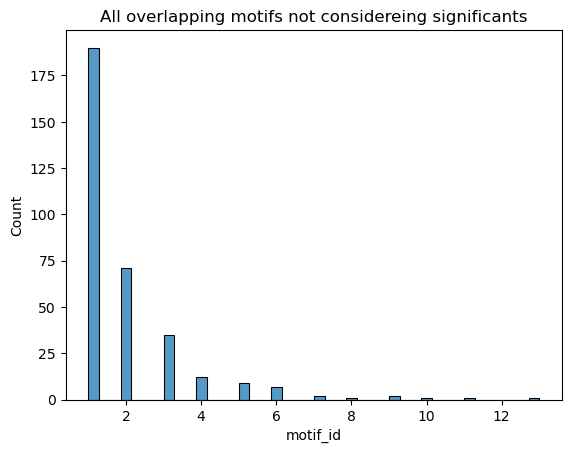

In [58]:
if combined_fimo_df_overlapping_variants.motif_id.isna().sum() != 0:
    raise ValueError("Expected no na's in motif id.")

import seaborn as sns

motifs_per_variant = combined_fimo_df_overlapping_variants.groupby(['ID'])['motif_id'].count().reset_index()
bin_range = (motifs_per_variant['motif_id'].min() - 0.5, motifs_per_variant['motif_id'].max() + 0.5)
# sns.histplot(data=motifs_per_variant, x="motif_id", binwidth=1, binrange=bin_range)
sns.histplot(data=motifs_per_variant, x="motif_id")
plt.title("All overlapping motifs not considereing significants")

<Axes: title={'center': 'All overlapping significant motifs (n: 59)'}, xlabel='motif_id', ylabel='Count'>

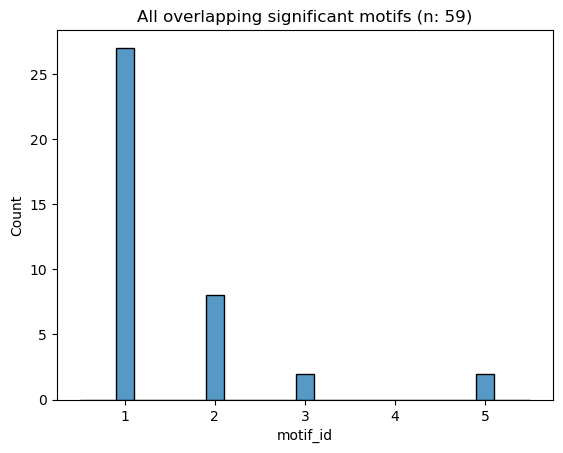

In [59]:
combined_fimo_df_overlapping_variants_significant
motifs_per_sig_variant = combined_fimo_df_overlapping_variants_significant.groupby(['ID'])['motif_id'].count().reset_index()
plt.title(f"All overlapping significant motifs (n: {combined_fimo_df_overlapping_variants_significant.shape[0]})")
bin_range = (motifs_per_sig_variant['motif_id'].min() -0.5, motifs_per_sig_variant['motif_id'].max() + 0.5)
sns.histplot(data=motifs_per_sig_variant, x="motif_id", binwidth=0.2, binrange=bin_range)
# motifs_per_sig_variant['motif_id'].hist()
# sns.histplot(data=motifs_per_sig_variant, x="motif_id")

In [60]:
motifs_per_sig_variant

,ID,motif_id
0,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,1
1,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,1
2,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,2
3,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,1
4,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,2
5,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,1
6,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,2
7,cardiac_neuro_cava_random:ALT_DMD|ENSG00000198...,1
8,cardiac_neuro_cava_random:ALT_DNM1|ENSG0000010...,1
9,cardiac_neuro_cava_random:ALT_DPYSL2|ENSG00000...,2


In [57]:
# # combined_fimo_results_variant_info_df = combined_fimo_df.merge(variant_bcalm_metadata_df[['ID', 'ref_sequence', 'alt_sequence', 'variant_pos']], on="ID", how="inner")
# combined_fimo_results_overlapping_variants = combined_fimo_results_variant_info_df.loc[combined_fimo_results_variant_info_df.apply(motif_overlaps_variant, axis=1)]
# print('Number of different variants with at least one motif:', combined_fimo_results_overlapping_variants['ID'].nunique()) # 385

In [61]:
print('Number of different variants with at least one motif:', combined_fimo_df_overlapping_variants['ID'].nunique()) # corrected 332
print('Number of different variants with at least one significant motif:', combined_fimo_df_overlapping_variants_significant['ID'].nunique()) # significant 39
# Number of different variants with at least one motif: 21365
# Number of different variants with at least one significant motif: 1015

Number of different variants with at least one motif: 332
Number of different variants with at least one significant motif: 39


In [62]:

print('number of variants with more than one motif: ', sum(combined_fimo_df_overlapping_variants.groupby('ID')['motif_id'].count() > 1)) # no sig filter for motifs: 142 # corrected sig variants: 12
print('number of variants with more than one significant motif: ', sum(combined_fimo_df_overlapping_variants_significant.groupby('ID')['motif_id'].count() > 1)) # no sig filter for motifs: 142 # corrected sig variants: 12
# number of variants with more than one motif:  12885
# number of variants with more than one significant motif:  316

number of variants with more than one motif:  142
number of variants with more than one significant motif:  12


In [77]:
combined_fimo_df_overlapping_variants_significant

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop
81,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN282.H12CORE.0.P.B,7,17,-,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,0.03700,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.20100,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,[224],3.752494e-04,0.687531,220,230
182,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,ZNF81.H12CORE.0.P.C,2,20,-,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,0.00159,cardiac_neuro_cava_random:REF_BRCA2|ENSG000001...,0.00624,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,[130],6.693321e-02,0.268344,121,139
241,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,SRBP2.H12CORE.1.P.B,7,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.01500,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,114,126
242,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,VEZF1.H12CORE.0.P.C,10,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.03050,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,117,127
302,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[65],1.184375e-02,-0.752610,63,73
313,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,64,74
318,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZSC22.H12CORE.0.P.C,4,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.04880,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,59,75
323,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[87],3.894777e-04,-0.720382,85,95
345,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN730.H12CORE.0.P.C,1,15,+,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.52900,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.02880,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,103,117
346,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN770.H12CORE.0.P.B,2,13,-,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.13100,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.00452,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,104,115


### Starting to parse a meme file (bio motifs is failing)
- meme parsing does not store the ID correctly

In [65]:
from Bio import motifs

# 1. Extracts the name because the biopython package fails
def extract_motif_names(meme_file):
    motif_names = []
    with open(meme_file, "r") as f:
        for line in f:
            if line.startswith("MOTIF"):
                motif_name = line.split(" ", 1)[1].strip()
                motif_names.append(motif_name)
    return motif_names


meme_file = "/home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme"
motif_names = extract_motif_names(meme_file)

# Add the name while loading the file using biopython
hocomoco_motif_dict = {}
with open('/home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme') as handle:
    # TODO: add the gene symbole to the meme motif
    motif_list = motifs.parse(handle, "pfm-four-columns")
    i = 0
    for motif in motif_list:
        motif.name = motif_names[i]
        hocomoco_motif_dict[motif.name] = motif
        i += 1



In [65]:
len(motif_names) # 523
len(hocomoco_motif_dict) # 523

523

In [ ]:
# # Example usage
test_motif = hocomoco_motif_dict["ZN282.H12CORE.0.P.B"]
test_motif.consensus
# test_motif.anticonsensus
test_motif.name

'ZN282.H12CORE.0.P.B'

##### Code for the scoring of the sequences: Calculating bit score for ref and alt 

In [244]:
# function for bit scoring
def score_sequence_with_pwm(sequence, motif):
    """Compute the PWM score of a sequence using Biopython motif.pwm."""

    pwm = motif.pwm

    # Ensure sequence matches motif length
    if len(sequence) != len(motif):
        raise ValueError("Sequence length must match motif length!")

    # Compute PWM score by summing log-odds values
    score = sum(pwm[nuc][i] for i, nuc in enumerate(sequence))

    return score

# # Example usage
# test_seq = "ACGTACGT"  # Must match motif length
# test_seq = "A"* 10  # Must match motif length
# print(f"PWM Score: {score_sequence_with_pwm(test_seq, hocomoco_motif_dict['AHR.H12CORE.0.P.B'])}")

def local_bitscore_tfbs(motif, sequence, motif_start, motif_end, variant_pos, strand):
    # sequence = "TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAAGATAGCACCTGTCATACAACTCAGAATGCAGACAAGTGAAAGGTCTTGGGGAGCTGACCTTAATTGCTTCTCTGGGTCAACAGGCCAGAACACCTAATAAGGACATGGAGGGGCTGACCTAGTAACAGCATCTGCATCAAAGAGAAACTACACTGTTCACAAGATTAACTTTCTGATACTAAGAAGGGAACAGTAACTTCCTTATTTAGAAGCTGGTGGGTTTT"
    # motif_start = 111
    # motif_end = 123 + 1 # end is excluded
    # variant_pos = 120
    # strand = "+"
    # motif = hocomoco_motif_dict["ZN574.H12CORE.0.P.B"]
    # todo: fix "-" strand issue that the subset of the pwm needs to be taken based on the strand
    verbose = False
    if strand == "-":
        verbose = True

    motif_end += 1 # end is excluded
    pwm = motif.pwm

    sequence_of_interest_start = max(motif_start, variant_pos - 5)

    sequence_of_interest_end = min(motif_end, variant_pos + 5)

    motif_related_start = max(0, sequence_of_interest_start - motif_start)
    motif_related_end = min(motif_end - motif_start, sequence_of_interest_end - motif_start)

    motif_sequence = sequence[motif_start:motif_end]
    # about the "-" strand case
    if strand == "-":
        # I think I need to get only one part of the sequence
        # motif_related_start = (motif_end - motif_start) - motif_related_start
        # motif_related_end = (motif_end - motif_start) - motif_related_end
        motif_sequence = reverse_complement(motif_sequence)
    motif_part = motif_sequence[motif_related_start:motif_related_end]
    # modify the pwm:
    modified_pwm = {nuc: scores[motif_related_start:motif_related_end] for nuc, scores in pwm.items()}
    if verbose:
        print("Motif related start: ", motif_related_start)
        print("Motif related end: ", motif_related_end)
        print("Motif length: ", motif_end - motif_start)
        print("PWM: ", pwm)
        from Bio.motifs import Motif
        from Bio.motifs.matrix import PositionWeightMatrix
        motif = Motif(alphabet="GATC")  # You can also use IUPAC.unambiguous_dna if needed
        motif.length = len(next(iter(modified_pwm.values())))  # length of the motif
        print(motif.length)
        # Create the PositionWeightMatrix
        modified_pwm_bio = PositionWeightMatrix(motif.alphabet, modified_pwm)
        print(modified_pwm_bio)


    return round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(motif_part)), 4)


# from Bio.Seq import Seq

# def score_local_window(motif, sequence, motif_start, motif_end, variant_pos, strand):
#     print(motif.name)
#     print(sequence)
#     print(motif_start)
#     print(motif_end)
#     print(variant_pos)
#     print(strand)
#     pwm = motif.pwm
#     print(pwm)
#     motif_len = motif_end - motif_start
#     variant_index_motif = variant_pos - motif_start  # Position of variant within motif sequence
#     variant_index_seq = variant_pos # Position of variant within motif sequence

#     window_radius = 5
#     window_start_motif = max(0, variant_index_motif - window_radius)
#     window_end_motif = min(motif_len, variant_index_motif + window_radius + 1)  # +1 because end is exclusive
#     window_start_seq = max(0, variant_index_seq - window_radius)
#     window_end_seq = min(len(sequence), variant_index_seq + window_radius + 1)  # +1 because end is exclusive
#     print(window_start_motif)
#     print(window_end_motif)
#     print(window_start_seq)
#     print(window_end_seq)
#     # Slice sequence and PWM accordingly
#     sub_sequence = sequence[window_start_seq:window_end_seq]
#     sub_pwm = {nuc: scores[window_start_motif:window_end_motif] for nuc, scores in pwm.items()}
#     print("seq: ", sub_sequence)
#     print(sub_pwm)
#     print(pwm.items())
#     # If on the negative strand, reverse complement both
#     if strand == '-':
#         sub_sequence = str(Seq(sub_sequence).reverse_complement())
#         sub_pwm = {nuc: list(reversed(scores)) for nuc, scores in sub_pwm.items()}

#     # Score
#     score = sum(sub_pwm[nuc][i] for i, nuc in enumerate(sub_sequence))
#     return score



def reverse_complement(seq):
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(complement)[::-1]


def score_variant_with_motif(row, motif_id_col="motif_id", ref_seq_col="ref_sequence", alt_seq_col="alt_sequence",
                             fimo_start="mod_fimo_start", fimo_stop="mod_fimo_stop", fimo_strand="strand",
                             new_ref_bitscore="ref_bitscore", new_alt_bitscore="alt_bitscore", check_from_this_variant_pos_col=None, verbose=False):
    """
    Score variants from the row:
    1. get the motif sequence from ref and from alt
    - if -strand the reverse complement is required
    2. Score it with the scoring function
    3. store the bit scores in a new column
    """

    # 1. Get the motif sequence from ref and from alt
    # get motif pwm
    motif_of_interst = hocomoco_motif_dict[row[motif_id_col]]

    # get sequences
    ref_motif_seq = row[ref_seq_col][int(row[fimo_start]):int(row[fimo_stop])+1]
    alt_motif_seq = row[alt_seq_col][int(row[fimo_start]):int(row[fimo_stop])+1]
    if row[fimo_strand] == "-":
        ref_motif_seq = reverse_complement(ref_motif_seq)
        alt_motif_seq = reverse_complement(alt_motif_seq)


    # 2. Score it with the scoring function
    ref_score = score_sequence_with_pwm(ref_motif_seq, motif_of_interst)
    alt_score = score_sequence_with_pwm(alt_motif_seq, motif_of_interst)

    # if only local score should be computed
    # todo compute the bitscore just based on 5bp around the motif for all tfbs
    if check_from_this_variant_pos_col:
        ref_score = local_bitscore_tfbs(motif=motif_of_interst, sequence=row[ref_seq_col], motif_start=row[fimo_start], motif_end=row[fimo_stop], variant_pos=row[check_from_this_variant_pos_col][0], strand=row[fimo_strand])
        alt_score = local_bitscore_tfbs(motif=motif_of_interst, sequence=row[alt_seq_col], motif_start=row[fimo_start], motif_end=row[fimo_stop], variant_pos=row[check_from_this_variant_pos_col][0], strand=row[fimo_strand])
        if row[fimo_strand] == "-":
            print(ref_score)
            print(alt_score)
            print(alt_score - ref_score)
    # 3. store the bit scores in a new column
    row[new_ref_bitscore] = ref_score
    row[new_alt_bitscore] = alt_score

    if verbose:
        print(row[motif_id_col])
        print(motif_of_interst.consensus)
        print(ref_motif_seq)
        print(alt_motif_seq)
        print(len(motif_of_interst.consensus))
        print(ref_motif_seq)
        print(ref_score)
        print(alt_score)

    return row




Focus on significant motif hits (is not required because the q-value cannot be trusted)

In [170]:
combined_fimo_df_overlapping_variants_significant_bitscore = combined_fimo_df_overlapping_variants_significant.apply(lambda row:
    score_variant_with_motif(row, motif_id_col="motif_id", ref_seq_col="ref_sequence", alt_seq_col="alt_sequence",
                             fimo_start="mod_fimo_start", fimo_stop="mod_fimo_stop", fimo_strand="strand",
                             new_ref_bitscore="ref_bitscore", new_alt_bitscore="alt_bitscore", verbose=False), axis=1).copy()

Do not focus on significant motif hits

In [70]:
combined_fimo_df_overlapping_variants_bitscore = combined_fimo_df_overlapping_variants.apply(lambda row:
    score_variant_with_motif(row, motif_id_col="motif_id", ref_seq_col="ref_sequence", alt_seq_col="alt_sequence",
                             fimo_start="mod_fimo_start", fimo_stop="mod_fimo_stop", fimo_strand="strand",
                             new_ref_bitscore="ref_bitscore", new_alt_bitscore="alt_bitscore", verbose=False), axis=1).copy()

NameError: name 'combined_fimo_df_overlapping_variants' is not defined

In [172]:
# for index, row in combined_fimo_df_overlapping_variants_significant.iterrows():
#     score_variant_with_motif(row, motif_id_col="motif_id", ref_seq_col="ref_sequence", alt_seq_col="alt_sequence",
#                              fimo_start="mod_fimo_start", fimo_stop="mod_fimo_stop", fimo_strand="strand",
#                              new_ref_bitscore="ref_bitscore", new_alt_bitscore="alt_bitscore", verbose=False)

In [ ]:
# combined_fimo_df_overlapping_variants_significant_bitscore

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [ ]:
combined_fimo_df_overlapping_variants_bitscore # 70,634 ( significant variants: 646 )

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore
14,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,2,14,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,[120],4.672365e-11,-0.828447,111,123,7.144000,6.713000
17,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,84,94,6.196306,7.189466
18,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,81,90,5.911178,6.828343
19,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,83,93,6.251356,7.251356
20,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],3.944972e-03,-0.774683,48,59,7.326673,7.205794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,235,246,7.272929,6.273054
2036,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,236,247,4.099619,3.923435
2037,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,233,245,7.737704,6.771045
2038,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,5,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,234,246,7.644538,6.809116


In [94]:
combined_fimo_df_overlapping_variants_significant

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop
81,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN282.H12CORE.0.P.B,7,17,-,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,0.03700,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.20100,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,[224],3.752494e-04,0.687531,220,230
182,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,ZNF81.H12CORE.0.P.C,2,20,-,cardiac_neuro_cava_random:ALT_BRCA2|ENSG000001...,0.00159,cardiac_neuro_cava_random:REF_BRCA2|ENSG000001...,0.00624,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,TACAGGTGGATGTATCTTTATAATACAATGATTTATCTTCCTTTGG...,[130],6.693321e-02,0.268344,121,139
241,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,SRBP2.H12CORE.1.P.B,7,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.01500,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,114,126
242,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,VEZF1.H12CORE.0.P.C,10,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.03050,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,AAAAGGGAACAAGATGACCAACTTGTTGGTGGGGAGAGTTGTGGCT...,[118],2.852661e-02,-0.342655,117,127
302,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[65],1.184375e-02,-0.752610,63,73
313,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,64,74
318,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZSC22.H12CORE.0.P.C,4,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.04880,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[66],4.793147e-04,-0.837000,59,75
323,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.03050,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,[87],3.894777e-04,-0.720382,85,95
345,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN730.H12CORE.0.P.C,1,15,+,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.52900,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.02880,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,103,117
346,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,ZN770.H12CORE.0.P.B,2,13,-,cardiac_neuro_cava_random:ALT_CNPY3|ENSG000001...,0.13100,cardiac_neuro_cava_random:REF_CNPY3|ENSG000001...,0.00452,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,GCCACGGCGCCTGGCCTTTTTCTTCTTCTTCTTCTTTGTTGAGACA...,[113],2.833166e-02,0.475888,104,115


### Group the TFBS based on: 
- case 1: reference has motif but alternative not: decreased binding affinity => regulatory active TFBS (if negative effect size => the TFBS is predicted to have a positive regulatory effect) => how many? => we expect a huge difference in the ref alt bitscore difference
    - do we find known negative regualtory TFBS and do all of them have a positive effect size
case 2: reference and alternative have the same motif => based on bit score which sequence is prefered. How many? 
    - If the reference bit score is higher than the predicted regulatory effect of this TFBS is the opposite of the variant effect
    - If the alternative bit score is higher the predicted regulatory effect of this TFBS is the same of the variant effect
- case 3: only alternative has a motif: motif is predicted to have an regulatory effect equal to the effect of the variant
- case 4: one variant has multiple hits of TFBS => bit score as measure for best hit (how many?)

#### First collect the respective group sizes: 

In [95]:
print(f"Overall Number of significant variants with a significant motif hit: {combined_fimo_df_overlapping_variants_significant_bitscore.shape[0]} ({round(combined_fimo_df_overlapping_variants_significant_bitscore.shape[0]/n_significant_variants*100,1)}%)")
print("Case 1: Number of significant motif to variant associations which are within ref but are not within alt:", combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0])
print("Case 2: Number of significant motif to variant associations which are within ref and alt:", combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0])
print("Case 3: Number of significant motif to variant associations which are not within ref but are within alt:", combined_fimo_df_overlapping_variants_significant_bitscore.loc[(combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0])
print('Case 4: Number of variants with more than one significant motif: ', sum(combined_fimo_df_overlapping_variants_significant_bitscore.groupby('ID')['motif_id'].count() > 1)) # no sig filter for motifs: 142 # corrected sig variants: 12

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [96]:
combined_fimo_df_overlapping_variants.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'mod_fimo_start',
       'mod_fimo_stop'],
      dtype='object')

In [97]:
combined_fimo_df_overlapping_variants

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop
14,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,2,14,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,[120],4.672365e-11,-0.828447,111,123
17,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,84,94
18,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,81,90
19,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,83,93
20,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],3.944972e-03,-0.774683,48,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,235,246
2036,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,236,247
2037,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,233,245
2038,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,5,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,234,246


In [100]:
print(f"Overall Number of significant variants with a motif hit: {combined_fimo_df_overlapping_variants['ID'].nunique()} ({round(combined_fimo_df_overlapping_variants['ID'].nunique()/n_significant_variants*100,1)}%)")
print("Case 1: Number of motif to variant associations which are within ref but are not within alt:", combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0])
print("Case 2: Number of motif to variant associations which are within ref and alt:", combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0])
print("Case 3: Number of motif to variant associations which are not within ref but are within alt:", combined_fimo_df_overlapping_variants.loc[(combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0])
print("Case 4: Number of variants with more than one motif: ", sum(combined_fimo_df_overlapping_variants.groupby('ID')['motif_id'].count() > 1)) # no sig filter for motifs: 142 # corrected sig variants: 12


Overall Number of significant variants with a motif hit: 332 (37.1%)
Case 1: Number of motif to variant associations which are within ref but are not within alt: 325
Case 2: Number of motif to variant associations which are within ref and alt: 96
Case 3: Number of motif to variant associations which are not within ref but are within alt: 225
Case 4: Number of variants with more than one motif:  142


In [101]:
combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id"]).shape[0]

608

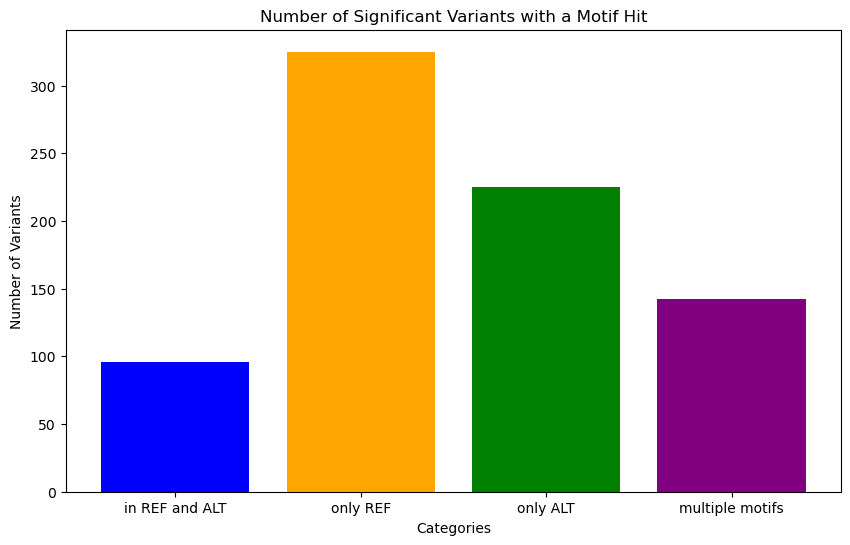

In [102]:
import matplotlib.pyplot as plt
data = {
    "in REF and ALT": combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0],
    "only REF": combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0],
    "only ALT": combined_fimo_df_overlapping_variants.loc[(combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0],
    "multiple motifs": sum(combined_fimo_df_overlapping_variants.groupby('ID')['motif_id'].count() > 1),
}
# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(data.keys(), data.values(), color=['blue', 'orange', 'green', 'purple'])
plt.xlabel('Categories')
plt.ylabel('Number of Variants')
plt.title('Number of Significant Variants with a Motif Hit')
plt.show()

### How many TFBS associated variants do we have?

In [103]:
data = {
    "Category": ["unique variant with predicted TFBS", "unique variant with predicted TFBS"],
    "Group": ["With significant motifs", "Using all variant overlapping motif hits"],
    "Count": [combined_fimo_df_overlapping_variants_significant_bitscore['ID'].nunique()/n_significant_variants, combined_fimo_df_overlapping_variants['ID'].nunique()/n_significant_variants]
}

group2 = {
    "unique variant with predicted TFBS": combined_fimo_df_overlapping_variants['ID'].nunique()/n_significant_variants,
}

# Create a DataFrame
df = pd.DataFrame(data)

# Plotting the histogram
plt.figure(figsize=(10, 6))
sns.barplot(x="Category", y="Count", hue="Group", data=df, palette=["#BF2675", "#72ACBF"])
plt.ylabel('Proportion of significant Variants')
plt.title('Proportion of Significant Variants with a varaint overlapping Motif')
plt.show()


NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [104]:
combined_fimo_df_overlapping_variants_significant_bitscore

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [105]:
combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]
combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [106]:
all_sign_motif_hists

NameError: name 'all_sign_motif_hists' is not defined

In [107]:
import matplotlib.pyplot as plt

n_significant_variants = 896
# # Data for the histogram
# significant_motifs = {
#     "unique variant with predicted TFBS": combined_fimo_df_overlapping_variants_significant_bitscore['ID'].nunique()/n_significant_variants,
#     "only REF": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
#     "in REF and ALT": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
#     "only ALT": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
#     "multiple motifs": sum(combined_fimo_df_overlapping_variants_significant_bitscore.groupby('ID')['motif_id'].count() > 1)/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
# }
all_motifs = {
    "unique variant with predicted TFBS": all_sign_motif_hists['ID'].nunique()/n_significant_variants,
    "in REF and ALT": all_sign_motif_hists.loc[(~all_sign_motif_hists['REF_q-value'].isna()) & (~all_sign_motif_hists['ALT_q-value'].isna())].shape[0]/all_sign_motif_hists.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "only REF": all_sign_motif_hists.loc[(~all_sign_motif_hists['REF_q-value'].isna()) & (all_sign_motif_hists['ALT_q-value'].isna())].shape[0]/all_sign_motif_hists.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "only ALT": all_sign_motif_hists.loc[(all_sign_motif_hists['REF_q-value'].isna()) & (~all_sign_motif_hists['ALT_q-value'].isna())].shape[0]/all_sign_motif_hists.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "multiple motifs": sum(all_sign_motif_hists.groupby('ID')['motif_id'].count() > 1)/all_sign_motif_hists.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
}

# Categories
categories = list(all_motifs.keys())

# Values for each group
# values_significant_motifs = list(significant_motifs.values())
values_all_motifs = list(all_motifs.values())

# X-axis positions for the groups
x = np.arange(len(categories))

# Width of the bars
width = 0.35

# Plotting the histogram
fig, ax = plt.subplots(figsize=(10, 6))
# bars1 = ax.bar(x - width/2, values_significant_motifs, width, label='With significant motifs', color='#BF2675')
bars2 = ax.bar(x, values_all_motifs, width, color='#72ACBF')

# Adding labels and title
ax.set_xlabel('Categories')
plt.ylabel('Proportion of significant Variants')
# n_variant_motif_associations_significant = combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]
n_variant_motif_associations = all_sign_motif_hists.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]
plt.title(f'Proportion of Significant Variants (sig vars: {n_significant_variants}; all motifs: {n_variant_motif_associations}): with different categories of overlapping motifs')
ax.set_xticks(x)
ax.set_xticklabels(categories)
plt.xticks(rotation=30)
ax.legend()

NameError: name 'all_sign_motif_hists' is not defined

In [108]:
all_sign_motif_hists['ID'].nunique()/n_significant_variants

NameError: name 'all_sign_motif_hists' is not defined

In [109]:
all_sign_motif_hists['ID'].nunique()

NameError: name 'all_sign_motif_hists' is not defined

In [110]:
all_sign_motif_hists

NameError: name 'all_sign_motif_hists' is not defined

In [111]:
import matplotlib.pyplot as plt

# Data for the histogram
significant_motifs = {
    "unique variant with predicted TFBS": combined_fimo_df_overlapping_variants_significant_bitscore['ID'].nunique()/n_significant_variants,
    "only REF": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "in REF and ALT": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "only ALT": combined_fimo_df_overlapping_variants_significant_bitscore.loc[(combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "multiple motifs": sum(combined_fimo_df_overlapping_variants_significant_bitscore.groupby('ID')['motif_id'].count() > 1)/combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
}

all_motifs = {
    "unique variant with predicted TFBS": combined_fimo_df_overlapping_variants['ID'].nunique()/n_significant_variants,
    "in REF and ALT": combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "only REF": combined_fimo_df_overlapping_variants.loc[(~combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "only ALT": combined_fimo_df_overlapping_variants.loc[(combined_fimo_df_overlapping_variants['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants['ALT_q-value'].isna())].shape[0]/combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
    "multiple motifs": sum(combined_fimo_df_overlapping_variants.groupby('ID')['motif_id'].count() > 1)/combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0],
}

# Categories
categories = list(significant_motifs.keys())

# Values for each group
values_significant_motifs = list(significant_motifs.values())
values_all_motifs = list(all_motifs.values())

# X-axis positions for the groups
x = np.arange(len(categories))

# Width of the bars
width = 0.35

# Plotting the histogram
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, values_significant_motifs, width, label='With significant motifs', color='#BF2675')
bars2 = ax.bar(x + width/2, values_all_motifs, width, label='Using all variant overlapping motifs', color='#72ACBF')

# Adding labels and title
ax.set_xlabel('Categories')
plt.ylabel('Proportion of significant Variants')
n_variant_motif_associations_significant = combined_fimo_df_overlapping_variants_significant_bitscore.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]
n_variant_motif_associations = combined_fimo_df_overlapping_variants.drop_duplicates(subset=["ID", "motif_id", "mod_fimo_start", "mod_fimo_stop"]).shape[0]
plt.title(f'Proportion of Significant Variants (sig vars: {n_significant_variants}; sig motifs: {n_variant_motif_associations_significant}; all motifs: {n_variant_motif_associations}): with different categories of overlapping motifs')
ax.set_xticks(x)
ax.set_xticklabels(categories)
plt.xticks(rotation=30)
ax.legend()

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [112]:
combined_fimo_df_overlapping_variants_significant_bitscore.columns

NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

#### Split dataframe into groups:
- significant
- all motifs

In [113]:
significant_motif_variant_association_only_REF = combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].copy()
significant_motif_variant_association_REF_and_ALT = combined_fimo_df_overlapping_variants_significant_bitscore.loc[(~combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].copy()
significant_motif_variant_association_only_ALT = combined_fimo_df_overlapping_variants_significant_bitscore.loc[(combined_fimo_df_overlapping_variants_significant_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_significant_bitscore['ALT_q-value'].isna())].copy()

# what is the median bitscore difference in the groups
print('Investigate Bit score differences for only REF: ')
print("Median:", (significant_motif_variant_association_only_REF['alt_bitscore'] - significant_motif_variant_association_only_REF['ref_bitscore']).median()) # -0.94
print("Max:", (significant_motif_variant_association_only_REF['alt_bitscore'] - significant_motif_variant_association_only_REF['ref_bitscore']).max()) # -0.94
print("min:", (significant_motif_variant_association_only_REF['alt_bitscore'] - significant_motif_variant_association_only_REF['ref_bitscore']).min()) # -0.94

significant_motif_variant_association_only_REF['bitscore_difference'] = significant_motif_variant_association_only_REF['alt_bitscore'] - significant_motif_variant_association_only_REF['ref_bitscore']
print()

print('Investigate Bit score differences for only ALT: ')
print("Median:", (significant_motif_variant_association_only_ALT['alt_bitscore'] - significant_motif_variant_association_only_ALT['ref_bitscore']).median())
print("Max:", (significant_motif_variant_association_only_ALT['alt_bitscore'] - significant_motif_variant_association_only_ALT['ref_bitscore']).max())
print("min:", (significant_motif_variant_association_only_ALT['alt_bitscore'] - significant_motif_variant_association_only_ALT['ref_bitscore']).min())

significant_motif_variant_association_only_ALT['bitscore_difference'] = significant_motif_variant_association_only_ALT['alt_bitscore'] - significant_motif_variant_association_only_ALT['ref_bitscore']
print()

print('Investigate Bit score differences for motifs found in REF and ALT: ')
print("Median:", (significant_motif_variant_association_REF_and_ALT['alt_bitscore'] - significant_motif_variant_association_REF_and_ALT['ref_bitscore']).median())
print("Max:", (significant_motif_variant_association_REF_and_ALT['alt_bitscore'] - significant_motif_variant_association_REF_and_ALT['ref_bitscore']).max())
print("min:", (significant_motif_variant_association_REF_and_ALT['alt_bitscore'] - significant_motif_variant_association_REF_and_ALT['ref_bitscore']).min())

significant_motif_variant_association_REF_and_ALT['bitscore_difference'] = significant_motif_variant_association_REF_and_ALT['alt_bitscore'] - significant_motif_variant_association_REF_and_ALT['ref_bitscore']


NameError: name 'combined_fimo_df_overlapping_variants_significant_bitscore' is not defined

In [114]:
significant_motif_variant_association_only_REF['bitscore_difference'].hist()
plt.title("Difference of bit score for the significant motifs only found in reference sequences of significant variants")
plt.show()
significant_motif_variant_association_only_ALT['bitscore_difference'].hist()
plt.title("Difference in bit score for the significant motifs only found in alternative sequences of significant variants")
plt.show()
significant_motif_variant_association_REF_and_ALT['bitscore_difference'].hist()
plt.title("bit score difference of motifs significant in at least one ref or alt and found in Ref and Alt of significant variants")
plt.show()

NameError: name 'significant_motif_variant_association_only_REF' is not defined

all motifs

In [115]:
all_motif_variant_association_only_REF = combined_fimo_df_overlapping_variants_bitscore.loc[(~combined_fimo_df_overlapping_variants_bitscore['REF_q-value'].isna()) & (combined_fimo_df_overlapping_variants_bitscore['ALT_q-value'].isna())].copy()
all_motif_variant_association_REF_and_ALT = combined_fimo_df_overlapping_variants_bitscore.loc[(~combined_fimo_df_overlapping_variants_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_bitscore['ALT_q-value'].isna())].copy()
all_motif_variant_association_only_ALT = combined_fimo_df_overlapping_variants_bitscore.loc[(combined_fimo_df_overlapping_variants_bitscore['REF_q-value'].isna()) & (~combined_fimo_df_overlapping_variants_bitscore['ALT_q-value'].isna())].copy()

# what is the median bitscore difference in the groups
print('Investigate Bit score differences for only REF: ')
print("Median:", (all_motif_variant_association_only_REF['alt_bitscore'] - all_motif_variant_association_only_REF['ref_bitscore']).median()) # -0.94
print("Max:", (all_motif_variant_association_only_REF['alt_bitscore'] - all_motif_variant_association_only_REF['ref_bitscore']).max()) # -0.94
print("min:", (all_motif_variant_association_only_REF['alt_bitscore'] - all_motif_variant_association_only_REF['ref_bitscore']).min()) # -0.94

all_motif_variant_association_only_REF['bitscore_difference'] = all_motif_variant_association_only_REF['alt_bitscore'] - all_motif_variant_association_only_REF['ref_bitscore']
print()

print('Investigate Bit score differences for only ALT: ')
print("Median:", (all_motif_variant_association_only_ALT['alt_bitscore'] - all_motif_variant_association_only_ALT['ref_bitscore']).median())
print("Max:", (all_motif_variant_association_only_ALT['alt_bitscore'] - all_motif_variant_association_only_ALT['ref_bitscore']).max())
print("min:", (all_motif_variant_association_only_ALT['alt_bitscore'] - all_motif_variant_association_only_ALT['ref_bitscore']).min())

all_motif_variant_association_only_ALT['bitscore_difference'] = all_motif_variant_association_only_ALT['alt_bitscore'] - all_motif_variant_association_only_ALT['ref_bitscore']
print()

print('Investigate Bit score differences for motifs found in REF and ALT: ')
print("Median:", (all_motif_variant_association_REF_and_ALT['alt_bitscore'] - all_motif_variant_association_REF_and_ALT['ref_bitscore']).median())
print("Max:", (all_motif_variant_association_REF_and_ALT['alt_bitscore'] - all_motif_variant_association_REF_and_ALT['ref_bitscore']).max())
print("min:", (all_motif_variant_association_REF_and_ALT['alt_bitscore'] - all_motif_variant_association_REF_and_ALT['ref_bitscore']).min())

all_motif_variant_association_REF_and_ALT['bitscore_difference'] = all_motif_variant_association_REF_and_ALT['alt_bitscore'] - all_motif_variant_association_REF_and_ALT['ref_bitscore']


Investigate Bit score differences for only REF: 
Median: -0.6900000000000004
Max: 0.9977950904012935
min: -1.0

Investigate Bit score differences for only ALT: 
Median: 0.8842784693407095
Max: 1.0000000000000009
min: 0.0030456852791882483

Investigate Bit score differences for motifs found in REF and ALT: 
Median: 0.044798418267229856
Max: 0.9819999999999975
min: -0.9799999999999986


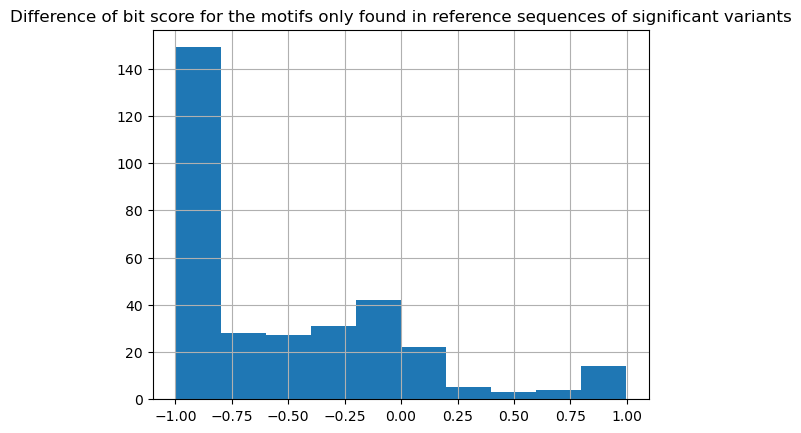

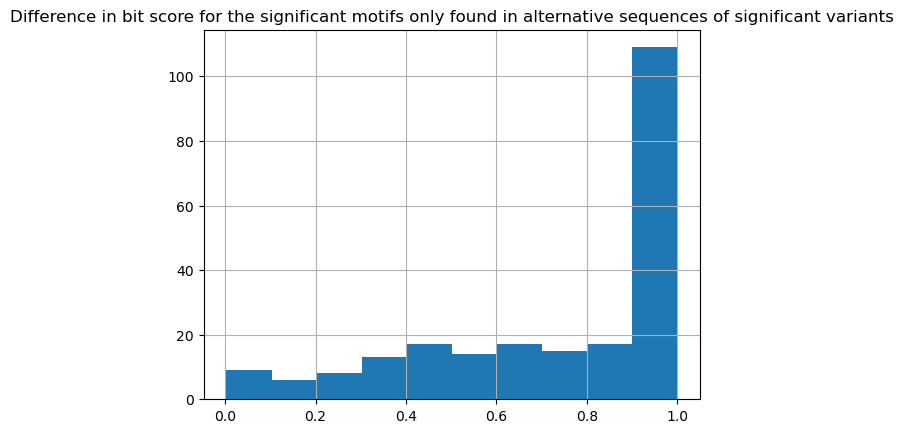

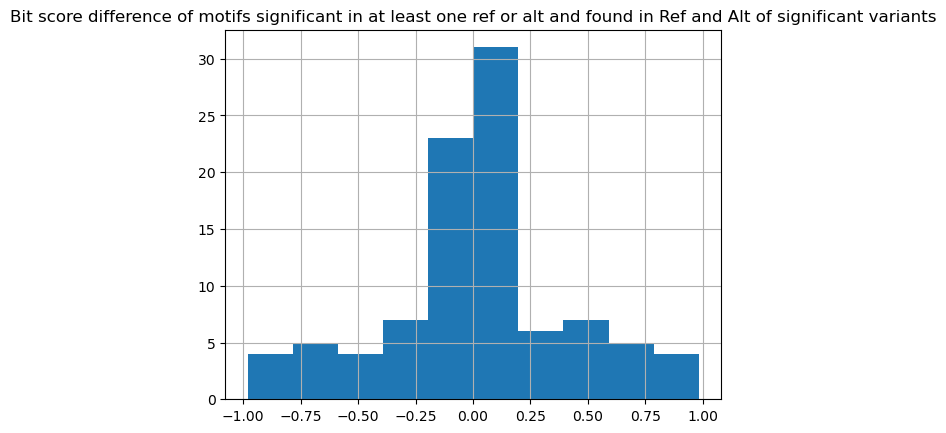

In [116]:
all_motif_variant_association_only_REF['bitscore_difference'].hist()
plt.title("Difference of bit score for the motifs only found in reference sequences of significant variants")
plt.show()
all_motif_variant_association_only_ALT['bitscore_difference'].hist()
plt.title("Difference in bit score for the significant motifs only found in alternative sequences of significant variants")
plt.show()
all_motif_variant_association_REF_and_ALT['bitscore_difference'].hist()
plt.title("Bit score difference of motifs significant in at least one ref or alt and found in Ref and Alt of significant variants")
plt.show()

#### TFBS effect interpretation: 
- if ref binds better and negative effect logfc => motif is predicted to be activating in this cell type (increasing but otherwise true)
- if ref binds better and positive effect logfc => motif is predicted to be repressing in this cell type (reducing but otherwise True)
- if alt binds better and negative effect logfc => motif is predicted to be repressing in this cell type (reducing but otherwise True)
- if alt binds better and positive effect logfc => motif is predicted to be activating in this cell type (reducing but otherwise True)

In [ ]:
def interprete_TFBS_findings(row, variant_effect_col="bcalm_variant_effect_log_ratio_activity", bit_score_difference_col="alt_ref_bitscore_diff", new_interpretation_col="TFBS_interpretation"):
    """Iterate over each motif variant association and interprete the effect of the identified TFBS as follows:
        Activating TFBS:
            - if REF binds better and negative effect logfc => motif is predicted to be activating in this cell type
            - if ALT binds better and positive effect logfc => motif is predicted to be activating in this cell type
        Repressing TFBS:
            - if ALT binds better and negative effect logfc => motif is predicted to be repressing in this cell type
            - if REF binds better and positive effect logfc => motif is predicted to be repressing in this cell type
    """
    bit_score_diff = row[bit_score_difference_col] # since alt - ref if alt > ref => alt binds better than ref => it is positive if ref binds better it is negative
    variant_effect = row[variant_effect_col] # assume alt - ref
    interpretation=""
    # TODO: fix: error in ZN213.H12CORE.0.P.C: alt better fitting and negative effect but predicted to be activating
    if bit_score_diff > 0: # alt binds better
        if variant_effect > 0: # variant is activating
            interpretation = "motif is predicted to be activating in neural progenitors derived from WTC11"
        elif variant_effect < 0: # variant is repressing
            interpretation = "motif is predicted to be repressing in neural progenitors derived from WTC11"
        else:
            raise ValueError("Did not expect a variant with 0 variant effect better binding to alternative: please sanity check")
    elif bit_score_diff < 0: # ref binds better
        if variant_effect > 0: # variant is activating
            interpretation = "motif is predicted to be repressing in neural progenitors derived from WTC11"
        elif variant_effect < 0: # variant is repressing
            interpretation = "motif is predicted to be activating in neural progenitors derived from WTC11"
        else:
            raise ValueError("Did not expect a variant with 0 variant effect: please sanity check")
    else:
        interpretation="Ref and Alt have same bit score => unimportant base hit => motif does not seem to be causal"
        print(f"{row['motif_id']} REF and ALT have same bit score => motif is not causal")
    row[new_interpretation_col] = interpretation
    return row

In [126]:
combined_fimo_df_overlapping_variants_bitscore["alt_ref_bitscore_diff"] = combined_fimo_df_overlapping_variants_bitscore["alt_bitscore"] - combined_fimo_df_overlapping_variants_bitscore['ref_bitscore']


In [119]:
combined_fimo_df_overlapping_variants_bitscore.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'mod_fimo_start',
       'mod_fimo_stop', 'ref_bitscore', 'alt_bitscore',
       'alt_ref_bitscore_diff'],
      dtype='object')

In [127]:
combined_fimo_df_overlapping_variants_bitscore_interpretation = combined_fimo_df_overlapping_variants_bitscore.apply(lambda row: interprete_TFBS_findings(row, variant_effect_col="bcalm_variant_effect_log_ratio_activity", bit_score_difference_col="alt_ref_bitscore_diff", new_interpretation_col="TFBS_interpretation") , axis=1).copy()

ZN614.H12CORE.0.P.C REF and ALT have same bit score => motif is not causal
PAX7.H12CORE.2.PM.A REF and ALT have same bit score => motif is not causal
ZSCA1.H12CORE.0.SM.B REF and ALT have same bit score => motif is not causal
SPI1.H12CORE.0.P.B REF and ALT have same bit score => motif is not causal
BARH2.H12CORE.0.SM.B REF and ALT have same bit score => motif is not causal
NFYC.H12CORE.0.P.B REF and ALT have same bit score => motif is not causal
HIC1.H12CORE.0.PSM.A REF and ALT have same bit score => motif is not causal
CUX2.H12CORE.2.S.C REF and ALT have same bit score => motif is not causal
ZN384.H12CORE.0.PSM.A REF and ALT have same bit score => motif is not causal
NR2C1.H12CORE.0.S.C REF and ALT have same bit score => motif is not causal


In [128]:
combined_fimo_df_overlapping_variants_bitscore_interpretation["TFBS_interpretation"].value_counts()

TFBS_interpretation
motif is predicted to be activating in neural progenitors derived from WTC11                   340
motif is predicted to be repressing in neural progenitors derived from WTC11                   296
Ref and Alt have same bit score => unimportant base hit => motif does not seem to be causal     10
Name: count, dtype: int64

In [ ]:
if write_output:
    output_interpration_all_motifs_of_significant_variants = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant.tsv"

    combined_fimo_df_overlapping_variants_bitscore_interpretation.to_csv(output_interpration_all_motifs_of_significant_variants, sep="\t", header=True, index=False)

#### After interpretation: Questions about the TFBS overlapping significant variants: 
- read the file from disc (because the computation above might be done as well for the all variant set)
- TODO: How many common variants are within this set? 
- TODO: Do I see the same TFBS with different interpretations? => do I see for this variant other TFBS? (=> if only one TFBS very interesting to explain) 

#### add tfbs name to the motif hits

In [164]:
# combined_fimo_df_overlapping_variants_significant
import pandas as pd
hocomoco_annotation_info_path = "/home/kisa/coding/80K_MPRA/fimo_data/H12CORE_annotation.jsonl"
hocomoco_annotation_info_all = pd.read_json(path_or_buf=hocomoco_annotation_info_path, lines=True)
# rename name
hocomoco_annotation_info = hocomoco_annotation_info_all.rename(columns={"name": "motif_id"}).copy()


# get gene symbol
def from_masterlist_info_2_gene_symbol(masterlist_info):
    """Expects to get a dict as input and tried to read the human gene_symbol"""

    try:
        gene_symbol = masterlist_info['species']['HUMAN']['gene_symbol']
        uniprot_id =  masterlist_info['species']['HUMAN']['uniprot_id']
        uniprot_accession_num =  masterlist_info['species']['HUMAN']['uniprot_ac']
    except:
        print("Problem during finding gene symbol of the following masterlist info: ", masterlist_info)
        gene_symbol = pd.NA
    return pd.Series({'gene_symbol': gene_symbol, 'uniprot_id': uniprot_id, 'uniprot_accession_num': uniprot_accession_num})


hocomoco_annotation_info[['gene_symbol', 'uniprot_id', 'uniprot_accession_num']] = hocomoco_annotation_info["masterlist_info"].apply(from_masterlist_info_2_gene_symbol)
hocomoco_annotation_info
# only name and tf name
hocomoco_annotation_info = hocomoco_annotation_info[['motif_id', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num']].copy()
combined_fimo_df_overlapping_variants_bitscore_tf_info = combined_fimo_df_overlapping_variants_bitscore_interpretation.merge(hocomoco_annotation_info, on="motif_id", how="inner").copy()



In [170]:
combined_fimo_df_overlapping_variants_bitscore_tf_info
combined_fimo_df_overlapping_variants_bitscore_tf_info.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'mod_fimo_start',
       'mod_fimo_stop', 'ref_bitscore', 'alt_bitscore',
       'alt_ref_bitscore_diff', 'TFBS_interpretation', 'gene_symbol',
       'uniprot_id', 'uniprot_accession_num'],
      dtype='object')

In [ ]:
important_columns = ['ID', 'motif_id', 'mod_fimo_start',
       'mod_fimo_stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore', 'alt_bitscore',
       'alt_ref_bitscore_diff', 'TFBS_interpretation', 'gene_symbol',
       'uniprot_id', 'uniprot_accession_num']
if write_output:
    output_interpration_all_motifs_of_significant_variants = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_gene_info.tsv"

    combined_fimo_df_overlapping_variants_bitscore_tf_info[important_columns].to_csv(output_interpration_all_motifs_of_significant_variants, sep="\t", header=True, index=False)

In [166]:
combined_fimo_df_overlapping_variants_bitscore_tf_info.loc[combined_fimo_df_overlapping_variants_bitscore_tf_info['motif_id'] =="ZN213.H12CORE.0.P.C"]

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num
77,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN213.H12CORE.0.P.C,1,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.075,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0961,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,-0.752610,55,71,8.260766,8.327751,0.066986,motif is predicted to be repressing in neural ...,ZNF213,ZN213_HUMAN,O14771
366,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,ZN213.H12CORE.0.P.C,3,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,0.1270,CTATAGATCTCTTTCTAACTTCTCATATCATTTCTGGGCCAGCCCA...,...,-0.337785,232,248,8.712919,7.818182,-0.894737,motif is predicted to be activating in neural ...,ZNF213,ZN213_HUMAN,O14771
378,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,ZN213.H12CORE.0.P.C,5,21,-,NaN,NaN,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,0.1270,CACTTTGAGACTGAGCTTGTAACTCCTTGCTCATTTGACTGTACCA...,...,-0.341353,206,222,8.267943,8.251196,-0.016746,motif is predicted to be activating in neural ...,ZNF213,ZN213_HUMAN,O14771
533,cardiac_neuro_cava_random:ALT_SMAD2|ENSG000001...,ZN213.H12CORE.0.P.C,3,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_SMAD2|ENSG000001...,0.1270,GTGTACCAATTCCTGTCACATCCAGGATCCTGAAAACTCTATATTC...,...,-0.560037,105,121,4.200957,3.306220,-0.894737,motif is predicted to be activating in neural ...,ZNF213,ZN213_HUMAN,O14771
538,cardiac_neuro_cava_random:ALT_SMAD2|ENSG000001...,ZN213.H12CORE.0.P.C,3,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_SMAD2|ENSG000001...,0.1270,GTGTACCAATTCCTGTCACATCCAGGATCCTGAAAACTCTATATTC...,...,-0.358556,45,61,8.258373,7.363636,-0.894737,motif is predicted to be activating in neural ...,ZNF213,ZN213_HUMAN,O14771


In [ ]:
combined_fimo_df_overlapping_variants_bitscore_tf_info

In [122]:
combined_fimo_df_overlapping_variants_bitscore_interpretation

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation
14,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,2,14,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,[120],4.672365e-11,-0.828447,111,123,7.144000,6.713000,-0.431000,motif is predicted to be repressing in neural ...
17,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,84,94,6.196306,7.189466,0.993160,motif is predicted to be repressing in neural ...
18,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,81,90,5.911178,6.828343,0.917166,motif is predicted to be repressing in neural ...
19,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],9.773094e-02,0.273304,83,93,6.251356,7.251356,1.000000,motif is predicted to be repressing in neural ...
20,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],3.944972e-03,-0.774683,48,59,7.326673,7.205794,-0.120879,motif is predicted to be repressing in neural ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,235,246,7.272929,6.273054,-0.999875,motif is predicted to be activating in neural ...
2036,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,236,247,4.099619,3.923435,-0.176184,motif is predicted to be activating in neural ...
2037,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,233,245,7.737704,6.771045,-0.966659,motif is predicted to be activating in neural ...
2038,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,5,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],1.395579e-06,0.556370,234,246,7.644538,6.809116,-0.835422,motif is predicted to be activating in neural ...


#### TFBS with different interpretations intersting variants: 
- e.g. TFBS with different interpretation


In [72]:
import pandas as pd
output_interpration_all_motifs_of_significant_variants = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_gene_info.tsv"
combined_fimo_df_overlapping_variants_bitscore_tf_info = pd.read_csv(output_interpration_all_motifs_of_significant_variants, sep="\t", low_memory=False)

In [ ]:
import ast
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# Apply the safe_eval function to the specified columns
for col in ['variant_pos']:
    combined_fimo_df_overlapping_variants_bitscore_tf_info[col] = combined_fimo_df_overlapping_variants_bitscore_tf_info[col].apply(safe_eval)


'/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_gene_info.tsv'

In [76]:
combined_fimo_df_overlapping_variants_bitscore_tf_info.columns

Index(['ID', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand',
       'ALT_name', 'ALT_q-value', 'REF_name', 'REF_q-value', 'ref_sequence',
       'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore',
       'alt_bitscore', 'alt_ref_bitscore_diff', 'TFBS_interpretation',
       'gene_symbol', 'uniprot_id', 'uniprot_accession_num'],
      dtype='object')

In [77]:
combined_fimo_df_overlapping_variants_bitscore_tf_info

,ID,motif_id,mod_fimo_start,mod_fimo_stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num
0,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,111,123,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,...,[120],4.672365e-11,-0.828447,7.144000,6.713000,-0.431000,motif is predicted to be activating in neural ...,ZNF574,ZN574_HUMAN,Q6ZN55
1,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,84,94,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],9.773094e-02,0.273304,6.196306,7.189466,0.993160,motif is predicted to be activating in neural ...,RFX1,RFX1_HUMAN,P22670
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,81,90,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],9.773094e-02,0.273304,5.911178,6.828343,0.917166,motif is predicted to be activating in neural ...,RUNX1,RUNX1_HUMAN,Q01196
3,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,83,93,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],9.773094e-02,0.273304,6.251356,7.251356,1.000000,motif is predicted to be activating in neural ...,ZNF766,ZN766_HUMAN,Q5HY98
4,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,48,59,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,...,[58],3.944972e-03,-0.774683,7.326673,7.205794,-0.120879,motif is predicted to be activating in neural ...,FOSL2,FOSL2_HUMAN,P15408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,235,246,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],1.395579e-06,0.556370,7.272929,6.273054,-0.999875,motif is predicted to be repressing in neural ...,ZBTB7B,ZBT7B_HUMAN,O15156
642,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,236,247,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],1.395579e-06,0.556370,4.099619,3.923435,-0.176184,motif is predicted to be repressing in neural ...,ZBTB7B,ZBT7B_HUMAN,O15156
643,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,233,245,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],1.395579e-06,0.556370,7.737704,6.771045,-0.966659,motif is predicted to be repressing in neural ...,ZNF460,ZN460_HUMAN,Q14592
644,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,234,246,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],1.395579e-06,0.556370,7.644538,6.809116,-0.835422,motif is predicted to be repressing in neural ...,ZNF460,ZN460_HUMAN,Q14592


In [193]:
def local_bitscore_tfbs(motif, sequence, motif_start, motif_end, variant_pos, strand):
    # sequence = "TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAAGATAGCACCTGTCATACAACTCAGAATGCAGACAAGTGAAAGGTCTTGGGGAGCTGACCTTAATTGCTTCTCTGGGTCAACAGGCCAGAACACCTAATAAGGACATGGAGGGGCTGACCTAGTAACAGCATCTGCATCAAAGAGAAACTACACTGTTCACAAGATTAACTTTCTGATACTAAGAAGGGAACAGTAACTTCCTTATTTAGAAGCTGGTGGGTTTT"
    # motif_start = 111
    # motif_end = 123 + 1 # end is excluded
    # variant_pos = 120
    # strand = "+"
    # motif = hocomoco_motif_dict["ZN574.H12CORE.0.P.B"]
    pwm = motif.pwm

    sequence_of_interest_start = max(motif_start, variant_pos - 5)
    # print(sequence_of_interest_start)
    sequence_of_interest_end = min(motif_end, variant_pos + 5)
    # print(sequence_of_interest_end)
    example_sequence = sequence[sequence_of_interest_start:sequence_of_interest_end]

    motif_related_start = max(0, sequence_of_interest_start - motif_start)
    motif_related_end = min(motif_end - motif_start, sequence_of_interest_end - motif_start)

    motif_sequence = sequence[motif_start:motif_end]
    # about the "-" strand case
    if strand == "-":
        motif_sequence = reverse_complement(motif_sequence)
    motif_part = motif_sequence[motif_related_start:motif_related_end]
    # modify the pwm:
    modified_pwm = {nuc: scores[motif_related_start:motif_related_end] for nuc, scores in pwm.items()}

    return round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(motif_part)), 4)

83
94
variant pos in motif 5
motif_related_region (start):  0
motif_related_region (end):  11
11
TGTGGATGCTT
AAGCATCCACA
AAGCATCCACA
11
        0      1      2      3      4      5      6      7      8      9     10
G:   0.22   0.08   0.65   0.00   0.00   0.00   0.00   0.00   0.02   0.10   0.10
A:   0.72   0.89   0.01   0.93   1.00   1.00   0.01   0.01   0.15   0.12   0.26
T:   0.02   0.02   0.34   0.00   0.00   0.00   0.01   0.01   0.53   0.24   0.40
C:   0.04   0.01   0.00   0.07   0.00   0.00   0.99   0.98   0.30   0.55   0.23

{'G': (0.22061482820976494, 0.0795660036166365, 0.6491862567811935, 0.0018083182640145, 0.0018083182640145, 0.0, 0.0, 0.0, 0.0198915009041591, 0.0976491862567812, 0.1030741410488246), 'A': (0.7160940325497288, 0.8896925858951176, 0.0072332730560579, 0.9330922242314648, 0.9981916817359855, 1.0, 0.0072332730560579, 0.0090415913200723, 0.1518987341772152, 0.1175406871609403, 0.2640144665461121), 'T': (0.021699819168173602, 0.0198915009041591, 0.3399638336347197,

6.2514

115
124
4
13
13
GCTTCTCTGGGTC
CTCTGGGTC
9
        0      1      2      3      4      5      6      7      8      9     10     11     12
G:   0.61   0.21   0.04   0.35   0.01   0.01   0.02   0.01   0.28   0.68   0.54   0.13   0.22
A:   0.07   0.15   0.13   0.14   0.01   0.01   0.01   0.01   0.56   0.02   0.02   0.30   0.17
T:   0.26   0.08   0.09   0.35   0.19   0.97   0.01   0.92   0.07   0.25   0.04   0.11   0.33
C:   0.06   0.56   0.75   0.16   0.80   0.02   0.96   0.06   0.08   0.05   0.40   0.46   0.28

{'G': (0.61, 0.213, 0.036, 0.353, 0.009, 0.012, 0.019, 0.009, 0.285, 0.6829999999999999, 0.537, 0.131, 0.219), 'A': (0.075, 0.147, 0.133, 0.136, 0.005, 0.005, 0.01, 0.014, 0.5640000000000001, 0.017, 0.023, 0.3, 0.172), 'T': (0.258, 0.08, 0.085, 0.355, 0.186, 0.966, 0.013, 0.92, 0.07, 0.252, 0.042, 0.11, 0.334), 'C': (0.057, 0.56, 0.746, 0.156, 0.7999999999999999, 0.017, 0.958, 0.057, 0.081, 0.048, 0.398, 0.459, 0.275)}
{'G': (0.009, 0.012, 0.019, 0.009, 0.285, 0.6829999999999999, 0.

5.534

In [ ]:
    # print(motif_start)
    # print(motif_end)
    # print(variant_pos)
    # print(strand)
    # print(pwm)
    # motif_len = motif_end - motif_start
    # variant_index_motif = variant_pos - motif_start  # Position of variant within motif sequence
    # variant_index_seq = variant_pos # Position of variant within motif sequence

    # window_radius = 5
    # window_start_motif = max(0, variant_index_motif - window_radius)
    # window_end_motif = min(motif_len, variant_index_motif + window_radius + 1)  # +1 because end is exclusive
    # window_start_seq = max(0, variant_index_seq - window_radius)
    # window_end_seq = min(len(sequence), variant_index_seq + window_radius + 1)  # +1 because end is exclusive
    # print(window_start_motif)
    # print(window_end_motif)
    # print(window_start_seq)
    # print(window_end_seq)
    # # Slice sequence and PWM accordingly
    # sub_sequence = sequence[window_start_seq:window_end_seq]
    # sub_pwm = {nuc: scores[window_start_motif:window_end_motif] for nuc, scores in pwm.items()}
    # print("seq: ", sub_sequence)
    # print(sub_pwm)
    # print(pwm.items())

NameError: name 'motif_start' is not defined

In [245]:
# compute the bitscores locally (only 5bp around the variant position)
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore = combined_fimo_df_overlapping_variants_bitscore_tf_info.apply(lambda row: score_variant_with_motif(row, motif_id_col="motif_id", ref_seq_col="ref_sequence", alt_seq_col="alt_sequence",
                             fimo_start="mod_fimo_start", fimo_stop="mod_fimo_stop", fimo_strand="strand",
                             new_ref_bitscore="local_ref_bitscore", new_alt_bitscore="local_alt_bitscore", check_from_this_variant_pos_col="variant_pos", verbose=False), axis=1).copy()

Motif related start:  0
Motif related end:  10
Motif length:  11
PWM:          0      1      2      3      4      5      6      7      8      9     10
G:   0.22   0.08   0.65   0.00   0.00   0.00   0.00   0.00   0.02   0.10   0.10
A:   0.72   0.89   0.01   0.93   1.00   1.00   0.01   0.01   0.15   0.12   0.26
T:   0.02   0.02   0.34   0.00   0.00   0.00   0.01   0.01   0.53   0.24   0.40
C:   0.04   0.01   0.00   0.07   0.00   0.00   0.99   0.98   0.30   0.55   0.23

10
        0      1      2      3      4      5      6      7      8      9
G:   0.22   0.08   0.65   0.00   0.00   0.00   0.00   0.00   0.02   0.10
A:   0.72   0.89   0.01   0.93   1.00   1.00   0.01   0.01   0.15   0.12
T:   0.02   0.02   0.34   0.00   0.00   0.00   0.01   0.01   0.53   0.24
C:   0.04   0.01   0.00   0.07   0.00   0.00   0.99   0.98   0.30   0.55

Motif related start:  0
Motif related end:  10
Motif length:  11
PWM:          0      1      2      3      4      5      6      7      8      9     10
G:   0.2

In [103]:
from types import SimpleNamespace
from Bio.Seq import Seq

# Step 1: Define a test PWM with simple values
pwm = {
    'A': [0.1] * 15,
    'C': [0.2] * 15,
    'G': [0.3] * 15,
    'T': [0.4] * 15,
}

# Step 2: Wrap it in a dummy 'motif' object with .pwm attribute
motif = SimpleNamespace(pwm=pwm)

# Step 3: Define test input
sequence = "ACGTACGTACGTACG"         # length 15
motif_start = 100
motif_end = 115                      # motif length = 15
variant_pos = 107                   # 7 bases into the motif
strand = '+'                        # positive strand

# Step 4: Run the function
score = score_local_window(motif, sequence, motif_start, motif_end, variant_pos, strand)

print("Score:", score)


Score: 2.8000000000000003


In [246]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['alt_ref_local_bitscore_diff'] = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['local_alt_bitscore'].abs() - combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['local_ref_bitscore'].abs()

In [247]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore.columns

Index(['ID', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand',
       'ALT_name', 'ALT_q-value', 'REF_name', 'REF_q-value', 'ref_sequence',
       'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore',
       'alt_bitscore', 'alt_ref_bitscore_diff', 'TFBS_interpretation',
       'gene_symbol', 'uniprot_id', 'uniprot_accession_num',
       'local_ref_bitscore', 'local_alt_bitscore',
       'alt_ref_local_bitscore_diff'],
      dtype='object')

<Axes: >

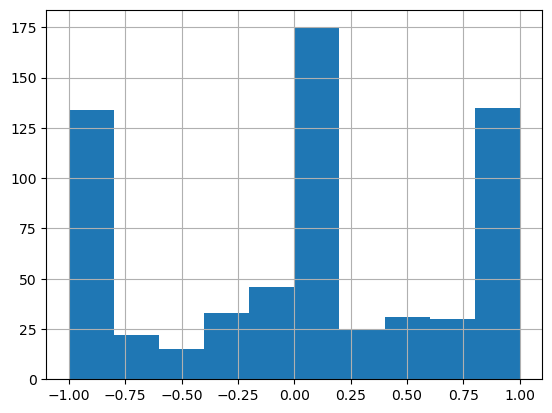

In [248]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['alt_ref_local_bitscore_diff'].hist()


<Axes: >

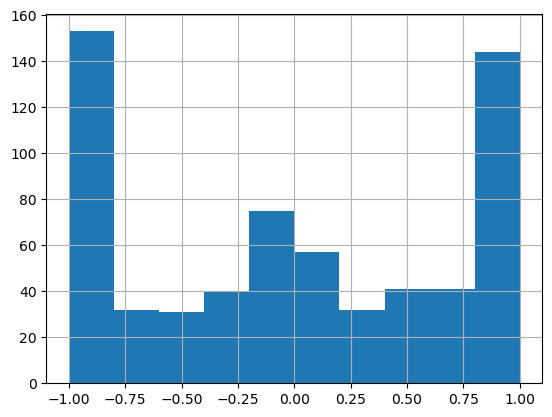

In [249]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['alt_ref_bitscore_diff'].hist()

In [250]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore.apply(lambda row: interprete_TFBS_findings(row, variant_effect_col="bcalm_variant_effect_log_ratio_activity", bit_score_difference_col="alt_ref_local_bitscore_diff", new_interpretation_col="local_bitscore_TFBS_interpretation") , axis=1).copy()

ZN790.H12CORE.1.P.C REF and ALT have same bit score => motif is not causal
ZN124.H12CORE.0.P.C REF and ALT have same bit score => motif is not causal
ZN124.H12CORE.0.P.C REF and ALT have same bit score => motif is not causal
SOX10.H12CORE.1.PSM.A REF and ALT have same bit score => motif is not causal
HMGA1.H12CORE.0.P.B REF and ALT have same bit score => motif is not causal
ZN614.H12CORE.0.P.C REF and ALT have same bit score => motif is not causal
HNF4A.H12CORE.0.PSM.A REF and ALT have same bit score => motif is not causal
PAX7.H12CORE.0.P.B REF and ALT have same bit score => motif is not causal
RXRG.H12CORE.1.SM.B REF and ALT have same bit score => motif is not causal
STF1.H12CORE.0.PSM.A REF and ALT have same bit score => motif is not causal
ZN263.H12CORE.0.PM.A REF and ALT have same bit score => motif is not causal
PAX7.H12CORE.2.PM.A REF and ALT have same bit score => motif is not causal
ZN770.H12CORE.0.P.B REF and ALT have same bit score => motif is not causal
BARH2.H12CORE.0.SM.B

In [251]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['TFBS_interpretation'].value_counts()
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['local_bitscore_TFBS_interpretation'].value_counts()

local_bitscore_TFBS_interpretation
motif is predicted to be activating in neural progenitors derived from WTC11                   270
motif is predicted to be repressing in neural progenitors derived from WTC11                   244
Ref and Alt have same bit score => unimportant base hit => motif does not seem to be causal    132
Name: count, dtype: int64

In [254]:
combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['strand'].value_counts()

strand
+    338
-    308
Name: count, dtype: int64

In [259]:
# sanity check that the number of ref and alt bitscores is now more often similar
local_bitscore_no_difference = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation.loc[(combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['local_bitscore_TFBS_interpretation'].str.startswith('Ref and Alt have same bit score ')) & (~combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['TFBS_interpretation'].str.startswith('Ref and Alt have same bit score '))].copy()
local_bitscore_no_difference = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation.loc[(combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['local_bitscore_TFBS_interpretation'].str.startswith('Ref and Alt have same bit score '))].copy()
local_bitscore_no_difference

,ID,motif_id,mod_fimo_start,mod_fimo_stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,local_bitscore_TFBS_interpretation
13,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN790.H12CORE.1.P.C,30,39,-,NaN,NaN,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.2460,CAGGTTCACTGTTGGGCTCTGATCCCACCTTCCCACCATGGGGACA...,...,3.250000,0.150000,motif is predicted to be activating in neural ...,ZNF790,ZN790_HUMAN,Q6PG37,2.2667,2.2667,0.0,Ref and Alt have same bit score => unimportant...
16,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN124.H12CORE.0.P.C,215,226,-,NaN,NaN,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.1160,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,...,1.278055,-0.004988,motif is predicted to be repressing in neural ...,ZNF124,ZN124_HUMAN,Q15973,1.1920,1.1920,0.0,Ref and Alt have same bit score => unimportant...
20,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ZN124.H12CORE.0.P.C,228,239,-,NaN,NaN,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.1160,AGGGCAAAAACCACAAAGCTATGCTCAGCAGGGACCTTCCTCCCCC...,...,3.275561,-0.294264,motif is predicted to be repressing in neural ...,ZNF124,ZN124_HUMAN,Q15973,2.0224,2.0224,0.0,Ref and Alt have same bit score => unimportant...
24,cardiac_neuro_cava_random:ALT_ARHGAP31|ENSG000...,SOX10.H12CORE.1.PSM.A,144,154,-,cardiac_neuro_cava_random:ALT_ARHGAP31|ENSG000...,0.384,cardiac_neuro_cava_random:REF_ARHGAP31|ENSG000...,0.4520,TTGAGTTCCCATCCCCAGTTTTTCAAAGTAAAACACTTAGGTTCCA...,...,7.368269,0.070730,motif is predicted to be activating in neural ...,SOX10,SOX10_HUMAN,P56693,4.2240,4.2240,0.0,Ref and Alt have same bit score => unimportant...
25,cardiac_neuro_cava_random:ALT_ASXL3|ENSG000001...,HMGA1.H12CORE.0.P.B,195,205,-,cardiac_neuro_cava_random:ALT_ASXL3|ENSG000001...,0.320,cardiac_neuro_cava_random:REF_ASXL3|ENSG000001...,0.1890,CGAGCTGGGGCTTTGACTTTAATCCTTCTGACTTTTATCTCAAGTC...,...,7.243952,-0.435484,motif is predicted to be repressing in neural ...,HMGA1,HMGA1_HUMAN,P17096,5.1260,5.1260,0.0,Ref and Alt have same bit score => unimportant...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,cardiac_neuro_cava_random:ALT_VEGFA|ENSG000001...,TAL1.H12CORE.1.P.B,29,42,-,NaN,NaN,cardiac_neuro_cava_random:REF_VEGFA|ENSG000001...,0.1500,AAGGCCCGGCCTTGTCTGCCTCCTGACCATCTCTTCAGCCTCCTTG...,...,6.096552,-0.483744,motif is predicted to be repressing in neural ...,TAL1,TAL1_HUMAN,P17542,3.8975,3.8975,0.0,Ref and Alt have same bit score => unimportant...
629,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,SUH.H12CORE.0.P.B,129,139,-,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,0.173,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,0.1730,ACCTAAACAACACAAATGTATTGTCTTTCAGTTCTGTAAGATAGAA...,...,7.251282,0.056410,motif is predicted to be repressing in neural ...,RBPJ,SUH_HUMAN,Q06330,5.0393,5.0393,0.0,Ref and Alt have same bit score => unimportant...
631,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,ZN263.H12CORE.0.PM.A,162,171,-,NaN,NaN,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,0.0706,AATAACAAAACTACAGGAGGTTGAGGATGGGGCTGGGGGCCAAGGA...,...,6.619433,-0.190283,motif is predicted to be activating in neural ...,ZNF263,ZN263_HUMAN,O14978,5.3016,5.3016,0.0,Ref and Alt have same bit score => unimportant...
632,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,ZN263.H12CORE.0.PM.A,194,203,-,NaN,NaN,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,0.0706,AATAACAAAACTACAGGAGGTTGAGGATGGGGCTGGGGGCCAAGGA...,...,3.361336,0.049595,motif is predicted to be repressing in neural ...,ZNF263,ZN263_HUMAN,O14978,2.8937,2.8937,0.0,Ref and Alt have same bit score => unimportant...


In [260]:
local_bitscore_no_difference['strand'].value_counts()

strand
-    128
+      4
Name: count, dtype: int64

<Axes: >

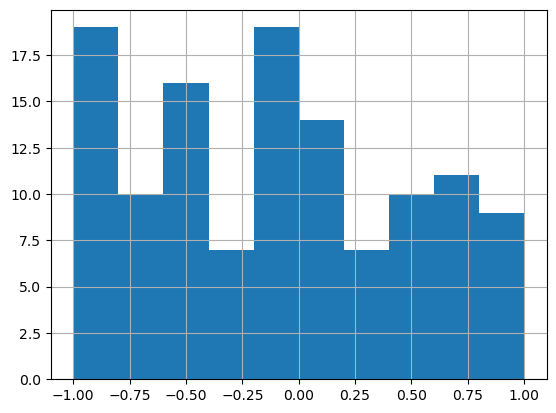

In [253]:
local_bitscore_no_difference['alt_ref_bitscore_diff'].hist()

## TODO: What about common variants is the number of activating variants higher compared to repressing?
- probably yes => probably because only a fraction of the TFBS are acting repressing

In [272]:
variants_TFBS_bitscore_interpretation_filter = combined_fimo_df_overlapping_variants_bitscore_tf_info.loc[~combined_fimo_df_overlapping_variants_bitscore_tf_info['TFBS_interpretation'].str.startswith("Ref and Alt have same bit score ")].copy()
variants_TFBS_bitscore_interpretation_filter = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore.loc[~combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['TFBS_interpretation'].str.startswith("Ref and Alt have same bit score ")].copy()
variants_TFBS_bitscore_interpretation_filter = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation.loc[~combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['local_bitscore_TFBS_interpretation'].str.startswith("Ref and Alt have same bit score ")].copy()

In [276]:
variants_TFBS_bitscore_interpretation_filter.groupby("gene_symbol")['TFBS_interpretation'].value_counts()

# Group by gene_symbol and count unique TFBS_interpretation entries
multi_interpretation_genes = variants_TFBS_bitscore_interpretation_filter.groupby('gene_symbol')['TFBS_interpretation'].nunique()

# Filter those with more than 1 unique interpretation
genes_with_multiple_interpretations = multi_interpretation_genes[multi_interpretation_genes > 1].index

# If you want the full rows for those genes:
variant_overlap_tfs_different_annotations = combined_fimo_df_overlapping_variants_bitscore_tf_info[combined_fimo_df_overlapping_variants_bitscore_tf_info['gene_symbol'].isin(genes_with_multiple_interpretations)].copy()
variant_overlap_tfs_different_annotations = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore[combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore['gene_symbol'].isin(genes_with_multiple_interpretations)].copy()
variant_overlap_tfs_different_annotations = combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation[combined_fimo_df_overlapping_variants_bitscore_tf_info_recompute_bitscore_interpretation['gene_symbol'].isin(genes_with_multiple_interpretations)].copy()

In [277]:
variant_overlap_tfs_different_annotations # 396

,ID,motif_id,mod_fimo_start,mod_fimo_stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,local_bitscore_TFBS_interpretation
0,cardiac_neuro_cava_random:ALT_ADAM22|ENSG00000...,ZN574.H12CORE.0.P.B,111,123,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,0.431,TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAA...,...,6.713000,-0.431000,motif is predicted to be activating in neural ...,ZNF574,ZN574_HUMAN,Q6ZN55,5.5340,5.1030,-0.4310,motif is predicted to be activating in neural ...
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,81,90,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,6.828343,0.917166,motif is predicted to be activating in neural ...,RUNX1,RUNX1_HUMAN,Q01196,5.4621,6.3792,0.9171,motif is predicted to be activating in neural ...
3,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,83,93,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,7.251356,1.000000,motif is predicted to be activating in neural ...,ZNF766,ZN766_HUMAN,Q5HY98,5.9873,6.9873,1.0000,motif is predicted to be activating in neural ...
4,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,48,59,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,...,7.205794,-0.120879,motif is predicted to be activating in neural ...,FOSL2,FOSL2_HUMAN,P15408,4.6044,4.4835,-0.1209,motif is predicted to be activating in neural ...
6,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,ZN787.H12CORE.1.S.C,180,191,+,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,0.483,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,0.312,TTGAGGGAGCCCACCTGCCTGTTCCCCACTCCCTCCAGCTGATGCT...,...,7.380701,-0.054576,motif is predicted to be repressing in neural ...,ZNF787,ZN787_HUMAN,Q6DD87,5.5917,5.5371,-0.0546,motif is predicted to be repressing in neural ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,GLIS3.H12CORE.1.S.C,234,245,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.103,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,4.782756,-0.962299,motif is predicted to be repressing in neural ...,GLIS3,GLIS3_HUMAN,Q8NEA6,5.1601,4.1978,-0.9623,motif is predicted to be repressing in neural ...
641,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,235,246,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,6.273054,-0.999875,motif is predicted to be repressing in neural ...,ZBTB7B,ZBT7B_HUMAN,O15156,6.8040,5.8041,-0.9999,motif is predicted to be repressing in neural ...
642,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,236,247,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,3.923435,-0.176184,motif is predicted to be repressing in neural ...,ZBTB7B,ZBT7B_HUMAN,O15156,3.5832,3.4070,-0.1762,motif is predicted to be repressing in neural ...
643,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,233,245,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,6.771045,-0.966659,motif is predicted to be repressing in neural ...,ZNF460,ZN460_HUMAN,Q14592,6.5604,5.5937,-0.9667,motif is predicted to be repressing in neural ...


##### Local and motif based bitscore difference is only correlating (0.647)

In [278]:
print("Correlation between the window bitscore (5bp around the variant and within the motif pwm) vs bitscore computed over the whole TFBS motif pwm")
# Pearson correlation (default)
pearson_corr = variant_overlap_tfs_different_annotations['alt_ref_local_bitscore_diff'].corr(variant_overlap_tfs_different_annotations['alt_ref_bitscore_diff'])
print(f"Pearson correlation: {pearson_corr:.3f}")

# Spearman correlation
spearman_corr = variant_overlap_tfs_different_annotations['alt_ref_local_bitscore_diff'].corr(variant_overlap_tfs_different_annotations['alt_ref_bitscore_diff'], method='spearman')
print(f"Spearman correlation: {spearman_corr:.3f}")



# from matplotlib import pyplot as plt
# from scipy.stats import pearsonr, spearmanr
# # Compute correlations
# pearson_r, pearson_p = pearsonr(variant_overlap_tfs_different_annotations['alt_ref_local_bitscore_diff'], variant_overlap_tfs_different_annotations['alt_ref_bitscore_diff'])
# spearman_r, spearman_p = spearmanr(variant_overlap_tfs_different_annotations['alt_ref_local_bitscore_diff'], variant_overlap_tfs_different_annotations['alt_ref_bitscore_diff'])

# # Plot
# plt.figure(figsize=(6, 6))
# plt.scatter(variant_overlap_tfs_different_annotations['alt_ref_local_bitscore_diff'], variant_overlap_tfs_different_annotations['alt_ref_bitscore_diff'], alpha=0.5, edgecolors='k')
# plt.xlabel("True Labels")
# plt.ylabel("Predictions")
# plt.title(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})\n"
#           f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Correlation between the window bitscore (5bp around the variant and within the motif pwm) vs bitscore computed over the whole TFBS motif pwm
Pearson correlation: 0.935
Spearman correlation: 0.932


In [279]:
mean_abs_diff = (
    variant_overlap_tfs_different_annotations.groupby('gene_symbol')['alt_ref_local_bitscore_diff']
    .apply(lambda x: x.abs().mean())
)

# Map to the original dataframe
variant_overlap_tfs_different_annotations['mean_abs_alt_ref_bitscore_diff'] = variant_overlap_tfs_different_annotations['gene_symbol'].map(mean_abs_diff)

In [280]:
variant_overlap_tfs_different_annotations.columns

Index(['ID', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand',
       'ALT_name', 'ALT_q-value', 'REF_name', 'REF_q-value', 'ref_sequence',
       'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore',
       'alt_bitscore', 'alt_ref_bitscore_diff', 'TFBS_interpretation',
       'gene_symbol', 'uniprot_id', 'uniprot_accession_num',
       'local_ref_bitscore', 'local_alt_bitscore',
       'alt_ref_local_bitscore_diff', 'local_bitscore_TFBS_interpretation',
       'mean_abs_alt_ref_bitscore_diff'],
      dtype='object')

In [281]:
variant_overlap_tfs_different_annotations.sort_values(by="mean_abs_alt_ref_bitscore_diff", ascending=False)

,ID,motif_id,mod_fimo_start,mod_fimo_stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,local_bitscore_TFBS_interpretation,mean_abs_alt_ref_bitscore_diff
146,cardiac_neuro_cava_random:ALT_FANCI|ENSG000001...,HEY1.H12CORE.0.S.B,91,102,+,cardiac_neuro_cava_random:ALT_FANCI|ENSG000001...,0.350,NaN,NaN,TGAGAGCAAAGGACTCTCAGAAGGGTTGTAAACTTTGGACCACACA...,...,1.000000,motif is predicted to be repressing in neural ...,HEY1,HEY1_HUMAN,Q9Y5J3,6.4109,7.4109,1.000,motif is predicted to be repressing in neural ...,1.000000
88,cardiac_neuro_cava_random:ALT_CHI3L1|ENSG00000...,HEY1.H12CORE.0.S.B,218,229,+,cardiac_neuro_cava_random:ALT_CHI3L1|ENSG00000...,0.350,NaN,NaN,CAGAAATGAAGGTGGGGTTGGAGAAGGAGAACCGGCCTCCTCAGAG...,...,1.000000,motif is predicted to be activating in neural ...,HEY1,HEY1_HUMAN,Q9Y5J3,5.9254,6.9254,1.000,motif is predicted to be activating in neural ...,1.000000
462,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,SIX1.H12CORE.0.P.B,129,142,-,NaN,NaN,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,1.0000,ATTTTTCCTTCGAAAGTTTTATGGGATAGATCAAATTTCCTATGAA...,...,-0.997003,motif is predicted to be repressing in neural ...,SIX1,SIX1_HUMAN,Q15475,5.7453,4.7483,-0.997,motif is predicted to be repressing in neural ...,0.997000
464,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,SIX1.H12CORE.0.P.B,138,151,-,NaN,NaN,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,1.0000,ATTTTTCCTTCGAAAGTTTTATGGGATAGATCAAATTTCCTATGAA...,...,0.997003,motif is predicted to be activating in neural ...,SIX1,SIX1_HUMAN,Q15475,1.8801,2.8771,0.997,motif is predicted to be activating in neural ...,0.997000
492,cardiac_neuro_cava_random:ALT_RFX3|ENSG0000008...,ZN148.H12CORE.0.P.B,122,140,-,NaN,NaN,cardiac_neuro_cava_random:REF_RFX3|ENSG0000008...,0.0557,TACGCTGTATATGCGATATGCAGAAATAGTAGCATAAGCTGTCCTC...,...,-0.970000,motif is predicted to be activating in neural ...,ZNF148,ZN148_HUMAN,Q9UQR1,4.0550,3.0850,-0.970,motif is predicted to be activating in neural ...,0.981333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,ZN320.H12CORE.1.P.B,84,94,+,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,0.276,cardiac_neuro_cava_random:REF_PIGP|ENSG0000018...,0.2760,TAAAGAGTAGCGACAGGTGGCCCGTGGTCAGTGTAAGTAAAACCTG...,...,0.024000,motif is predicted to be activating in neural ...,ZNF320,ZN320_HUMAN,A2RRD8,3.4840,3.5080,0.024,motif is predicted to be activating in neural ...,0.100750
413,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,ZN320.H12CORE.1.P.B,84,94,+,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,0.276,cardiac_neuro_cava_random:REF_PIGP|ENSG0000018...,0.2760,TAAAGAGTAGCGACAGGTGGCCCGTGGTCAGTGTAAGTAAAACCTG...,...,0.024000,motif is predicted to be activating in neural ...,ZNF320,ZN320_HUMAN,A2RRD8,3.4840,3.5080,0.024,motif is predicted to be activating in neural ...,0.100750
432,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,ZN320.H12CORE.1.P.B,131,141,-,NaN,NaN,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,0.3050,TGGTGGGGACCTGGGGCTCTCAGAGGATCTGTTGGGGCGGGGAGAT...,...,-0.311000,motif is predicted to be activating in neural ...,ZNF320,ZN320_HUMAN,A2RRD8,2.8560,2.8560,0.000,Ref and Alt have same bit score => unimportant...,0.100750
424,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,ZN320.H12CORE.1.P.B,84,94,+,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,0.276,cardiac_neuro_cava_random:REF_PIGP|ENSG0000018...,0.2760,TAAAGAGTAGCGACAGGTGGCCCGTGGTCAGTGTAAGTAAAACCTG...,...,0.121000,motif is predicted to be activating in neural ...,ZNF320,ZN320_HUMAN,A2RRD8,3.4840,3.6050,0.121,motif is predicted to be activating in neural ...,0.100750


##### Write the sorted bitscore predicted to be activating repressing variants with TFBS hit

In [ ]:
if write_output:
    variant_overlap_tfs_different_annotations_output = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/NGN2_variants_tfbs_hit_fimo_h12core_less_local_bitscore.tsv"
    variant_overlap_tfs_different_annotations.to_csv(variant_overlap_tfs_different_annotations_output, sep="\t", index=False)

In [102]:
variant_tfbs_interpretations_df = combined_fimo_df_overlapping_variants_bitscore_tf_info.groupby(by="gene_symbol")[["TFBS_interpretation", "ID"]].value_counts().reset_index()
variant_tfbs_interpretations_df

,gene_symbol,TFBS_interpretation,ID,count
0,AHR,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_DSCAM|ENSG000001...,1
1,AHR,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_H1-3|ENSG0000012...,1
2,AHR,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_H1-3|ENSG0000012...,1
3,AHR,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_H1-3|ENSG0000012...,1
4,AR,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,2
...,...,...,...,...
611,ZSCAN29,motif is predicted to be repressing in neural ...,cardiac_neuro_cava_random:ALT_TBX20|ENSG000001...,1
612,ZSCAN31,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,1
613,ZSCAN5A,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_PITX2|ENSG000001...,1
614,ZSCAN5C,motif is predicted to be activating in neural ...,cardiac_neuro_cava_random:ALT_DNM1|ENSG0000010...,1


#### Investigate multiple matching motifs for single variant

In [244]:
motifs_per_variant = combined_fimo_df_overlapping_variants_bitscore_interpretation.groupby(['ID'])['motif_id'].count().reset_index()

# combined_fimo_df_overlapping_variants_bitscore_interpretation.groupby(['ID'])['motif_id'].count()

In [249]:
multimapping_variants = motifs_per_variant.loc[motifs_per_variant['motif_id']>1]
multimapping_variants # 142
multimapping_variant_list = multimapping_variants["ID"].to_list()

In [250]:
multimapping_variants_bitscore_interpretation = combined_fimo_df_overlapping_variants_bitscore_interpretation.loc[combined_fimo_df_overlapping_variants_bitscore_interpretation['ID'].isin(multimapping_variant_list)]

In [251]:
multimapping_variants_bitscore_interpretation['maximal']

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation
17,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,84,94,6.196306,7.189466,0.993160,motif is predicted to be repressing in neural ...
18,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,81,90,5.911178,6.828343,0.917166,motif is predicted to be repressing in neural ...
19,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,83,93,6.251356,7.251356,1.000000,motif is predicted to be repressing in neural ...
20,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],0.003945,-0.774683,48,59,7.326673,7.205794,-0.120879,motif is predicted to be repressing in neural ...
22,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,MAFG.H12CORE.1.PSM.A,2,16,-,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,1.000,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,[58],0.003945,-0.774683,49,63,8.250628,7.269416,-0.981212,motif is predicted to be repressing in neural ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7A.H12CORE.0.P.B,9,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.230,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],0.000001,0.556370,238,246,3.761284,2.816449,-0.944835,motif is predicted to be activating in neural ...
2035,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],0.000001,0.556370,235,246,7.272929,6.273054,-0.999875,motif is predicted to be activating in neural ...
2036,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],0.000001,0.556370,236,247,4.099619,3.923435,-0.176184,motif is predicted to be activating in neural ...
2037,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,[240],0.000001,0.556370,233,245,7.737704,6.771045,-0.966659,motif is predicted to be activating in neural ...


In [130]:
all_sign_motif_hists = pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant.tsv", sep="\t")

In [138]:
# Apply the safe_eval function to the specified columns
all_sign_motif_hists[col_variant_pos] = all_sign_motif_hists[col_variant_pos].apply(safe_eval).copy()

In [ ]:
# all_sign_motif_hists['variant_pos_element'] = all_sign_motif_hists[col_variant_pos].apply(lambda var_pos_list: var_pos_list[0])
# all_sign_motif_hists

In [ ]:

# output_path = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_corrected_variant_pos_element.tsv"
# all_sign_motif_hists.to_csv(output_path, sep="\t", index=False)

In [140]:
all_sign_motif_hists
motifs_per_variant = all_sign_motif_hists.groupby(['ID'])['motif_id'].count().reset_index()
multimapping_variants = motifs_per_variant.loc[motifs_per_variant['motif_id']>1]
multimapping_variant_list = multimapping_variants["ID"].to_list()
multimapping_variants_bitscore_interpretation = all_sign_motif_hists.loc[all_sign_motif_hists['ID'].isin(multimapping_variant_list)].copy()
multimapping_variants_three = motifs_per_variant.loc[motifs_per_variant['motif_id'] == 3]
multimapping_variant_three_list = multimapping_variants_three["ID"].to_list()
multimapping_variants_bitscore_interpretation_three = all_sign_motif_hists.loc[all_sign_motif_hists['ID'].isin(multimapping_variant_three_list)].copy()

In [141]:
multimapping_variants_bitscore_interpretation_three

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation
1,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,84,94,6.196306,7.189466,0.993160,motif is predicted to be repressing in neural ...
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,81,90,5.911178,6.828343,0.917166,motif is predicted to be repressing in neural ...
3,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,[88],0.097731,0.273304,83,93,6.251356,7.251356,1.000000,motif is predicted to be repressing in neural ...
56,cardiac_neuro_cava_random:ALT_CACNA2D3|ENSG000...,HAND1.H12CORE.0.P.B,1,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,0.107,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,[113],0.000557,-0.623119,103,119,4.326368,4.124378,-0.201990,motif is predicted to be repressing in neural ...
57,cardiac_neuro_cava_random:ALT_CACNA2D3|ENSG000...,RFX3.H12CORE.1.PS.A,8,21,+,NaN,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,0.191,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,[113],0.000557,-0.623119,110,123,8.879223,7.885959,-0.993264,motif is predicted to be repressing in neural ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,IRX2.H12CORE.0.S.B,7,16,-,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,0.946,NaN,NaN,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,[128],0.000002,0.686385,124,133,5.778584,6.778584,1.000000,motif is predicted to be repressing in neural ...
619,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,IRX3.H12CORE.0.M.C,7,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,0.730,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,[128],0.000002,0.686385,124,134,6.841141,5.991853,-0.849287,motif is predicted to be activating in neural ...
623,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,ERR1.H12CORE.0.PSM.A,4,14,+,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,0.223,NaN,NaN,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,[100],0.065158,0.432421,93,103,6.242462,7.171566,0.929104,motif is predicted to be repressing in neural ...
624,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,ZBED1.H12CORE.0.S.B,6,19,-,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,1.000,NaN,NaN,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,[100],0.065158,0.432421,95,108,7.509857,8.507138,0.997281,motif is predicted to be repressing in neural ...


<Axes: >

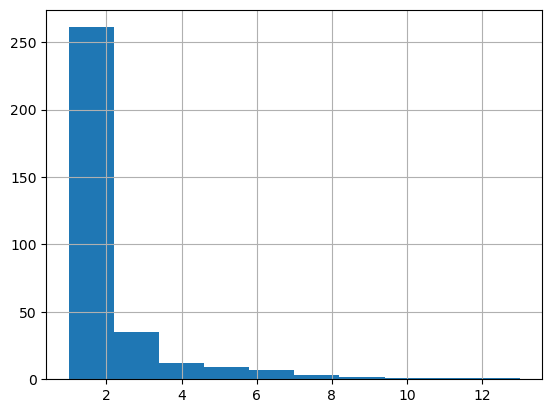

In [134]:
motifs_per_variant["motif_id"].hist()

In [142]:
multimapping_variants_bitscore_interpretation['variant_pos_element'] = multimapping_variants_bitscore_interpretation[col_variant_pos].apply(lambda var_pos_list: var_pos_list[0])
multimapping_variants_bitscore_interpretation
multimapping_variants_bitscore_interpretation_three['variant_pos_element'] = multimapping_variants_bitscore_interpretation_three[col_variant_pos].apply(lambda var_pos_list: var_pos_list[0])
multimapping_variants_bitscore_interpretation

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,variant_pos_element
1,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RFX1.H12CORE.2.S.C,7,17,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.743,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],0.097731,0.273304,84,94,6.196306,7.189466,0.993160,motif is predicted to be repressing in neural ...,88
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,RUNX1.H12CORE.0.P.B,4,13,+,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.222,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],0.097731,0.273304,81,90,5.911178,6.828343,0.917166,motif is predicted to be repressing in neural ...,88
3,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,ZN766.H12CORE.1.P.B,6,16,-,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,0.514,NaN,NaN,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,...,[88],0.097731,0.273304,83,93,6.251356,7.251356,1.000000,motif is predicted to be repressing in neural ...,88
4,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,FOSL2.H12CORE.0.P.B,1,12,+,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,0.136,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,...,[58],0.003945,-0.774683,48,59,7.326673,7.205794,-0.120879,motif is predicted to be repressing in neural ...,58
5,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,MAFG.H12CORE.1.PSM.A,2,16,-,NaN,NaN,cardiac_neuro_cava_random:REF_ADNP|ENSG0000010...,1.000,ATAGATAATAAACCCCCAGGGGTGGCAGCAAGTGCTTTGAAACCAG...,...,[58],0.003945,-0.774683,49,63,8.250628,7.269416,-0.981212,motif is predicted to be repressing in neural ...,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7A.H12CORE.0.P.B,9,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.230,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],0.000001,0.556370,238,246,3.761284,2.816449,-0.944835,motif is predicted to be activating in neural ...,240
641,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,6,17,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],0.000001,0.556370,235,246,7.272929,6.273054,-0.999875,motif is predicted to be activating in neural ...,240
642,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZBT7B.H12CORE.0.SM.B,7,18,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.573,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],0.000001,0.556370,236,247,4.099619,3.923435,-0.176184,motif is predicted to be activating in neural ...,240
643,cardiac_neuro_cava_random:ALT_ZNF148|ENSG00000...,ZN460.H12CORE.0.S.C,4,16,+,NaN,NaN,cardiac_neuro_cava_random:REF_ZNF148|ENSG00000...,0.183,CGTAATCTGGAGATGACTTAAAGTATGTGGGAGGATGTGTGTAGGT...,...,[240],0.000001,0.556370,233,245,7.737704,6.771045,-0.966659,motif is predicted to be activating in neural ...,240


In [143]:
# EH38E1703157

# multimapping_variants_bitscore_interpretation.loc[multimapping_variants_bitscore_interpretation["ID"].str.contains("EH38E1703157")]
# multimapping_variants_bitscore_interpretation.loc[multimapping_variants_bitscore_interpretation["ID"].str.contains("EH38E3085024")].to_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_multi_motifs_for_EH38E3085024_variants_overlapping_significant_variants_h12core_less_redun/multiple_variant_motif_hits_EH38E3085024_for_plotting.tsv", sep="\t", index=False)

# write all multiple variant hit motifs
# multimapping_variants_bitscore_interpretation.to_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_multi_motifs_for_EH38E3085024_variants_overlapping_significant_variants_h12core_less_redun/all_multiple_variant_motif_hits_for_plotting.tsv", sep="\t", index=False)


all_columns = ['ALT_name', 'REF_name', 'variant_pos_element', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand', 'ref_sequence', 'alt_sequence', 'bcalm_variant_effect_log_ratio_activity']
# write only multiple variant hit motifs with 3 differet motifs

# multimapping_variants_bitscore_interpretation_three.drop(columns=["variant_pos", "ALT_q-value"]).to_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/all_3_multiple_variant_motif_hits_for_plotting.tsv", sep="\t", index=False, header=True)
multimapping_variants_bitscore_interpretation_three[all_columns].to_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/all_3_multiple_variant_motif_hits_for_plotting.tsv", sep="\t", index=False, header=True)

In [ ]:
multimapping_variants_bitscore_interpretation_three

In [128]:
multimapping_variants_bitscore_interpretation_three.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'mod_fimo_start',
       'mod_fimo_stop', 'ref_bitscore', 'alt_bitscore',
       'alt_ref_bitscore_diff', 'TFBS_interpretation', 'variant_pos_element'],
      dtype='object')

In [124]:
multimapping_variants_bitscore_interpretation_three.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'mod_fimo_start',
       'mod_fimo_stop', 'ref_bitscore', 'alt_bitscore',
       'alt_ref_bitscore_diff', 'TFBS_interpretation', 'variant_pos_element'],
      dtype='object')

In [ ]:
all_sign_motif_hists['variant_pos']

In [137]:
# read again because of error:
pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/all_3_multiple_variant_motif_hits_for_plotting.tsv", sep="\t")

,ALT_name,REF_name,variant_pos_element,motif_id,mod_fimo_start,mod_fimo_stop,strand,ref_sequence,alt_sequence,bcalm_variant_effect_log_ratio_activity
0,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,RFX1.H12CORE.2.S.C,84,94,+,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
1,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,RUNX1.H12CORE.0.P.B,81,90,+,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,ZN766.H12CORE.1.P.B,83,93,-,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
3,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,113,HAND1.H12CORE.0.P.B,103,119,+,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,-0.623119
4,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,113,RFX3.H12CORE.1.PS.A,110,123,+,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,-0.623119
...,...,...,...,...,...,...,...,...,...,...
100,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,NaN,128,IRX2.H12CORE.0.S.B,124,133,-,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,0.686385
101,NaN,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,128,IRX3.H12CORE.0.M.C,124,134,+,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,0.686385
102,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,NaN,100,ERR1.H12CORE.0.PSM.A,93,103,+,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,0.432421
103,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,NaN,100,ZBED1.H12CORE.0.S.B,95,108,-,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,0.432421


In [147]:
import pandas as pd

# Try reading the file, skipping bad lines if necessary
try:
    df = pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/all_3_multiple_variant_motif_hits_for_plotting.tsv", sep="\t", low_memory=False)
    print("File loaded successfully!")
except Exception as e:
    print(f"Error loading file: {e}")

File loaded successfully!


In [146]:
df

,ALT_name,REF_name,variant_pos_element,motif_id,mod_fimo_start,mod_fimo_stop,strand,ref_sequence,alt_sequence,bcalm_variant_effect_log_ratio_activity
0,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,RFX1.H12CORE.2.S.C,84,94,+,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
1,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,RUNX1.H12CORE.0.P.B,81,90,+,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
2,cardiac_neuro_cava_random:ALT_ADNP|ENSG0000010...,NaN,88,ZN766.H12CORE.1.P.B,83,93,-,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTA...,0.273304
3,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,113,HAND1.H12CORE.0.P.B,103,119,+,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,-0.623119
4,NaN,cardiac_neuro_cava_random:REF_CACNA2D3|ENSG000...,113,RFX3.H12CORE.1.PS.A,110,123,+,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,AGGTTACAGTAAAGGAGCCAGCCAAAACCCACCAAAACCAAAATGG...,-0.623119
...,...,...,...,...,...,...,...,...,...,...
100,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,NaN,128,IRX2.H12CORE.0.S.B,124,133,-,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,0.686385
101,NaN,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,128,IRX3.H12CORE.0.M.C,124,134,+,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,AATCTAAAATTAGAAGGCCACACTGGAAATAGTTCTAATATTTTCT...,0.686385
102,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,NaN,100,ERR1.H12CORE.0.PSM.A,93,103,+,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,0.432421
103,cardiac_neuro_cava_random:ALT_UBR1|ENSG0000015...,NaN,100,ZBED1.H12CORE.0.S.B,95,108,-,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,GGAAATCTGAGCGCTTATTTCCCACCCCGCCTCCCCAACTATCATG...,0.432421


#### Write tables for plotting: 
- you can just write the file and the plot function will take what it needs
- get only subset of sequence for plotting (variant pos +- 15) + set variant pos to 15

In [ ]:
# TODO: store predicted to be activating and repressing outputs and plot them
# TODO: investigate multiple matching of TFBS on same variant
combined_fimo_df_overlapping_variants_bitscore_interpretation_activating

In [ ]:
# python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_43.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/plot_significant_variants_hit_unique

# all significant variant hits
# python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_corrected_variant_pos_element.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_all_motifs_overlapping_significant_variants_h12core_less_redun/plot_significant_variants_hit_unique --variantEffectColumn bcalm_variant_effect_log_ratio_activity --variantPosZeroBased True

# without chung_size ~10:
# number of variant pairs : 646
# /home/kisa/miniforge3/envs/tf_analysis/lib/pypy3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
#   return bound(*args, **kwds)
# X Error of failed request:  BadAlloc (insufficient resources for operation)
#   Major opcode of failed request:  53 (X_CreatePixmap)
#   Serial number of failed request:  304
#   Current serial number in output stream:  305


# example of multi hit
# python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_multi_motifs_for_EH38E3085024_variants_overlapping_significant_variants_h12core_less_redun/multiple_variant_motif_hits_EH38E3085024_for_plotting.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_multi_motifs_for_EH38E3085024_variants_overlapping_significant_variants_h12core_less_redun/plot_2_EH38E3085024_significant_variants_hits --variantEffectColumn bcalm_variant_effect_log_ratio_activity --variantPosZeroBased True

# all multiple motifs per variant
# python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_multi_motifs_for_EH38E3085024_variants_overlapping_significant_variants_h12core_less_redun/all_multiple_variant_motif_hits_for_plotting.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_all_multi_motifs_variants_overlapping_significant_variants_h12core_less_redun/plot_all_multiple_motifs_for_significant_variants_hits --variantEffectColumn bcalm_variant_effect_log_ratio_activity --variantPosZeroBased True


# all 3 multiple motifs per variant
# python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/all_3_multiple_variant_motif_hits_for_plotting.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/plot_three_multi_motifs_for_variants_overlapping_significant_variants_h12core_less_redun/plot_all_3_multi_motif_hits_on_significant_variants_hits --variantEffectColumn bcalm_variant_effect_log_ratio_activity --variantPosZeroBased True

### Check presentation examples: Which motif fits best: 
- LT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_tile1-1_CHAMP1|ENSG00000198824.8|EH38E3085024|13-114353564-G-A

In [8]:
all_sign_motif_hists = pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant.tsv", sep="\t")
# Apply the safe_eval function to the specified columns
all_sign_motif_hists[col_variant_pos] = all_sign_motif_hists[col_variant_pos].apply(safe_eval).copy()

In [13]:
# interested in 13-114353564-G-A
all_related_variant_motif_hits = all_sign_motif_hists.loc[all_sign_motif_hists["ID"].str.contains("13-114353564-G-A")].copy()

In [18]:
all_related_variant_motif_hits["motif_bitscore"] = abs(all_related_variant_motif_hits["ref_bitscore"] - all_related_variant_motif_hits["alt_bitscore"])
all_related_variant_motif_hits["average_bitscore"] = (all_related_variant_motif_hits["ref_bitscore"]+ all_related_variant_motif_hits["alt_bitscore"])/2
all_related_variant_motif_hits.sort_values(by="motif_bitscore", ascending=False)

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,motif_bitscore,average_bitscore
75,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,KLF3.H12CORE.1.M.C,9,21,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.3090,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.75261,63,75,6.200564,5.208300,-0.992264,motif is predicted to be repressing in neural ...,0.992264,5.704432
76,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0305,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.75261,63,73,6.848849,6.343343,-0.505506,motif is predicted to be repressing in neural ...,0.505506,6.596096
74,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ATF1.H12CORE.1.P.B,1,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0737,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.75261,55,73,5.389381,5.619469,0.230088,motif is predicted to be activating in neural ...,0.230088,5.504425
78,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN704.H12CORE.0.SM.B,2,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.222,NaN,NaN,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.75261,56,71,7.921632,8.060143,0.138510,motif is predicted to be activating in neural ...,0.138510,7.990887
77,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN213.H12CORE.0.P.C,1,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.075,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0961,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.75261,55,71,8.260766,8.327751,0.066986,motif is predicted to be activating in neural ...,0.066986,8.294258


In [ ]:
# cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_tile1-1_CHAMP1|ENSG00000198824.8|EH38E3085024|13-114353565-G-A

In [27]:
small_example = all_sign_motif_hists.loc[all_sign_motif_hists["ID"].str.contains("13-114353565-G-A", regex=False)].copy()
small_example = all_sign_motif_hists.loc[all_sign_motif_hists["ID"].str.contains("EH38E3716097", regex=False)].copy()

In [28]:
small_example["motif_bitscore"] = abs(small_example["ref_bitscore"] - small_example["alt_bitscore"])
small_example["average_bitscore"] = (small_example["ref_bitscore"]+ small_example["alt_bitscore"])/2
small_example.sort_values(by="motif_bitscore", ascending=False)

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,motif_bitscore,average_bitscore
276,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,HIC1.H12CORE.0.PSM.A,6,15,-,NaN,NaN,cardiac_neuro_cava_random:REF_LINC01626|ENSG00...,0.685,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,7.023196e-04,0.564193,134,143,6.275857,5.275857,-1.000000,motif is predicted to be activating in neural ...,1.000000,5.775857
280,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,KAISO.H12CORE.0.P.B,7,17,-,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,1.0,NaN,NaN,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,1.393846e-06,0.604069,204,214,6.026026,6.993994,0.967968,motif is predicted to be repressing in neural ...,0.967968,6.510010
278,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,ZNF18.H12CORE.0.P.B,11,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_LINC01626|ENSG00...,0.299,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,3.937269e-04,0.501194,199,207,2.079000,2.677000,0.598000,motif is predicted to be repressing in neural ...,0.598000,2.378000
277,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,ZNF18.H12CORE.0.P.B,11,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_LINC01626|ENSG00...,0.299,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,2.003385e-07,0.639468,196,204,2.148000,2.664000,0.516000,motif is predicted to be repressing in neural ...,0.516000,2.406000
281,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,ZNF18.H12CORE.0.P.B,11,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_LINC01626|ENSG00...,0.299,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,1.393846e-06,0.604069,208,216,7.011000,6.703000,-0.308000,motif is predicted to be activating in neural ...,0.308000,6.857000
279,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,HIC1.H12CORE.0.PSM.A,6,15,-,NaN,NaN,cardiac_neuro_cava_random:REF_LINC01626|ENSG00...,0.685,TGGAATTGTTCAAACAAATCACTCATATACTCTCATGGGAGTCAGG...,...,1.393846e-06,0.604069,203,212,1.432772,1.432772,0.000000,Ref and Alt have same bit score => unimportant...,0.000000,1.432772


- cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000198824.8|EH38E3085024_fwd_tile1-1_CHAMP1|ENSG00000198824.8|EH38E3085024|13-114353586-G-T

In [ ]:
all_related_variant_motif_hits = all_sign_motif_hists.loc[all_sign_motif_hists["ID"].str.contains("EH38E3085024|13-11435", regex=False)].copy()


In [22]:
all_related_variant_motif_hits["motif_bitscore"] = abs(all_related_variant_motif_hits["ref_bitscore"] - all_related_variant_motif_hits["alt_bitscore"])
all_related_variant_motif_hits["average_bitscore"] = (all_related_variant_motif_hits["ref_bitscore"]+ all_related_variant_motif_hits["alt_bitscore"])/2
all_related_variant_motif_hits.sort_values(by="motif_bitscore", ascending=False)

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,motif_bitscore,average_bitscore
75,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,KLF3.H12CORE.1.M.C,9,21,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.3090,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.752610,63,75,6.200564,5.208300,-0.992264,motif is predicted to be repressing in neural ...,0.992264,5.704432
85,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0305,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000389,-0.720382,85,95,7.414414,6.675676,-0.738739,motif is predicted to be repressing in neural ...,0.738739,7.045045
80,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0305,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000479,-0.837000,64,74,5.014014,4.508509,-0.505506,motif is predicted to be repressing in neural ...,0.505506,4.761261
76,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0305,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.752610,63,73,6.848849,6.343343,-0.505506,motif is predicted to be repressing in neural ...,0.505506,6.596096
82,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN441.H12CORE.0.P.C,11,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0855,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000479,-0.837000,66,75,3.693950,3.348754,-0.345196,motif is predicted to be repressing in neural ...,0.345196,3.521352
83,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZSC22.H12CORE.0.P.C,4,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0488,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000479,-0.837000,59,75,5.497487,5.209045,-0.288442,motif is predicted to be repressing in neural ...,0.288442,5.353266
79,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ATF1.H12CORE.1.P.B,1,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0737,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000479,-0.837000,56,74,4.796460,5.026549,0.230088,motif is predicted to be activating in neural ...,0.230088,4.911504
74,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ATF1.H12CORE.1.P.B,1,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0737,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.752610,55,73,5.389381,5.619469,0.230088,motif is predicted to be activating in neural ...,0.230088,5.504425
78,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN704.H12CORE.0.SM.B,2,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.222,NaN,NaN,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.011844,-0.752610,56,71,7.921632,8.060143,0.138510,motif is predicted to be activating in neural ...,0.138510,7.990887
81,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN100.H12CORE.1.P.B,7,20,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.3490,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,0.000479,-0.837000,62,75,5.768362,5.864407,0.096045,motif is predicted to be activating in neural ...,0.096045,5.816384


In [15]:
all_related_variant_motif_hits

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,variant_pos,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,mod_fimo_start,mod_fimo_stop,ref_bitscore,alt_bitscore,alt_ref_bitscore_diff,TFBS_interpretation,motif_bitscore
74,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ATF1.H12CORE.1.P.B,1,19,-,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0737,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,[65],0.011844,-0.75261,55,73,5.389381,5.619469,0.230088,motif is predicted to be activating in neural ...,0.230088
75,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,KLF3.H12CORE.1.M.C,9,21,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.3090,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,[65],0.011844,-0.75261,63,75,6.200564,5.208300,-0.992264,motif is predicted to be repressing in neural ...,0.992264
76,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,VEZF1.H12CORE.0.P.C,9,19,+,NaN,NaN,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0305,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,[65],0.011844,-0.75261,63,73,6.848849,6.343343,-0.505506,motif is predicted to be repressing in neural ...,0.505506
77,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN213.H12CORE.0.P.C,1,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.075,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,0.0961,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,[65],0.011844,-0.75261,55,71,8.260766,8.327751,0.066986,motif is predicted to be activating in neural ...,0.066986
78,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,ZN704.H12CORE.0.SM.B,2,17,+,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,0.222,NaN,NaN,CCTCTGCACAGACTTCGGGGGTATTGCGAAGGCGGAGCAGAGTTCT...,...,[65],0.011844,-0.75261,56,71,7.921632,8.060143,0.138510,motif is predicted to be activating in neural ...,0.138510


#### Old code of computing and processing fimo information 

In [ ]:
combined_fimo_df

,ID,motif_id,start,stop,strand,ALT_q-value,REF_q-value
0,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,MA0003.4_TFAP2A,98,111,+,NaN,0.1420
1,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,MA0018.4_CREB1,14,26,+,NaN,0.0786
2,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,MA0032.2_FOXC1,132,142,+,NaN,0.3480
3,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,MA0039.4_KLF4,64,75,-,NaN,0.1120
4,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,MA0079.5_SP1,65,73,+,NaN,0.0518
...,...,...,...,...,...,...,...
68750,cardiac_neuro_cava_random:ALT_XRCC2|ENSG000001...,MA1993.1_Neurod2,104,113,-,NaN,0.1250
68751,cardiac_neuro_cava_random:ALT_XRCC2|ENSG000001...,MA1997.1_Olig2,104,113,+,NaN,0.1150
68752,cardiac_neuro_cava_random:ALT_XRCC2|ENSG000001...,MA1997.1_Olig2,104,113,-,NaN,0.1150
68753,cardiac_neuro_cava_random:ALT_XRCC2|ENSG000001...,MA1999.1_Prdm5,206,220,-,NaN,0.3990


In [ ]:
variant_bcalm_metadata_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence',
       'bcalm_variant_adjusted_p_value', 'bcalm_variant_log_ratio_activity',
       'bcalm_data_exists', 'label', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'variant_pos'],
      dtype='object')

In [ ]:
variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df[col_variant_pos].apply(lambda pos_list: pos_list[0])

In [ ]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,bcalm_variant_adjusted_p_value,bcalm_variant_log_ratio_activity,bcalm_data_exists,label,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,variant_pos
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN,83
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN,181
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN,43
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,0.989171,0.018811,True,cardiac_neuro_cava_random,6.787829e-01,-0.665831,116
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,0.924458,-0.056823,True,cardiac_neuro_cava_random,4.954250e-13,-0.008161,205
...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,0.953896,0.066359,True,cardiac_neuro_cava_random,2.561939e-13,0.540646,64
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,0.823994,-0.189006,True,cardiac_neuro_cava_random,1.000000e+00,-0.999868,149
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,0.861679,0.100433,True,cardiac_neuro_cava_random,1.245904e-14,0.250438,126
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,0.626394,-0.278188,True,cardiac_neuro_cava_random,1.245904e-14,0.250438,44


In [ ]:
element_bcalm_metadata_df

In [ ]:
import pandas as pd

# Step 1: Match Alternative Sequences (One-to-One)
fimo_variants_alt = fimo_result_df.merge(variant_bcalm_metadata_df[['ALT', col_variant_pos]],
                                  left_on='sequence_name', right_on='ALT', how='left')

# Step 2: Match Reference Sequences (One-to-Many)
fimo_variants_ref = fimo_result_df.merge(variant_bcalm_metadata_df[['REF', col_variant_pos]],
                                  left_on='sequence_name', right_on='REF', how='left')

# drop na
fimo_variants_alt = fimo_variants_alt.loc[~fimo_variants_alt['ALT'].isna()]
fimo_variants_ref = fimo_variants_ref.loc[~fimo_variants_ref['REF'].isna()]

# Step 3: Combine Results
fimo_variants = pd.concat([fimo_variants_alt, fimo_variants_ref])

# Step 4: Cleanup
fimo_variants = fimo_variants.drop(columns=['ALT', 'REF'])

# Step 5: Handle Multiple Variants for One Reference
# Group by `sequence_name` and collect all `ID`s associated with a reference
# fimo_variants[col_variant_pos] = fimo_variants.groupby('sequence_name')[col_variant_pos].transform(lambda x: list())

# Print Final Matched Table
fimo_variants


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,sequence_name_fimo,variant_pos
1,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,ALT_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,206.0
3,MA1642.1_NEUROG2,NEUROG2,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,ALT_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,210.0
5,MA0149.1_EWSR1-FLI1,EWSR1-FLI1,cardiac_neuro_cava_random:ALT_LMNA|ENSG0000016...,162,179,-,18.8553,1.020000e-08,0.000678,GGGAGGAGGGAAGCAAGG,ALT_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,135.0
8,MA0116.1_Znf423,Znf423,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,166,180,+,21.4494,1.200000e-08,0.000551,GCACCCCAGGGTGGC,ALT_ATR|ENSG00000175054.16|EH38E3544427_rev_ti...,76.0
9,MA0116.1_Znf423,Znf423,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,166,180,+,21.4494,1.200000e-08,0.000551,GCACCCCAGGGTGGC,ALT_ATR|ENSG00000175054.16|EH38E3544427_rev_ti...,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...
79904,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,217.0
79905,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,213.0
79906,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,170.0
79907,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,136.0


In [ ]:
#
fimo_result_df['sequence_name'].str.contains("REF_").sum() # n of refs in fimo output 9227
# number of refs after matching
fimo_variants_ref['sequence_name'].str.contains("REF_").sum() # 68030
fimo_variants_ref['sequence_name']
# fimo_variants_ref.loc[fimo_variants_ref['sequence_name'].str.contains("REF_")].shape[0] # 68030


122

In [ ]:
# fimo_variants_ref.drop_duplicates(subset=['motif_id', 'sequence_name', col_variant_pos])
# fimo_variants_alt.drop_duplicates(subset=['motif_id', 'sequence_name', col_variant_pos])

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,sequence_name_fimo,REF,variant_pos
0,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,48.0
1,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,51.0
2,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,67.0
3,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,127.0
4,MA1594.1_ZNF382,ZNF382,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79904,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,217.0
79905,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,213.0
79906,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,170.0
79907,MA0834.1_ATF7,ATF7,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,193,206,+,6.4000,1.000000e-04,0.870000,AAGTGAAGTCATAG,REF_ATR|ENSG00000175054.16|EH38E3544406_rev_ti...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,136.0


In [ ]:
fimo_variants['ID'].str.contains(",").sum()

77027

In [ ]:
fimo_variants

#### Next todos: 
0. Check which motifs are overlapping a variant
1. Compute Bit Scores for reference and alternative sequences using PWMs.
2. Group motifs by whether they have higher bit scores in the reference or alternative sequences.

In [ ]:
def motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """
    Iterate over each variant pos and return true if the start stop coordinates are overlapping the variant position
    NOTE: start and stop are 1-based while variant position from the metadata format is 0-based
    """

    if isinstance(row[col_variant_pos], list):
        for variant_position in row[col_variant_pos]:
            # make the variant position 1-based
            variant_pos_1_based = int(variant_position) + 1
            if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
                return True
    elif isinstance(row[col_variant_pos], int):
        # make the variant position 1-based
        variant_pos_1_based = row[col_variant_pos] + 1
        if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
            return True
    else:
        raise ValueError("Variant position has an unexpected data type")
    return False

In [ ]:
significant_fimo_results_variant_pos.apply(motif_overlaps_variant, axis=1).sum()

#### Old way of processing fimo results

In [ ]:
q_value_threshold = 0.01
significant_fimo_results = fimo_result_df[fimo_result_df['q-value'] < q_value_threshold].copy()

In [ ]:
significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']

In [ ]:
element_bcalm_metadata_df.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label'],
      dtype='object')

In [ ]:
element_bcalm_metadata_df

In [ ]:
header_fimo_results = set(significant_fimo_results['header'].to_list())

In [ ]:
all_header = set(element_bcalm_metadata_df[col_name].to_list())

In [ ]:
header_fimo_results - all_header

{'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF20|ENSG00000100207.21|EH38E2166931_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166931|22-42171749-C-T',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF20|ENSG00000100207.21|EH38E2166931_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166931|22-42171750-T-C',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF20|ENSG00000100207.21|EH38E2166931_rev_tile1-1'}

In [ ]:
significant_fimo_results

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header,tmp_sequence_motif_id,motif_occurrence_id
0,MA1594.1_ZNF382,ZNF382,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...
1,MA1594.1_ZNF382,ZNF382,ALT_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
2,MA1642.1_NEUROG2,NEUROG2,REF_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...
3,MA1642.1_NEUROG2,NEUROG2,ALT_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...
4,MA0149.1_EWSR1-FLI1,EWSR1-FLI1,REF_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,162,179,-,18.8553,1.020000e-08,0.000678,GGGAGGAGGGAAGCAAGG,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,MA1965.1_SP5,SP5,ALT_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...
153,MA1965.1_SP5,SP5,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...
154,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...
155,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...


In [ ]:
significant_fimo_results_variant_pos = significant_fimo_results.merge(element_bcalm_metadata_df[[col_name, 'variant_pos']], left_on='header', right_on=col_name, how="inner")

In [ ]:
def motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """Iterate over each variant pos and return true if the start stop coordinates are overlapping the variant position"""
    for variant_position in row[col_variant_pos]:
        if (int(row[fimo_start_col]) <= int(variant_position) & int(row[fimo_stop_col]) >= int(variant_position)):
            return True
    return False

def hit_variant_pos(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """Iterate over each variant pos and return the variant pos hit by the motif"""
    hit_variant_pos_list = []
    for variant_position in row[col_variant_pos]:
        if (int(row[fimo_start_col]) <= int(variant_position) & int(row[fimo_stop_col]) >= int(variant_position)):
            hit_variant_pos_list.append(variant_position)
    return hit_variant_pos_list

In [ ]:
significant_fimo_results_variant_pos[col_variant_pos] = significant_fimo_results_variant_pos[col_variant_pos].apply(safe_eval)

In [ ]:
significant_fimo_results_variant_pos.apply(motif_overlaps_variant, axis=1).sum()

7

In [ ]:
sig_variants_with_motif = significant_fimo_results_variant_pos.loc[significant_fimo_results_variant_pos.apply(motif_overlaps_variant, axis=1)].copy()
sig_variants_with_motif['hit_variant_pos'] = significant_fimo_results_variant_pos.apply(hit_variant_pos, axis=1)

In [ ]:
sig_variants_with_motif.to_csv("sig_variants_with_motif.tsv", sep="\t", index=None)

In [ ]:
sig_variants_with_motif

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header,tmp_sequence_motif_id,motif_occurrence_id,name,variant_pos,hit_variant_pos
6,MA0080.6_Spi1,Spi1,REF_SRC|ENSG00000197122.13|EH38E2110584_fwd_ti...,95,111,-,21.3902,1.180000e-08,0.00157,AGGAAGAGGAAGTGGTG,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,"[33, 35, 38, 41, 45, 55, 60, 62, 63, 72, 89, 9...","[96, 108]"
20,MA0050.3_Irf1,Irf1,REF_MAX|ENSG00000125952.20|EH38E1721673_rev_ti...,93,107,+,19.4336,3.340000e-08,0.00152,ACAGAAACTGAAAGT,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,"[225, 211, 205, 203, 134, 132, 120, 110, 107, ...",[107]
28,MA0081.2_SPIB,SPIB,ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_ti...,95,110,+,19.7642,5.550000e-08,0.00328,CATCACTTCCTCTTCC,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,[96],[96]
34,MA0080.6_Spi1,Spi1,ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_ti...,95,111,-,19.7886,6.860000e-08,0.00458,AGGAAGAGGAAGTGATG,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,[96],[96]
45,MA1105.2_GRHL2,GRHL2,REF_RAD51B|ENSG00000182185.19|EH38E1723176_fwd...,80,91,+,16.2927,1.020000e-07,0.00705,AAAACAGGTTTT,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,"[33, 83, 139, 174, 179, 204]",[83]
53,MA1945.1_ETV5::FIGLA,ETV5::FIGLA,REF_FANCI|ENSG00000140525.20|EH38E1786542_fwd_...,87,101,+,20.0345,1.350000e-07,0.00621,CCAGGAAGCAGGTGG,cardiac_neuro_cava_random:REF_FANCI|ENSG000001...,cardiac_neuro_cava_random:REF_FANCI|ENSG000001...,cardiac_neuro_cava_random:REF_FANCI|ENSG000001...,cardiac_neuro_cava_random:REF_FANCI|ENSG000001...,"[40, 53, 53, 96, 160, 163, 170]",[96]
54,MA0081.2_SPIB,SPIB,REF_SRC|ENSG00000197122.13|EH38E2110584_fwd_ti...,95,110,+,18.8130,1.640000e-07,0.00555,CACCACTTCCTCTTCC,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,"[33, 35, 38, 41, 45, 55, 60, 62, 63, 72, 89, 9...","[96, 108]"


In [ ]:
significant_fimo_results #95 real significant: non significant 21,108

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header
0,MA1594.1_ZNF382,ZNF382,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...
1,MA1594.1_ZNF382,ZNF382,ALT_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
2,MA1642.1_NEUROG2,NEUROG2,REF_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...
3,MA1642.1_NEUROG2,NEUROG2,ALT_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...
4,MA0149.1_EWSR1-FLI1,EWSR1-FLI1,REF_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,162,179,-,18.8553,1.020000e-08,0.000678,GGGAGGAGGGAAGCAAGG,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...
...,...,...,...,...,...,...,...,...,...,...,...
152,MA1965.1_SP5,SP5,ALT_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...
153,MA1965.1_SP5,SP5,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...
154,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...
155,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...


In [ ]:
# find number of variants in the significant fimo results:
# 1. merge id column with variant region map (alt_id) => ref_id
significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']
# 1.1 make new column in fimo results with sequence_name and motif_id and start and end and strand id column
significant_fimo_results['tmp_sequence_motif_id'] = significant_fimo_results['header'] + '_' + significant_fimo_results['motif_id'] + '_' + significant_fimo_results['start'].astype(str) + '_' + significant_fimo_results['stop'].astype(str) + '_' + significant_fimo_results['strand']
significant_fimo_results_variant_info = significant_fimo_results.merge(variant_bcalm_metadata_df[['ID', 'REF', 'ALT']], left_on='header', right_on='ALT', how='left')
significant_fimo_results_variant_info
# 1.3 make new column in fimo results with ref_id and motif_id and start and end and strand id column
significant_fimo_results_variant_info['tmp_reference_motif_id'] = significant_fimo_results_variant_info['REF'] + '_' + significant_fimo_results_variant_info['motif_id'] + '_' + significant_fimo_results_variant_info['start'].astype(str) + '_' + significant_fimo_results_variant_info['stop'].astype(str) + '_' + significant_fimo_results_variant_info['strand']
# 2. get true in these columns if the ref_id_motif_id is in the sequence_name_motif_id column already
significant_fimo_results_variant_info['tmp_reference_motif_is_in_table'] = significant_fimo_results_variant_info['tmp_reference_motif_id'].isin(significant_fimo_results_variant_info['tmp_sequence_motif_id'].to_list())
significant_fimo_results_variant_info['tmp_reference_motif_is_in_table'].sum() # 137
significant_fimo_results_variant_info["sequence_name"].shape[0] # 276
# 3. shape of fimo results - number of true values (sequences ref and alt for same motif)
print(f'Number of different significant fimo motif results within different variants: {significant_fimo_results_variant_info["sequence_name"].shape[0] - significant_fimo_results_variant_info["tmp_reference_motif_is_in_table"].sum()}') # 139

print(f'Number of different alternative sequences with a motif associated: {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique()}') # 48

# make the same with focus on the number of different variants not taking different motifs into account
# Check if the ref_id is in the sequence_name column and sum the number up

significant_fimo_results_variant_info['tmp_reference_is_in_table'] = significant_fimo_results_variant_info['REF'].isin(significant_fimo_results_variant_info['header'].to_list())
# make new table with tmp reference is in table => get sequence names
refs_with_association_to_alt = significant_fimo_results_variant_info.loc[significant_fimo_results_variant_info['tmp_reference_is_in_table']]['sequence_name'].unique() # 46
# len(refs_with_association_to_alt) # 46
# check how many unique rows of the significant_fimo_results_variant_info have a sequence_name within tmp_reference_is_in_table
refs_with_association_to_alt_in_fimo_results = significant_fimo_results_variant_info.loc[significant_fimo_results_variant_info['sequence_name'].isin(refs_with_association_to_alt)]
print(f'Number of different fimo results with reference associated to an alternative of the fimo results: {refs_with_association_to_alt_in_fimo_results["sequence_name"].shape[0]}') # 140
print(f'Number of unique references associated to an alternative of the fimo results: {refs_with_association_to_alt_in_fimo_results["sequence_name"].nunique()}') # 46
# compute number of different variants by nunique of sequence_name - number of unique rows with tmp_reference_is_in_table
n_differnt_variants_with_significant_fimo_result = significant_fimo_results_variant_info["sequence_name"].nunique() - refs_with_association_to_alt_in_fimo_results["sequence_name"].nunique()
print(f'Number of variants with at least one significant fimo result: {n_differnt_variants_with_significant_fimo_result}') # 42

# print(f'Number of different significant fimo results within different variants: {significant_fimo_results.loc[significant_fimo_results["sequence_name"].shape[0] +  - significant_fimo_results_variant_info["tmp_reference_is_in_table"].sum()}')
# significant_fimo_results_variant_info['tmp_reference_is_in_table'].sum()

Number of different significant fimo motif results within different variants: 45
Number of different alternative sequences with a motif associated: 32
Number of different fimo results with reference associated to an alternative of the fimo results: 50
Number of unique references associated to an alternative of the fimo results: 30
Number of variants with at least one significant fimo result: 28


In [ ]:
significant_fimo_results_variant_info

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header,tmp_sequence_motif_id,ID,REF,ALT,tmp_reference_motif_id,tmp_reference_motif_is_in_table,tmp_reference_is_in_table
0,MA1594.1_ZNF382,ZNF382,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,NaN,NaN,NaN,NaN,False,False
1,MA1594.1_ZNF382,ZNF382,ALT_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,True,True
2,MA1642.1_NEUROG2,NEUROG2,REF_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,NaN,NaN,NaN,NaN,False,False
3,MA1642.1_NEUROG2,NEUROG2,ALT_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,True,True
4,MA0149.1_EWSR1-FLI1,EWSR1-FLI1,REF_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,162,179,-,18.8553,1.020000e-08,0.000678,GGGAGGAGGGAAGCAAGG,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,MA1965.1_SP5,SP5,ALT_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,True,True
91,MA1965.1_SP5,SP5,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,NaN,NaN,NaN,NaN,False,False
92,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,True
93,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,True


In [ ]:
# Step 1: Create unique sequence identifiers
significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']

# Step 2: Create motif occurrence identifier for each sequence
significant_fimo_results['motif_occurrence_id'] = significant_fimo_results.apply(
    lambda row: f"{row['header']}_{row['motif_id']}_{row['start']}_{row['stop']}_{row['strand']}", axis=1
)

# Step 3: Merge FIMO results with variant metadata
fimo_with_variants = significant_fimo_results.merge(
    variant_bcalm_metadata_df[['ID', 'REF', 'ALT']],
    left_on='header', right_on='ALT',
    how='left'
)

# Step 4: Create reference motif occurrence ID
fimo_with_variants['reference_motif_id'] = fimo_with_variants.apply(
    lambda row: f"{row['REF']}_{row['motif_id']}_{row['start']}_{row['stop']}_{row['strand']}", axis=1
)

# Step 5: Check if reference motif is in the sequence motif occurrences
fimo_with_variants['reference_motif_exists'] = fimo_with_variants['reference_motif_id'].isin(
    fimo_with_variants['motif_occurrence_id']
)

# Step 6: Count relevant statistics
num_diff_fimo_motifs = fimo_with_variants.shape[0] - fimo_with_variants['reference_motif_exists'].sum()
num_alt_sequences = significant_fimo_results[significant_fimo_results['sequence_name'].str.contains("ALT_")]['sequence_name'].nunique()

# Step 7: Check reference association with alternative sequences
fimo_with_variants['reference_exists'] = fimo_with_variants['REF'].isin(fimo_with_variants['header'])
refs_with_alt_association = fimo_with_variants[fimo_with_variants['reference_exists']]['sequence_name'].nunique()
num_variants_with_fimo = fimo_with_variants['sequence_name'].nunique() - refs_with_alt_association

# Print results
print(f"Different significant FIMO motif results across variants: {num_diff_fimo_motifs}")
print(f"Alternative sequences with motif: {num_alt_sequences}")
print(f"Variants with at least one significant FIMO result: {num_variants_with_fimo}")


Different significant FIMO motif results across variants: 45
Alternative sequences with motif: 32
Variants with at least one significant FIMO result: 28


In [ ]:
fimo_with_variants

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header,tmp_sequence_motif_id,motif_occurrence_id,ID,REF,ALT,reference_motif_id,reference_motif_exists,reference_exists
0,MA1594.1_ZNF382,ZNF382,REF_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,NaN,NaN,NaN,nan_MA1594.1_ZNF382_144_167_-,False,False
1,MA1594.1_ZNF382,ZNF382,ALT_RAD51B|ENSG00000182185.19|EH38E1723158_fwd...,144,167,-,23.5657,6.960000e-09,0.000464,AGATGGCATTACAACTGATCCCAC,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,True,True
2,MA1642.1_NEUROG2,NEUROG2,REF_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,NaN,NaN,NaN,nan_MA1642.1_NEUROG2_104_116_+,False,False
3,MA1642.1_NEUROG2,NEUROG2,ALT_MYBPC3|ENSG00000134571.12|EH38E2957377_rev...,104,116,+,16.1220,8.550000e-09,0.000591,GGGACAGATGGCC,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:ALT_MYBPC3|ENSG00000...,cardiac_neuro_cava_random:REF_MYBPC3|ENSG00000...,True,True
4,MA0149.1_EWSR1-FLI1,EWSR1-FLI1,REF_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,162,179,-,18.8553,1.020000e-08,0.000678,GGGAGGAGGGAAGCAAGG,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,NaN,NaN,NaN,nan_MA0149.1_EWSR1-FLI1_162_179_-,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,MA1965.1_SP5,SP5,ALT_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,True,True
91,MA1965.1_SP5,SP5,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,175,184,+,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,NaN,NaN,NaN,nan_MA1965.1_SP5_175_184_+,False,False
92,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,True
93,MA1965.1_SP5,SP5,ALT_CYP2D6|ENSG00000100197.23|EH38E2166931~TCF...,217,226,-,15.8980,4.130000e-07,0.008340,CCCCTCCCCC,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_C

### Read the motifs from the meme file

In [ ]:
def read_meme_motifs(file_path):
    motifs = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        motif = None
        for line in lines:
            if line.startswith('MOTIF'):
                if motif:
                    motifs.append(motif)
                motif = {'name': line.strip().split()[1], 'matrix': []}
            elif line[0].isdigit():
                motif['matrix'].append([float(x) for x in line.strip().split()])
        if motif:
            motifs.append(motif)
    return motifs

In [ ]:
meme_h12_core = "/home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme"
motifs_h12_core_list = read_meme_motifs(meme_h12_core)

In [ ]:
from Bio.motifs import meme

with open(meme_h12_core) as f_in:
    h12_core_motifs = meme.read(f_in)

for motif in h12_core_motifs:
    for instance in motif.instances:
        print(instance.motif_name, instance.sequence_name, instance.strand, instance.pvalue)

ValueError: Improper MEME XML input file. XML root tag should start with <MEME version= ...

### Archive code: 

#### Compute the motif pwm only within a fixed window (5bp) around the variant

In [ ]:

# motif local example:
tmp_sequence_ref = "TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAAGATAGCACCTGTCATACAACTCAGAATGCAGACAAGTGAAAGGTCTTGGGGAGCTGACCTTAATTGCTTCTCTGTGTCAACAGGCCAGAACACCTAATAAGGACATGGAGGGGCTGACCTAGTAACAGCATCTGCATCAAAGAGAAACTACACTGTTCACAAGATTAACTTTCTGATACTAAGAAGGGAACAGTAACTTCCTTATTTAGAAGCTGGTGGGTTTT"
tmp_sequence_ref = "TAGGGAAGTGTCCTCTCTCAATGTAAGATAGCACCTGTCAATGTAAGATAGCACCTGTCATACAACTCAGAATGCAGACAAGTGAAAGGTCTTGGGGAGCTGACCTTAATTGCTTCTCTGGGTCAACAGGCCAGAACACCTAATAAGGACATGGAGGGGCTGACCTAGTAACAGCATCTGCATCAAAGAGAAACTACACTGTTCACAAGATTAACTTTCTGATACTAAGAAGGGAACAGTAACTTCCTTATTTAGAAGCTGGTGGGTTTT"
tmp_motif_start = 111
tmp_motif_end = 123 + 1 # end is excluded
tmp_variant_pos = 120
tmp_strand = "+"
tmp_motif = hocomoco_motif_dict["ZN574.H12CORE.0.P.B"]
pwm = tmp_motif.pwm

tmp_sequence_of_interest_start = max(tmp_motif_start, tmp_variant_pos - 5)
print(tmp_sequence_of_interest_start)
tmp_sequence_of_interest_end = min(tmp_motif_end, tmp_variant_pos + 5)
print(tmp_sequence_of_interest_end)
tmp_example_sequence = tmp_sequence_ref[tmp_sequence_of_interest_start:tmp_sequence_of_interest_end]
tmp_example_sequence

tmp_motif_related_start = max(0, tmp_sequence_of_interest_start - tmp_motif_start)
tmp_motif_related_end = min(tmp_motif_end - tmp_motif_start, tmp_sequence_of_interest_end - tmp_motif_start)
print(tmp_motif_related_start)
print(tmp_motif_related_end)
# print(tmp_sequence_of_interest_end - tmp_motif_start)
print(tmp_motif_end - tmp_motif_start)
# expected_motif_hit: GCTTCTCTGGGT
# variant hit:        GCTTCTCTGTGT
# variant sequence:       CTCTGGGT
tmp_motif_sequence = tmp_sequence_ref[tmp_motif_start:tmp_motif_end]
print(tmp_motif_sequence)
tmp_motif_part = tmp_motif_sequence[tmp_motif_related_start:tmp_motif_related_end]
tmp_motif_part
print(tmp_motif_part)
print(len(tmp_motif_part))

# modify the pwm:
print(pwm)
dict_pwm = {nuc: scores for nuc, scores in pwm.items()}
print(dict_pwm)
# print(type(pwm))
modified_pwm = {nuc: scores[tmp_motif_related_start:tmp_motif_related_end] for nuc, scores in pwm.items()}
print(modified_pwm)
# # for nuc, score_list in pwm.items():
# #     print(nuc)
# #     print(len(score_list))
# #     print(type(score_list))
# #     print(type(list(score_list)))
# from Bio.motifs import Motif
# from Bio.motifs.matrix import PositionWeightMatrix
# motif = Motif(alphabet="GATC")  # You can also use IUPAC.unambiguous_dna if needed
# motif.length = len(next(iter(modified_pwm.values())))  # length of the motif
# print(motif.length)
# # Create the PositionWeightMatrix
# modified_pwm_bio = PositionWeightMatrix(motif.alphabet, modified_pwm)
# print(modified_pwm_bio)

ref_score = round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(tmp_motif_part)), 4)
ref_score

# ref: 5.534000000000001
# alt: 5.103000000000001

# motif local example: - strand: gene_symbol: ZNF766 id: cardiac_neuro_cava_random:ALT_ADNP|ENSG00000101126.18|EH38E2120364_rev_tile1-1_ADNP|ENSG00000101126.18|EH38E2120364|20-50914215-T-A
tmp_sequence_ref = "CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTAAGTGTGGAGGAGTGTTACCCTCAGTGTCTTGGATGATTGTGGTTGCTTTGTAGTACAGAAGGATATGAATCATCTTGAAGTTACCCTTGGCTGTGGCCTGGTGCTTTGCTGTAGCCTCATAATGATCCTTACCATCTGGATTAGCCCCACCTTCTAGTAACATGAGAGCAATCTCATGCCTGTTTTTGGAAGCTGCATGATGTAGGGGAGTAGAGCCATTTTGA"
tmp_sequence_ref = "CTTGGGACACCAGCAGTTTTGCTTCTTCCACTCTTATCACAGACTAAGTGTGGAGGAGTGTTACCCTCAGTGTCTTGGATGATTGTGGATGCTTTGTAGTACAGAAGGATATGAATCATCTTGAAGTTACCCTTGGCTGTGGCCTGGTGCTTTGCTGTAGCCTCATAATGATCCTTACCATCTGGATTAGCCCCACCTTCTAGTAACATGAGAGCAATCTCATGCCTGTTTTTGGAAGCTGCATGATGTAGGGGAGTAGAGCCATTTTGA"
tmp_motif_start = 83
tmp_motif_end = 93 + 1 # end is excluded
tmp_variant_pos = 88
tmp_strand = "-"
tmp_motif = hocomoco_motif_dict["ZN766.H12CORE.1.P.B"]

pwm = tmp_motif.pwm
tmp_sequence_of_interest_start = max(tmp_motif_start, tmp_variant_pos - 5)
print(tmp_sequence_of_interest_start)
tmp_sequence_of_interest_end = min(tmp_motif_end, tmp_variant_pos + 5 + 1)
print(tmp_sequence_of_interest_end)
tmp_example_sequence = tmp_sequence_ref[tmp_sequence_of_interest_start:tmp_sequence_of_interest_end]
tmp_example_sequence
print("variant pos in motif", tmp_variant_pos - tmp_motif_start)

tmp_motif_related_start = max(0, tmp_sequence_of_interest_start - tmp_motif_start)
tmp_motif_related_end = min(tmp_motif_end - tmp_motif_start, tmp_sequence_of_interest_end - tmp_motif_start)
print("motif_related_region (start): ", tmp_motif_related_start)
print("motif_related_region (end): ",tmp_motif_related_end)
# print(tmp_sequence_of_interest_end - tmp_motif_start)
print(tmp_motif_end - tmp_motif_start)
# expected_sequence: TGTGGATGCTT
# TGTGGATGCTT
# expected_motif_hit: GCTTCTCTGGGT
# variant hit:        GCTTCTCTGTGT
# variant sequence:       CTCTGGGT

tmp_motif_sequence = tmp_sequence_ref[tmp_motif_start:tmp_motif_end]
print(tmp_motif_sequence)
if tmp_strand == "-":
    tmp_motif_sequence = reverse_complement(tmp_motif_sequence)
print(tmp_motif_sequence)
tmp_motif_part = tmp_motif_sequence[tmp_motif_related_start:tmp_motif_related_end]
tmp_motif_part
print(tmp_motif_part)

print(len(tmp_motif_part))
# modify the pwm:
print(pwm)
dict_pwm = {nuc: scores for nuc, scores in pwm.items()}
print(dict_pwm)
# print(type(pwm))
modified_pwm = {nuc: scores[tmp_motif_related_start:tmp_motif_related_end] for nuc, scores in pwm.items()}
print(modified_pwm)
# # for nuc, score_list in pwm.items():
# #     print(nuc)
# #     print(len(score_list))
# #     print(type(score_list))
# #     print(type(list(score_list)))
from Bio.motifs import Motif
from Bio.motifs.matrix import PositionWeightMatrix
motif = Motif(alphabet="GATC")  # You can also use IUPAC.unambiguous_dna if needed
motif.length = len(next(iter(modified_pwm.values())))  # length of the motif
print(motif.length)
# Create the PositionWeightMatrix
modified_pwm_bio = PositionWeightMatrix(motif.alphabet, modified_pwm)
print(modified_pwm_bio)
ref_score = round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(tmp_motif_part)), 4)
ref_score
# ref: no_rev_comp: 1.9892, 5.9873
# alt: no_rev_comp: 0.9892, 6.9873